In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde, norm
from scipy import stats


import torch
import torch.nn as nn
from dataset_creation import create_synthetic_supernovae_dataset, create_torch_supernovae_dataset, z_obs

from config import DATAPOINT_SIZE, LATENT_SIZE, BETA, REGULARIZATION_WEIGHT, DATA_VARIANCE_SCALE, NUM_TRAIN, NUM_TEST, LOAD_DATASET

from Compression.ib import IB
from Compression.compressors import IBCompressor
from Compression.conditional_prob_models import ConditionalKDE, ConditionalNormalizingFlow

from Compression.Benchmarks.MOPED import moped

from ModelEvaluation.posterior_comparison import evaluate_posterior_covariance
from ModelEvaluation.abc import abc
# from ModelEvaluation.posterior_comparison_gemini import evaluate_nd_posterior_covariance_knn

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Running on device:", device)
# torch.cuda.is_available()

Running on device: cuda


In [4]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.12.0+cu132
13.2
True


## Generating a dataseet

In [5]:
LOAD_DATASET = False

In [6]:
if LOAD_DATASET:
    try:
        train_sims_data = torch.load("train_sims_data.pt")
        test_sims_data = torch.load("test_sims_data.pt")
    except FileNotFoundError:
        print("Data files not found. Creating dataset...")
        train_sims_data, test_sims_data, _ = create_torch_supernovae_dataset(NUM_TRAIN, NUM_TEST)
        torch.save(train_sims_data.to('cpu'), "train_sims_data.pt")
        torch.save(test_sims_data.to('cpu'), "test_sims_data.pt")
else:
    train_sims_data, test_sims_data, _ = create_torch_supernovae_dataset(NUM_TRAIN, NUM_TEST)
    torch.save(train_sims_data.to('cpu'), "train_sims_data.pt")
    torch.save(test_sims_data.to('cpu'), "test_sims_data.pt")

train_sims_data = train_sims_data.to(device)
test_sims_data = test_sims_data.to(device)

Creating sample: 10000 of 10000
Creating sample: 10000 of 10000


## Visualizing the dataset

### Spread of the data with Hubble Parameter
In order to visualize the fact that our data simply moves by a global offset based on the Hubble Constant, we visualize the mean of the data with the Hubble Parameter. This forms quite a linear scatter, showing that the mean is a good representation of the parameter here!

### Each individual datapoint
Each individual datapoint retains the same shape, and only its offset depends on the Hubble constant (can be seen by re-running the cell multiple times and seeing that the shape is retained...alternatively, I can plot all the data-points and subtract their means)  
We notice that the points at low redshift scatter less than those at higher redshifts. This is expected as the lower flux due to the higher redshift appears as a larger scatter

In [7]:
mu = train_sims_data[:, :DATAPOINT_SIZE].detach().cpu()
h0 = train_sims_data[:, -1].detach().cpu()

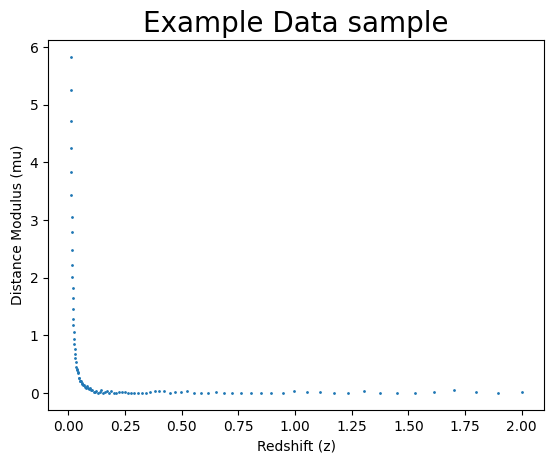

In [8]:
obs_no = np.random.randint(NUM_TRAIN)
flux_obs = 10**(-0.4*mu[obs_no, :])
mu_obs = mu[obs_no, :]
plt.scatter(z_obs, mu_obs, s=1)
# plt.scatter(z_obs, mu_noiseless[obs_no, :], color='red', label='True Signal')
plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus (mu)")
# plt.title(f"Obs: {obs_no} | H0: {h0[obs_no]:.2f}")
plt.title('Example Data sample', fontsize=20)
plt.show()

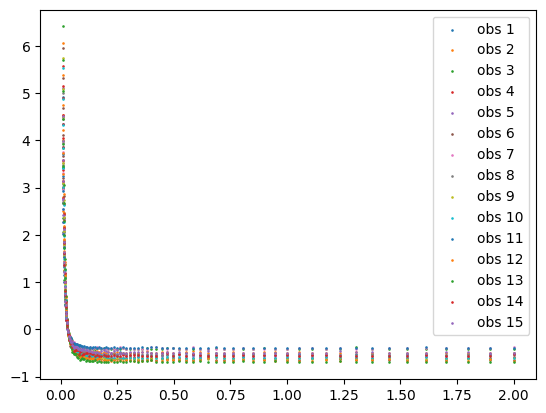

In [9]:
mu_zero_mean = mu - torch.mean(mu, axis=1)[:, None]
mu_zero_mean.shape

for i in range(15):
    plt.scatter(z_obs, mu_zero_mean[i, :], s=0.75, label=f'obs {i+1}')
plt.legend()
plt.show()

## Compression

In [12]:
class Compressor(nn.Module):
    def __init__(self, input_size=DATAPOINT_SIZE, latent_size=LATENT_SIZE):
        super(Compressor, self).__init__()
        self.encoder = nn.Sequential(
            # nn.Linear(input_size, 256),
            # # nn.BatchNorm1d(512),
            # nn.LeakyReLU(0.2),
            # # nn.Dropout(0.1),
            
            # nn.Linear(256, 128),
            # # nn.BatchNorm1d(32),
            # nn.LeakyReLU(0.2),
            
            nn.Linear(input_size, 64),
            # nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 32),
            # nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            
            nn.Linear(32, 2*latent_size)
        )

    def forward(self, x):
        return self.encoder(x)

In [146]:
model_encoder=Compressor()
model = IB(
    encoder=IBCompressor(encoder=model_encoder, x_dim=DATAPOINT_SIZE, z_dim=LATENT_SIZE),
    # cond_prob_model=ConditionalKDE(1, 10),
    cond_prob_model=ConditionalNormalizingFlow(),
    beta = 1e-1,
    reg_weight=4e0,
    reg_type=0,
    optim_func=torch.optim.Adam,
    lr=1e-4
).to(device)

Epoch 1: Loss=0.1645, log_q=-4.6678,, reg. loss=4.8834, beta * KL=0.0512
Epoch 10: Loss=-7.8854, log_q=-8.4817,, reg. loss=0.7373, beta * KL=0.1410
Epoch 20: Loss=-9.0818, log_q=-8.7012,, reg. loss=0.0284, beta * KL=0.4090
Epoch 30: Loss=-9.6730, log_q=-8.7394,, reg. loss=0.0282, beta * KL=0.9617


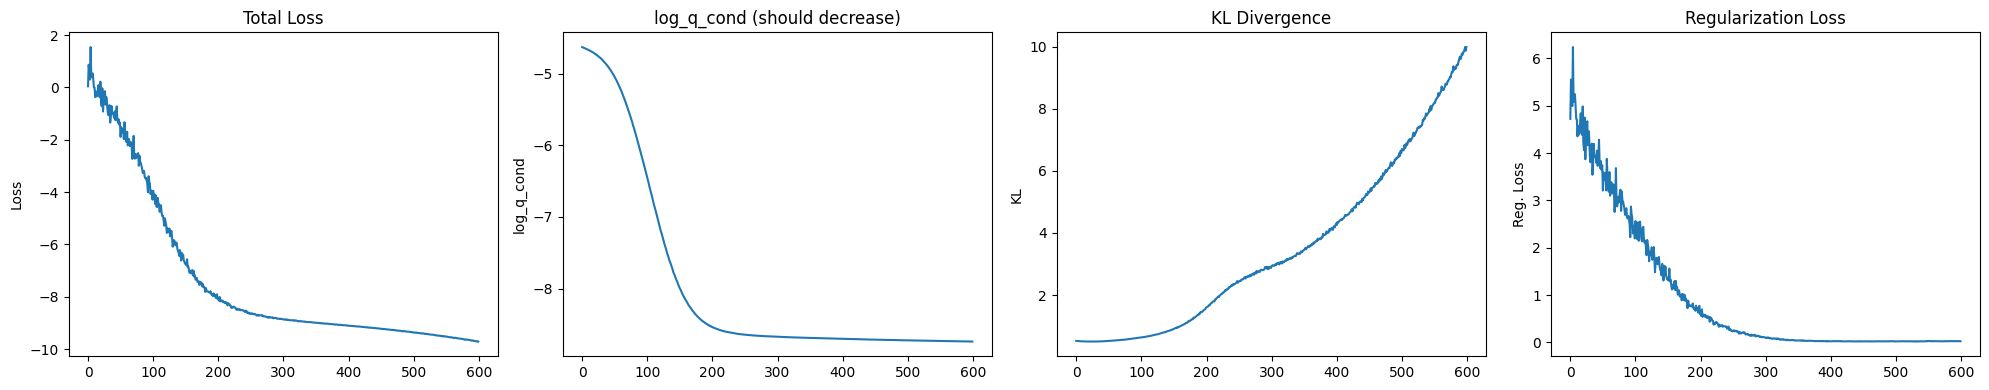

In [147]:
model.train(
    x_train=train_sims_data[:, :DATAPOINT_SIZE],
    y_train=train_sims_data[:, -1],
    nepochs=30,
    batch_size=512,
    print_losses=True
    )

assert not np.isnan(model.full_losses[-1]), "Total loss is NaN. Check the model and training process."

In [120]:
zs = model(test_sims_data[:, :DATAPOINT_SIZE]).detach().cpu()
z_min = zs.min()
z_max = zs.max()
print(f"Latent space range: min={z_min:.4f}, max={z_max:.4f}")

Latent space range: min=0.2753, max=2.9481


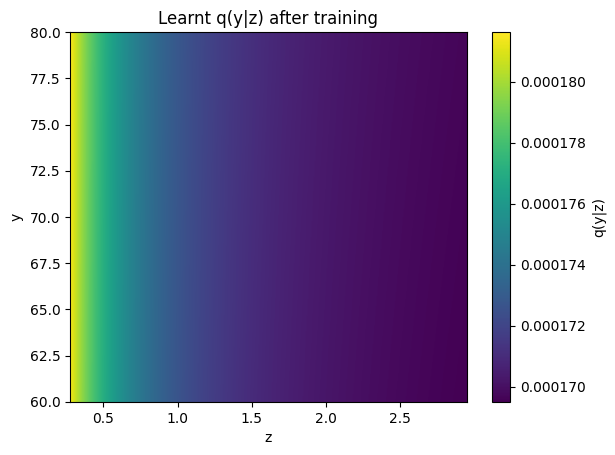

In [131]:
yz_grid = torch.tensor([[y, z] for y in np.linspace(60, 80, 500) for z in np.linspace(z_min, z_max, 500)], dtype=torch.float32).to(device)
log_q_values = model.cond_prob_model.log_prob(yz_grid[:, 0:1], yz_grid[:, 1:2]).detach().cpu()
q_values = torch.exp(log_q_values)
plt.imshow(q_values.detach().numpy().reshape(500, 500), extent=(z_min, z_max, 60, 80), origin='lower', aspect='auto')
plt.colorbar(label='q(y|z)')
plt.title("Learnt q(y|z) after training")
plt.xlabel("z")
plt.ylabel("y")
plt.show()

(array([2144.,  337.,  192.,  148.,  135.,  133.,  138.,  152.,  190.,
         431.]),
 array([-8.64849758, -8.25036621, -7.85223484, -7.45410347, -7.0559721 ,
        -6.65784073, -6.25970936, -5.86157799, -5.46344662, -5.06531525,
        -4.66718388]),
 <BarContainer object of 10 artists>)

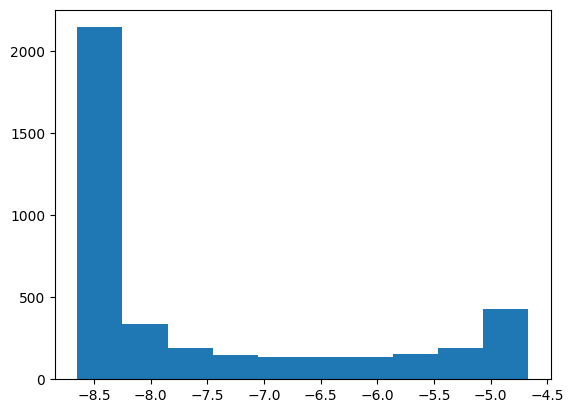

In [81]:
plt.hist(model.log_prob_losses)

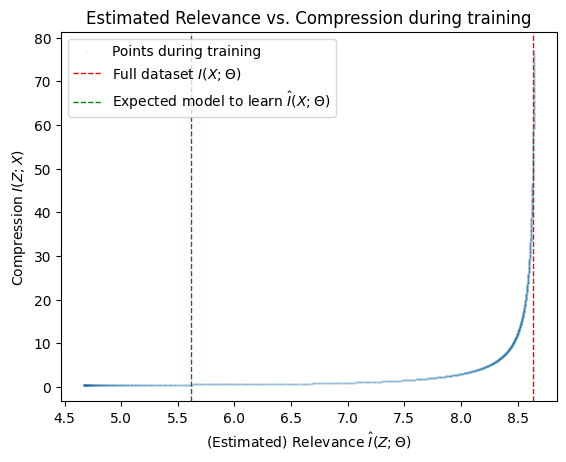

In [84]:
plt.scatter(-1*np.array(model.log_prob_losses), np.array(model.kl_losses), alpha=0.1, s=2e-1,
            label='Points during training')
# plt.yscale('log')
plt.axvline(
    x = 8.64,
    color='red',
    linestyle='--',
    linewidth=1,
    label=r'Full dataset $I(X; \Theta)$'
)
plt.axvline(
    x = 8.64 - 3.02,
    color='green',
    linestyle='--',
    linewidth=1,
    label=r'Expected model to learn $\hat{I}(X; \Theta)$'
)

plt.xlabel(r"(Estimated) Relevance $\hat{I}(Z;\Theta)$")
plt.ylabel(r"Compression $I(Z;X)$")
plt.legend()
plt.title('Estimated Relevance vs. Compression during training')
plt.show()

Training new model iteration 1...
Epoch 1: Loss=-0.6754, log_q=-4.6381,, reg. loss=4.0220, beta * KL=0.0593
Epoch 10: Loss=-8.5291, log_q=-8.5785,, reg. loss=0.2699, beta * KL=0.2205
Epoch 20: Loss=-9.2957, log_q=-8.7027,, reg. loss=0.0708, beta * KL=0.6639
Epoch 30: Loss=-10.1816, log_q=-8.7382,, reg. loss=0.1319, beta * KL=1.5753


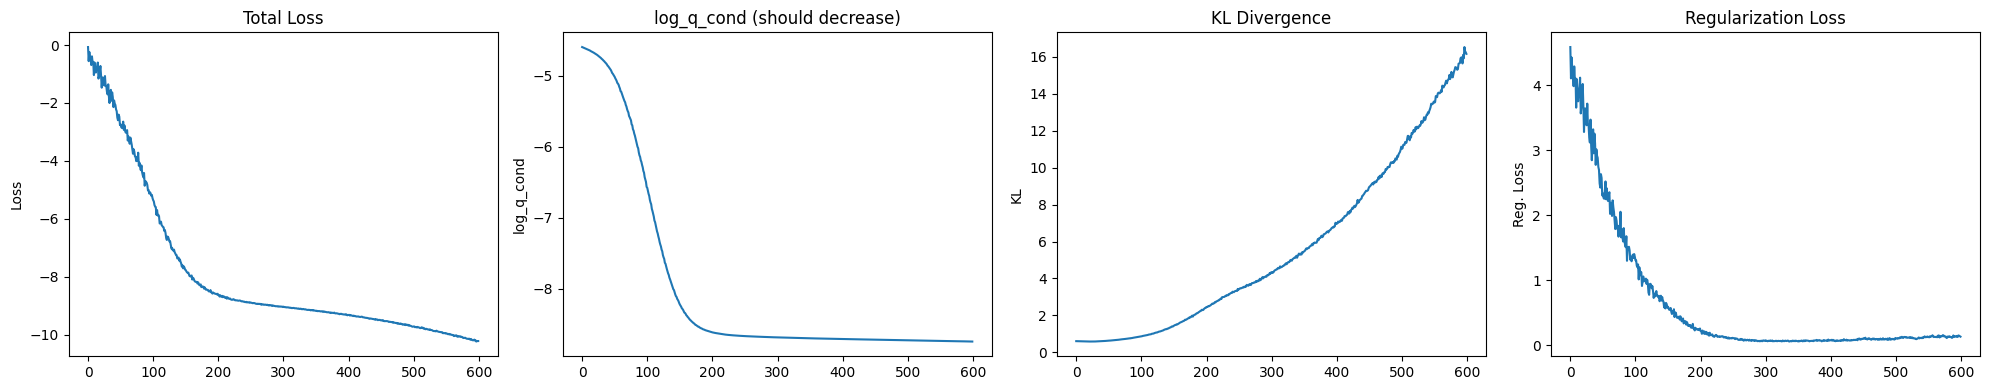

Training new model iteration 2...
Epoch 1: Loss=0.0051, log_q=-4.5579,, reg. loss=4.6198, beta * KL=0.0568
Epoch 10: Loss=-8.0821, log_q=-8.5914,, reg. loss=0.8600, beta * KL=0.3507
Epoch 20: Loss=-9.0001, log_q=-8.7043,, reg. loss=0.1564, beta * KL=0.4522
Epoch 30: Loss=-9.5029, log_q=-8.7502,, reg. loss=0.0891, beta * KL=0.8418


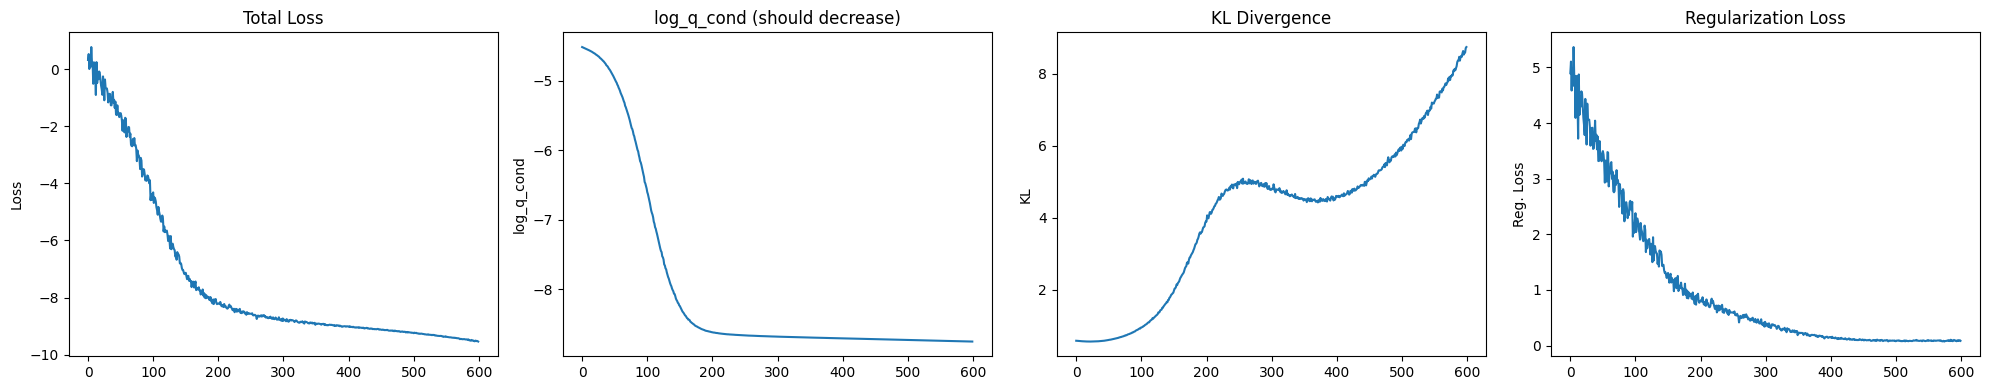

Training new model iteration 3...
Epoch 1: Loss=-1.2158, log_q=-4.5815,, reg. loss=3.4186, beta * KL=0.0529
Epoch 10: Loss=-7.9247, log_q=-8.4775,, reg. loss=0.7223, beta * KL=0.1695
Epoch 20: Loss=-9.0505, log_q=-8.6929,, reg. loss=0.0461, beta * KL=0.4038
Epoch 30: Loss=-9.6293, log_q=-8.7286,, reg. loss=0.0297, beta * KL=0.9304


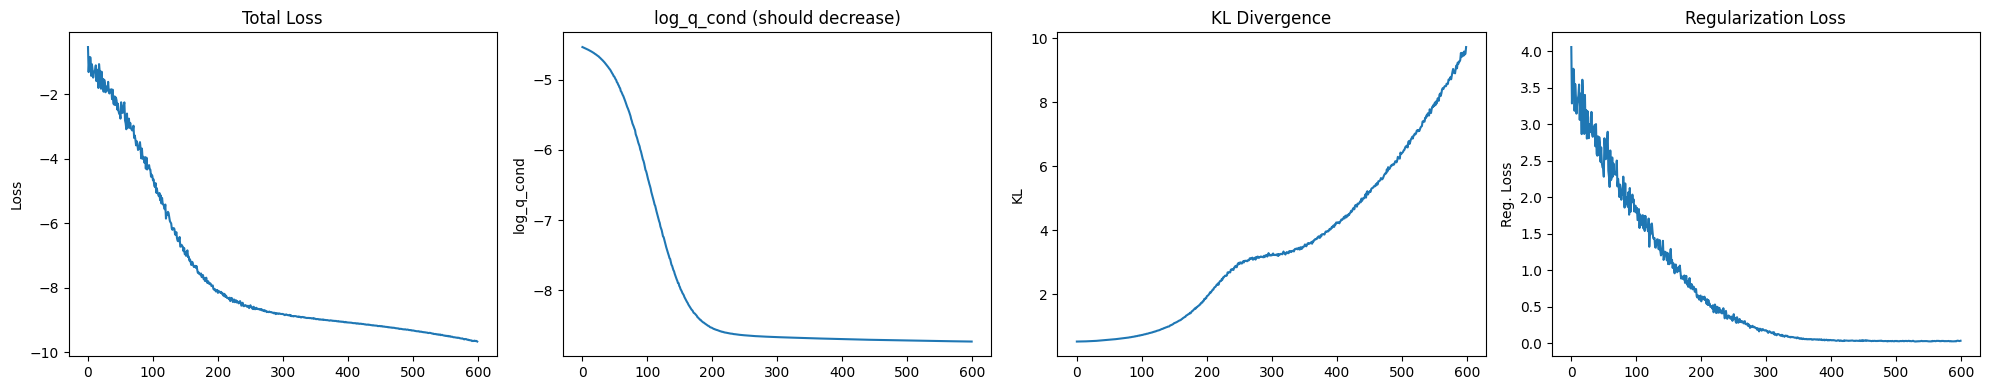

Training new model iteration 4...
Epoch 1: Loss=-0.1511, log_q=-4.5664,, reg. loss=4.4659, beta * KL=0.0506
Epoch 10: Loss=-7.6476, log_q=-8.4551,, reg. loss=0.9414, beta * KL=0.1339
Epoch 20: Loss=-9.0850, log_q=-8.7007,, reg. loss=0.0351, beta * KL=0.4194
Epoch 30: Loss=-9.7066, log_q=-8.7453,, reg. loss=0.0539, beta * KL=1.0152


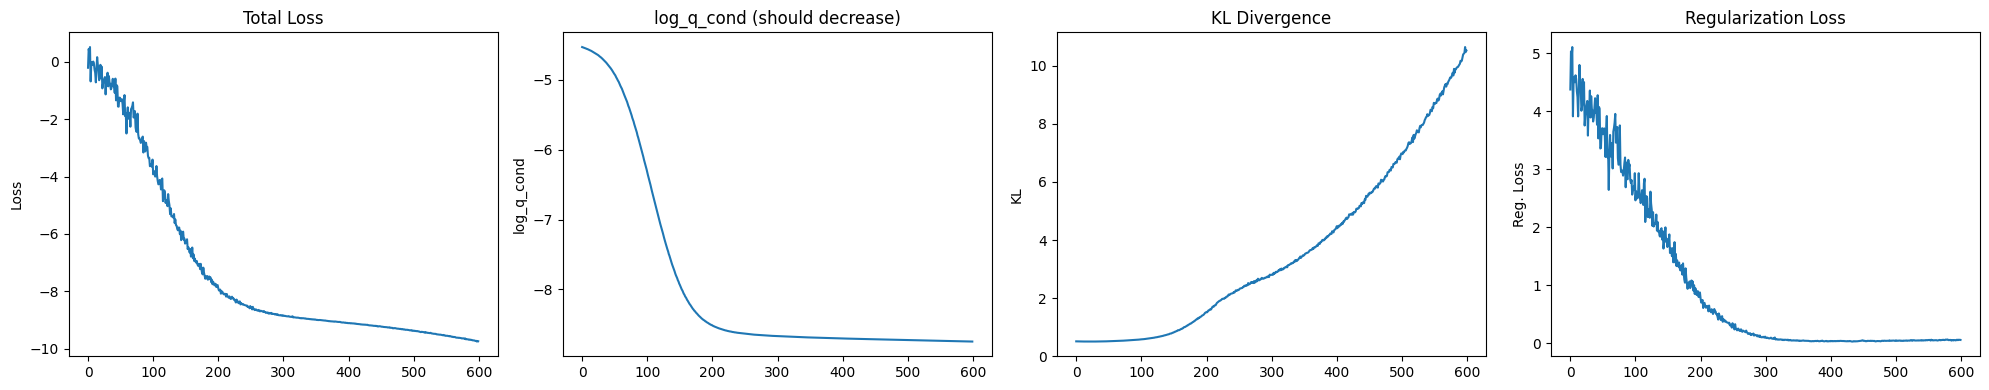

Training new model iteration 5...
Epoch 1: Loss=-2.0553, log_q=-4.5318,, reg. loss=2.5307, beta * KL=0.0542
Epoch 10: Loss=-8.4937, log_q=-8.5084,, reg. loss=0.2018, beta * KL=0.1871
Epoch 20: Loss=-9.3234, log_q=-8.6939,, reg. loss=0.0029, beta * KL=0.6324
Epoch 30: Loss=-10.3375, log_q=-8.7209,, reg. loss=0.0023, beta * KL=1.6189


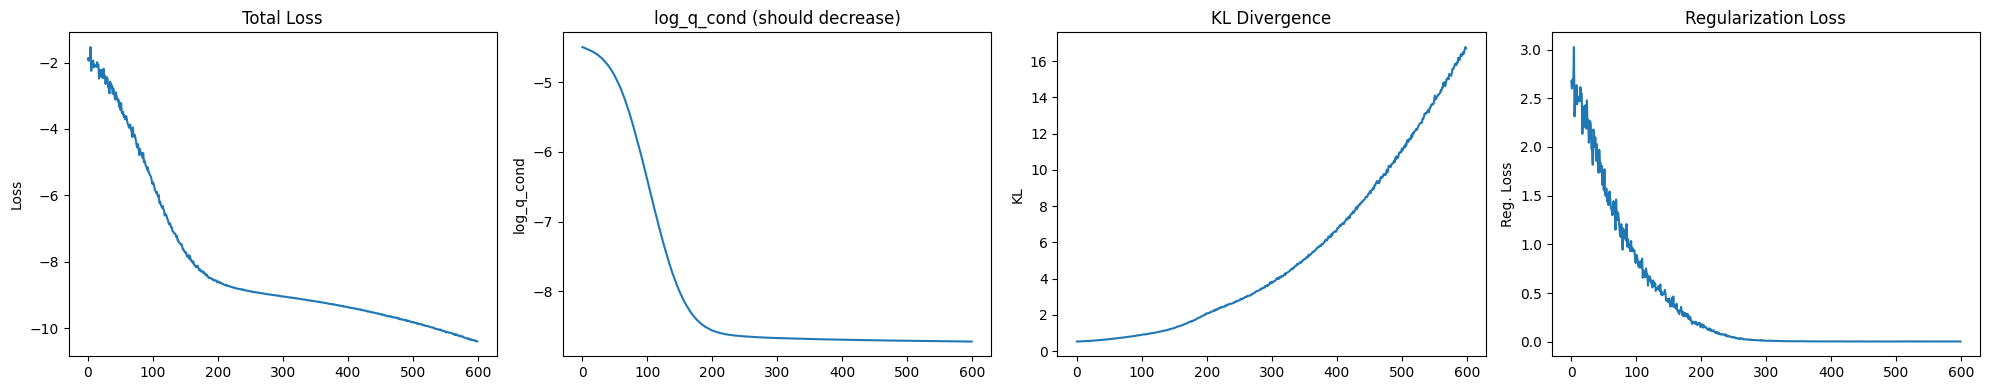

Training new model iteration 6...
Epoch 1: Loss=-1.5624, log_q=-4.8892,, reg. loss=3.3776, beta * KL=0.0508
Epoch 10: Loss=-8.4067, log_q=-8.5243,, reg. loss=0.2919, beta * KL=0.1743
Epoch 20: Loss=-9.2225, log_q=-8.6973,, reg. loss=0.0086, beta * KL=0.5338
Epoch 30: Loss=-10.0325, log_q=-8.7268,, reg. loss=0.0088, beta * KL=1.3145


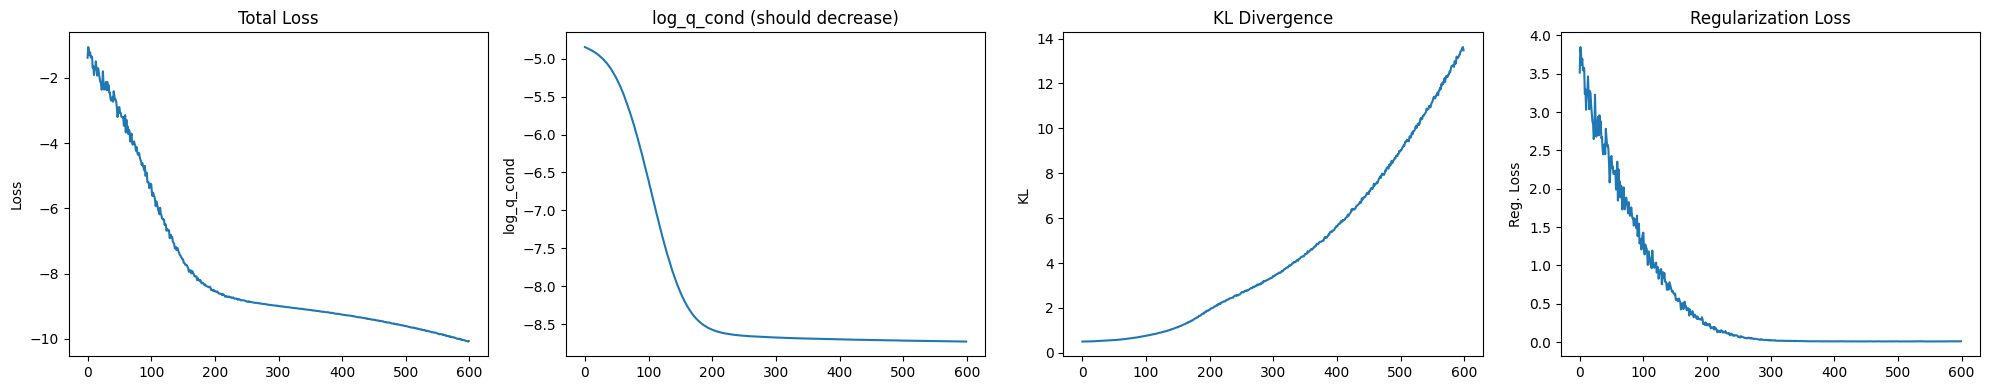

Training new model iteration 7...
Epoch 1: Loss=-1.1532, log_q=-4.4062,, reg. loss=3.3077, beta * KL=0.0547
Epoch 10: Loss=-8.5439, log_q=-8.6117,, reg. loss=0.4571, beta * KL=0.3894
Epoch 20: Loss=-9.2290, log_q=-8.6974,, reg. loss=0.1032, beta * KL=0.6349
Epoch 30: Loss=-10.0718, log_q=-8.7266,, reg. loss=0.0931, beta * KL=1.4383


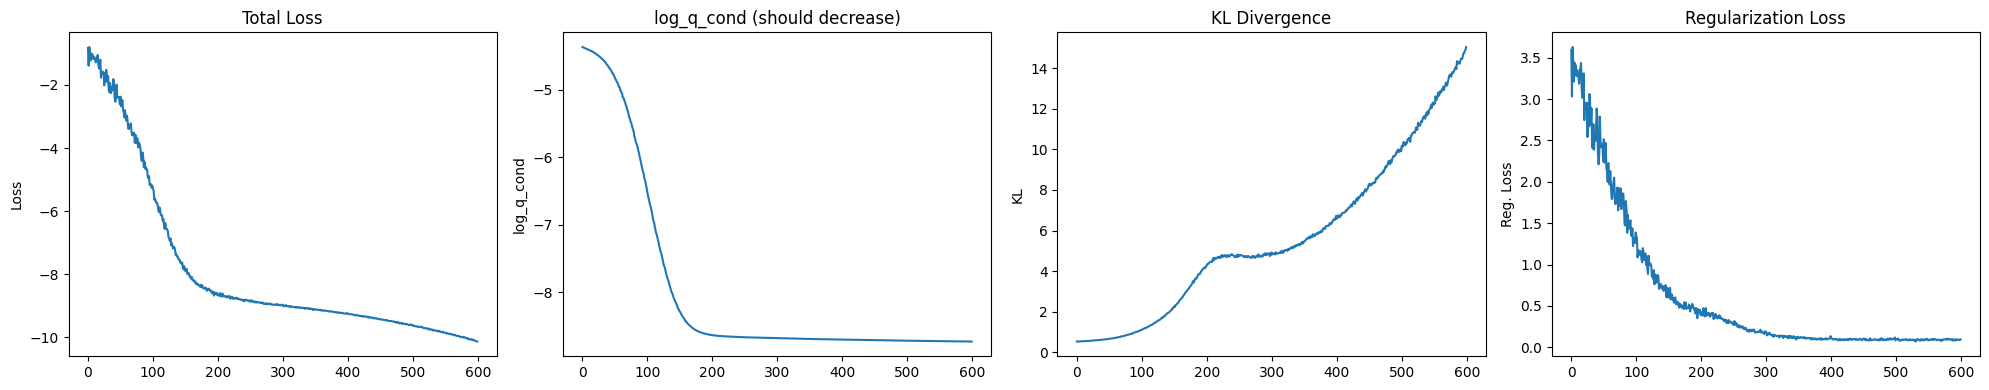

Training new model iteration 8...
Epoch 1: Loss=-1.8721, log_q=-4.7287,, reg. loss=2.9093, beta * KL=0.0527
Epoch 10: Loss=-8.4809, log_q=-8.5338,, reg. loss=0.2217, beta * KL=0.1689
Epoch 20: Loss=-9.2365, log_q=-8.6984,, reg. loss=0.0297, beta * KL=0.5678
Epoch 30: Loss=-10.0619, log_q=-8.7300,, reg. loss=0.0431, beta * KL=1.3750


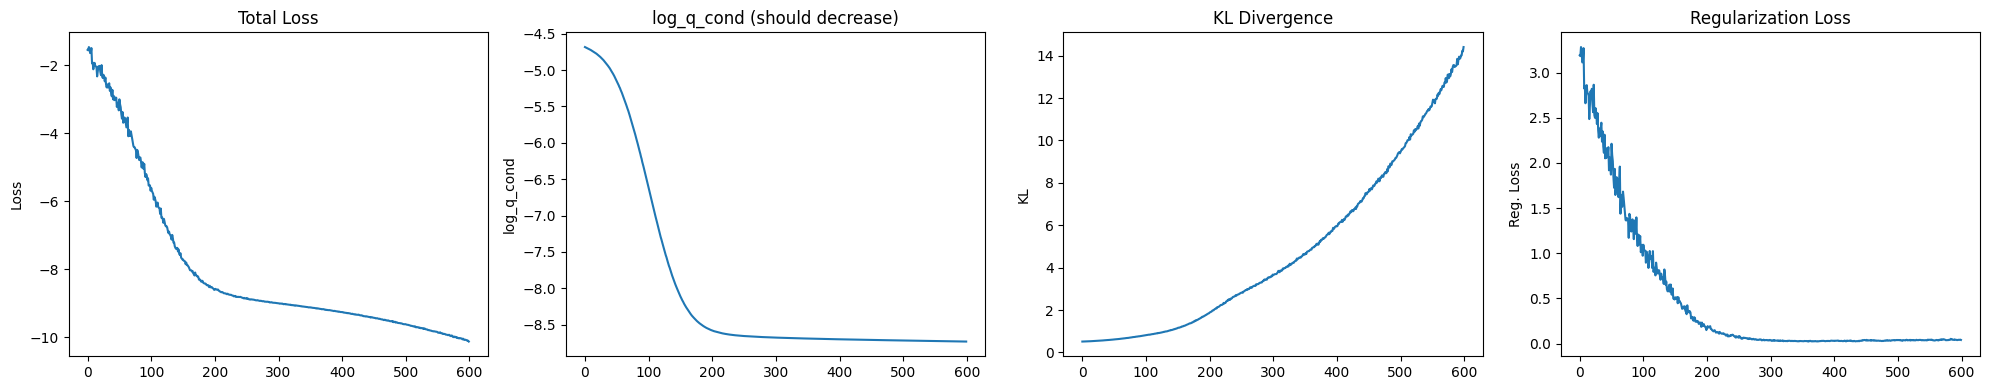

Training new model iteration 9...
Epoch 1: Loss=-2.6494, log_q=-4.9179,, reg. loss=2.3275, beta * KL=0.0590
Epoch 10: Loss=-8.4947, log_q=-8.5058,, reg. loss=0.1962, beta * KL=0.1851
Epoch 20: Loss=-9.3601, log_q=-8.6974,, reg. loss=0.0175, beta * KL=0.6802
Epoch 30: Loss=-10.4205, log_q=-8.7265,, reg. loss=0.0273, beta * KL=1.7213


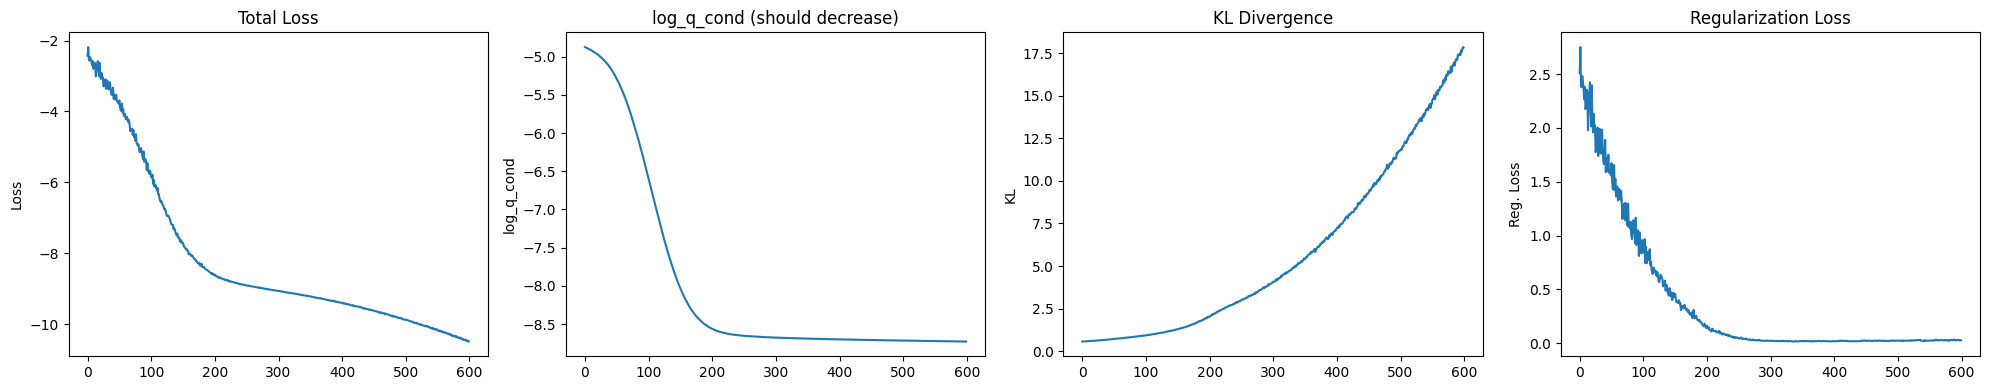

Training new model iteration 10...
Epoch 1: Loss=-1.6843, log_q=-4.5898,, reg. loss=2.9573, beta * KL=0.0519
Epoch 10: Loss=-8.6074, log_q=-8.5873,, reg. loss=0.2048, beta * KL=0.2250
Epoch 20: Loss=-9.3489, log_q=-8.7005,, reg. loss=0.0150, beta * KL=0.6634
Epoch 30: Loss=-10.4233, log_q=-8.7302,, reg. loss=0.0139, beta * KL=1.7070


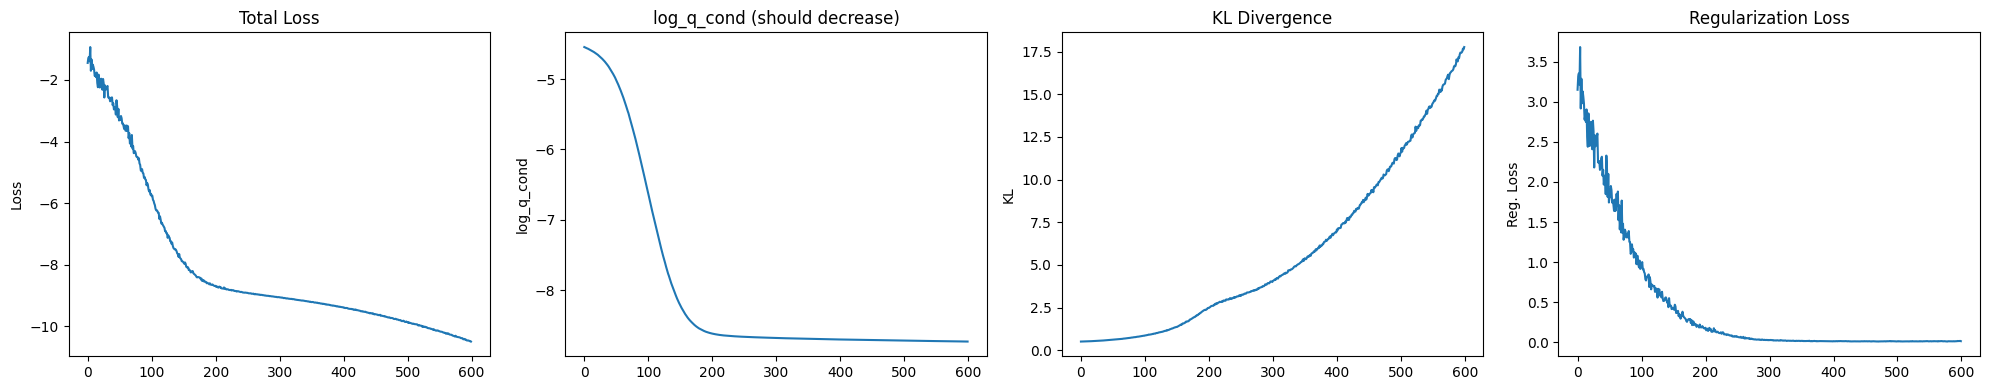

Training new model iteration 11...
Epoch 1: Loss=-1.2479, log_q=-4.5090,, reg. loss=3.3140, beta * KL=0.0529
Epoch 10: Loss=-8.2534, log_q=-8.5077,, reg. loss=0.4766, beta * KL=0.2223
Epoch 20: Loss=-9.1158, log_q=-8.6987,, reg. loss=0.0907, beta * KL=0.5078
Epoch 30: Loss=-9.7678, log_q=-8.7350,, reg. loss=0.0713, beta * KL=1.1041


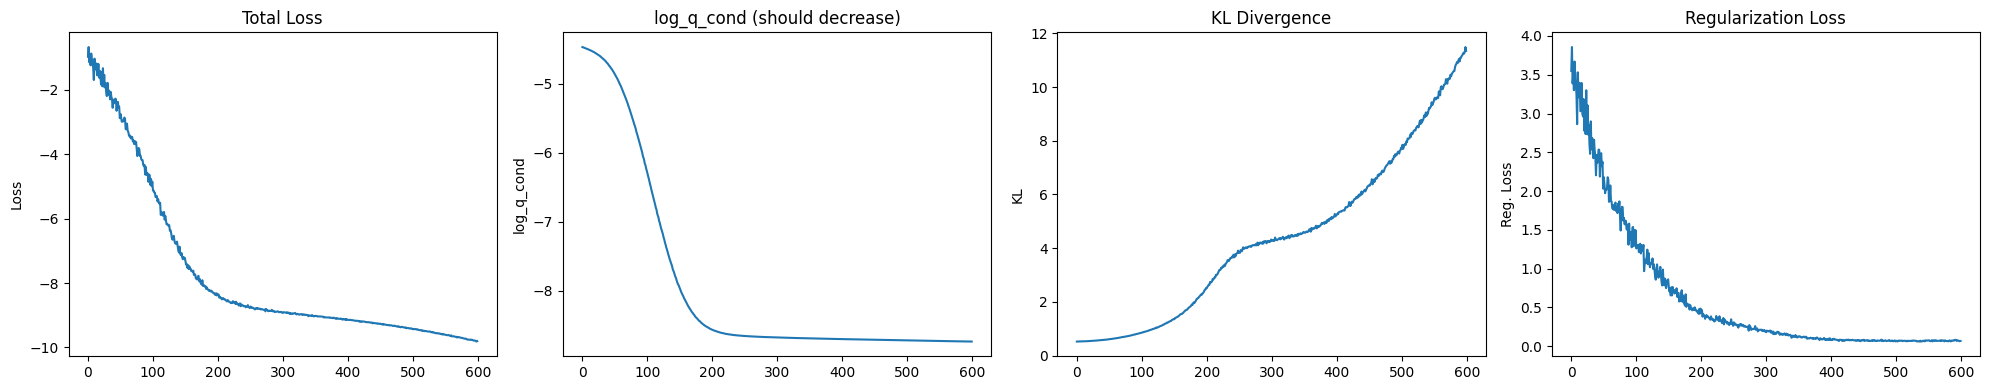

Training new model iteration 12...
Epoch 1: Loss=-1.4052, log_q=-4.5376,, reg. loss=3.1866, beta * KL=0.0542
Epoch 10: Loss=-8.2662, log_q=-8.5356,, reg. loss=0.4204, beta * KL=0.1509
Epoch 20: Loss=-9.1937, log_q=-8.7025,, reg. loss=0.0553, beta * KL=0.5465
Epoch 30: Loss=-9.9715, log_q=-8.7466,, reg. loss=0.0935, beta * KL=1.3184


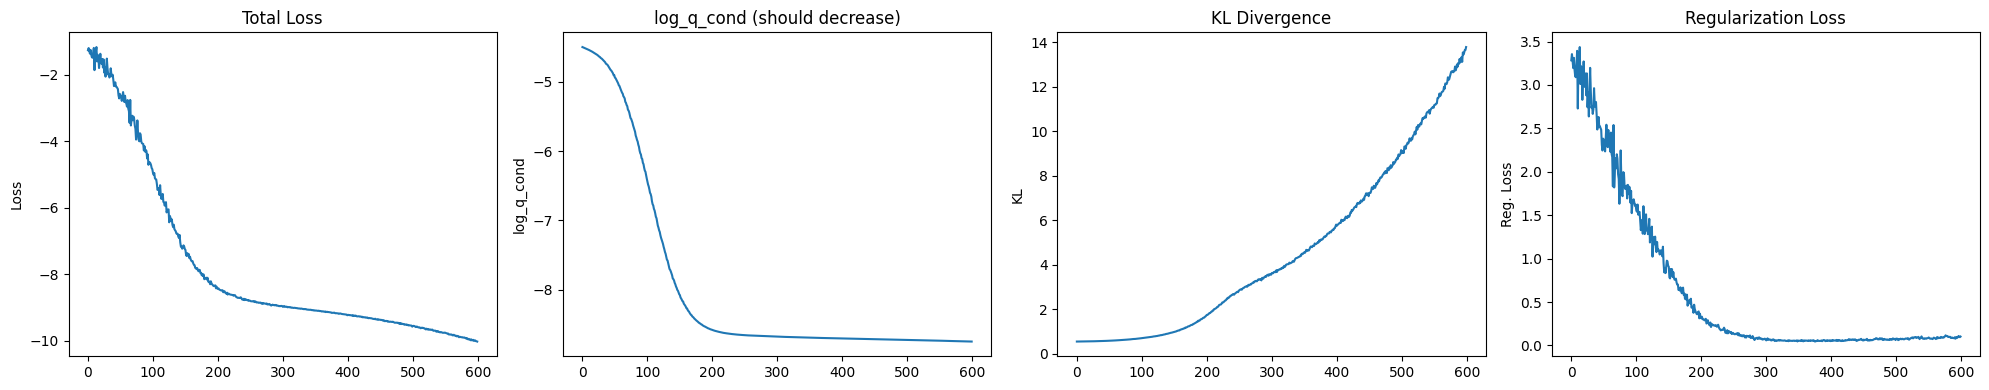

Training new model iteration 13...
Epoch 1: Loss=-0.8930, log_q=-4.6735,, reg. loss=3.8335, beta * KL=0.0529
Epoch 10: Loss=-8.3715, log_q=-8.5566,, reg. loss=0.4110, beta * KL=0.2259
Epoch 20: Loss=-9.1743, log_q=-8.7011,, reg. loss=0.0370, beta * KL=0.5102
Epoch 30: Loss=-9.8802, log_q=-8.7334,, reg. loss=0.0419, beta * KL=1.1886


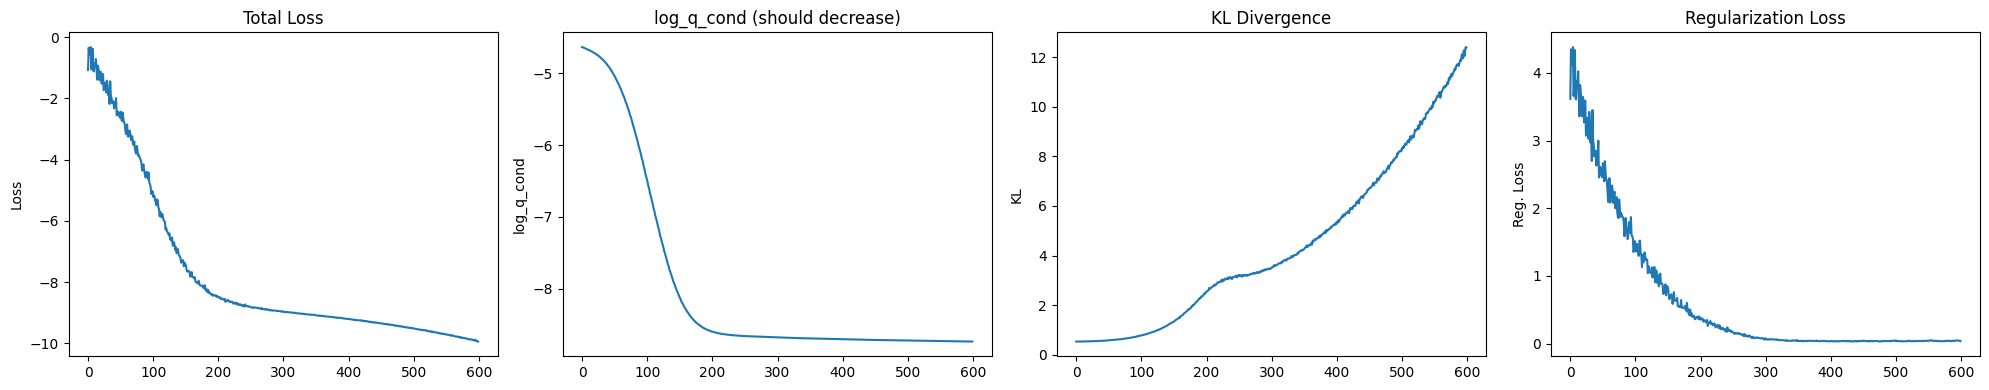

Training new model iteration 14...
Epoch 1: Loss=-0.9525, log_q=-4.8556,, reg. loss=3.9532, beta * KL=0.0502
Epoch 10: Loss=-8.4749, log_q=-8.5586,, reg. loss=0.2635, beta * KL=0.1799
Epoch 20: Loss=-9.2404, log_q=-8.6986,, reg. loss=0.0039, beta * KL=0.5457
Epoch 30: Loss=-10.0712, log_q=-8.7266,, reg. loss=0.0029, beta * KL=1.3475


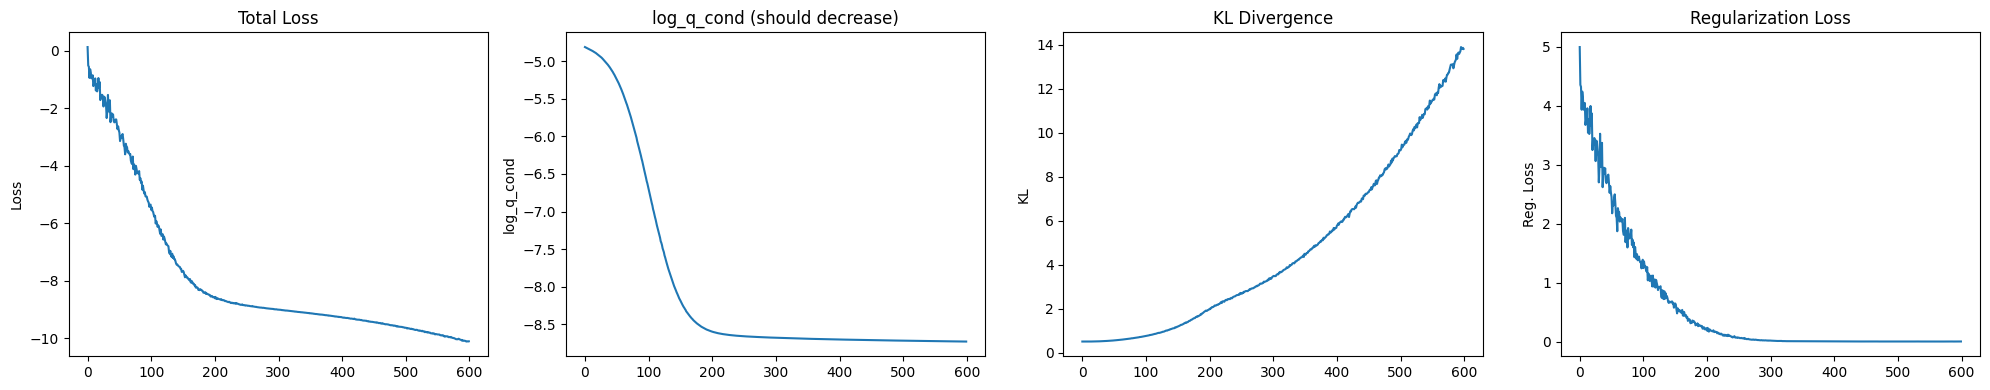

Training new model iteration 15...
Epoch 1: Loss=-0.4715, log_q=-4.8061,, reg. loss=4.3850, beta * KL=0.0504
Epoch 10: Loss=-8.1185, log_q=-8.5351,, reg. loss=0.5468, beta * KL=0.1302
Epoch 20: Loss=-9.0740, log_q=-8.7043,, reg. loss=0.0093, beta * KL=0.3789
Epoch 30: Loss=-9.6163, log_q=-8.7433,, reg. loss=0.0097, beta * KL=0.8827


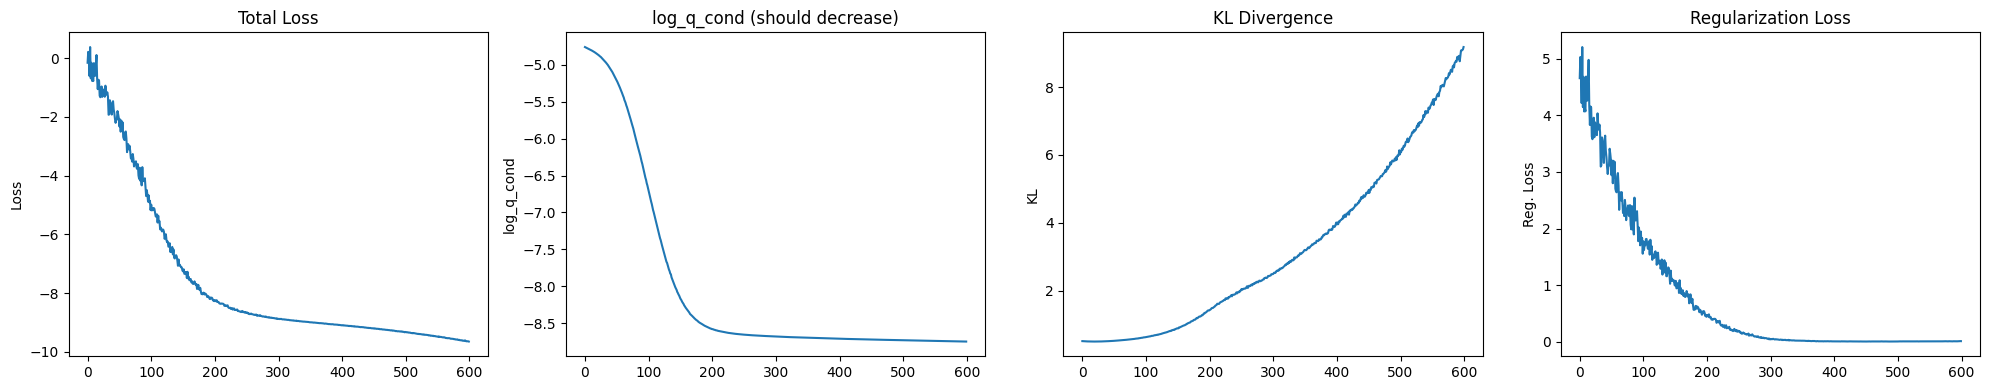

Training new model iteration 16...
Epoch 1: Loss=-1.4406, log_q=-4.6817,, reg. loss=3.2988, beta * KL=0.0577
Epoch 10: Loss=-8.5619, log_q=-8.5863,, reg. loss=0.2902, beta * KL=0.2659
Epoch 20: Loss=-9.2875, log_q=-8.7057,, reg. loss=0.0673, beta * KL=0.6491
Epoch 30: Loss=-10.1715, log_q=-8.7441,, reg. loss=0.0978, beta * KL=1.5251


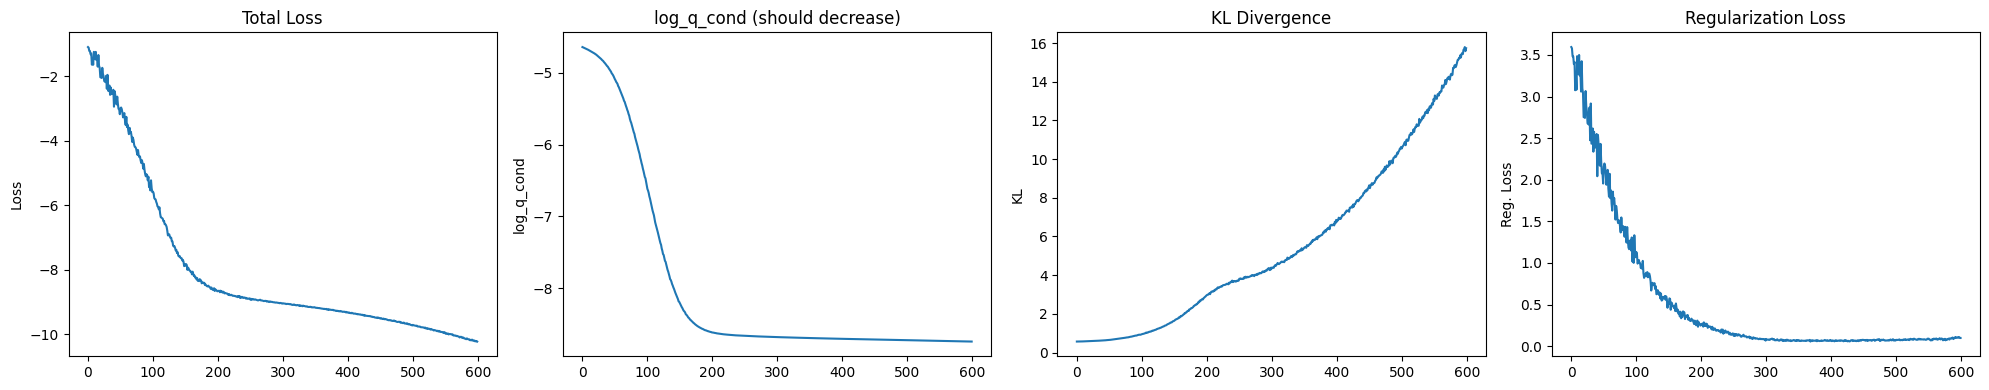

Training new model iteration 17...
Epoch 1: Loss=-1.3523, log_q=-4.6843,, reg. loss=3.3828, beta * KL=0.0508
Epoch 10: Loss=-8.3668, log_q=-8.5010,, reg. loss=0.2741, beta * KL=0.1399
Epoch 20: Loss=-9.1778, log_q=-8.6970,, reg. loss=0.0136, beta * KL=0.4944
Epoch 30: Loss=-9.8617, log_q=-8.7274,, reg. loss=0.0207, beta * KL=1.1549


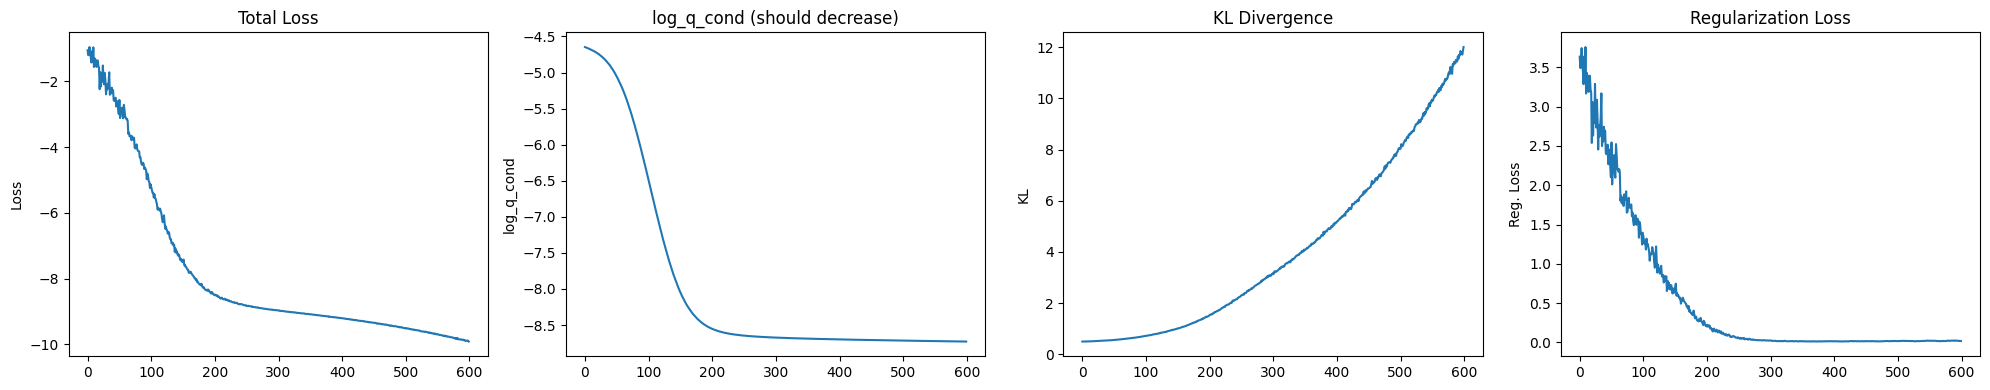

Training new model iteration 18...
Epoch 1: Loss=0.1331, log_q=-4.6939,, reg. loss=4.8780, beta * KL=0.0510
Epoch 10: Loss=-7.8140, log_q=-8.4914,, reg. loss=0.7764, beta * KL=0.0991
Epoch 20: Loss=-9.0351, log_q=-8.7004,, reg. loss=0.0217, beta * KL=0.3564
Epoch 30: Loss=-9.5597, log_q=-8.7423,, reg. loss=0.0252, beta * KL=0.8426


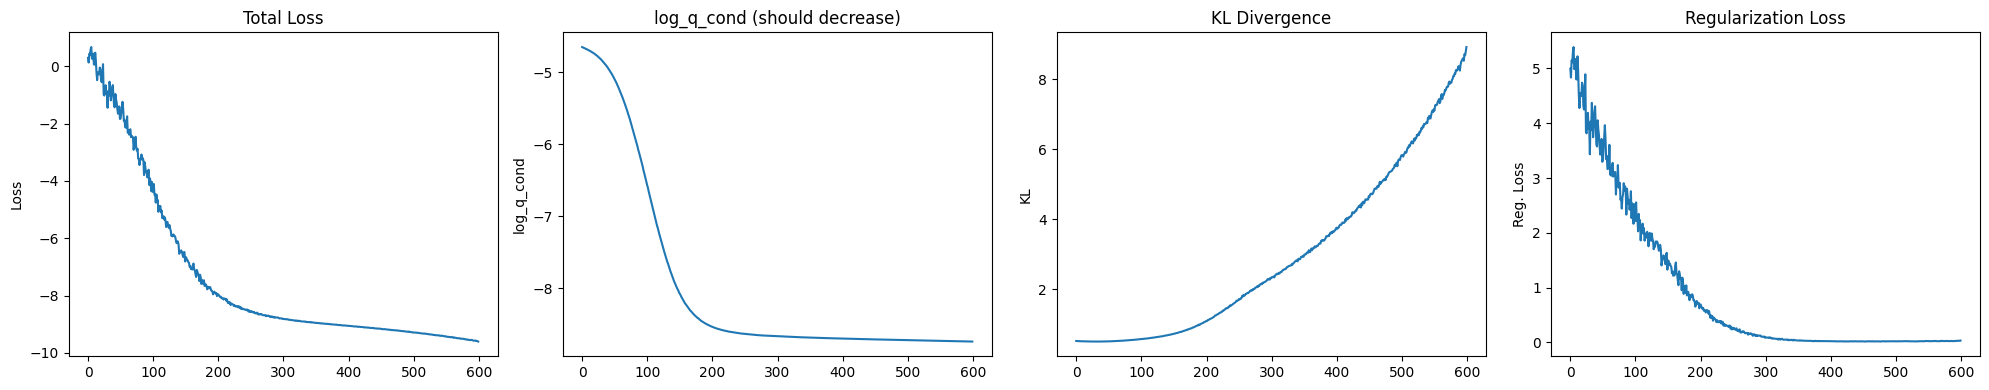

Training new model iteration 19...
Epoch 1: Loss=-1.7369, log_q=-4.5976,, reg. loss=2.9133, beta * KL=0.0527
Epoch 10: Loss=-8.4822, log_q=-8.5023,, reg. loss=0.2056, beta * KL=0.1855
Epoch 20: Loss=-9.3482, log_q=-8.6944,, reg. loss=0.0136, beta * KL=0.6674
Epoch 30: Loss=-10.4251, log_q=-8.7207,, reg. loss=0.0199, beta * KL=1.7243


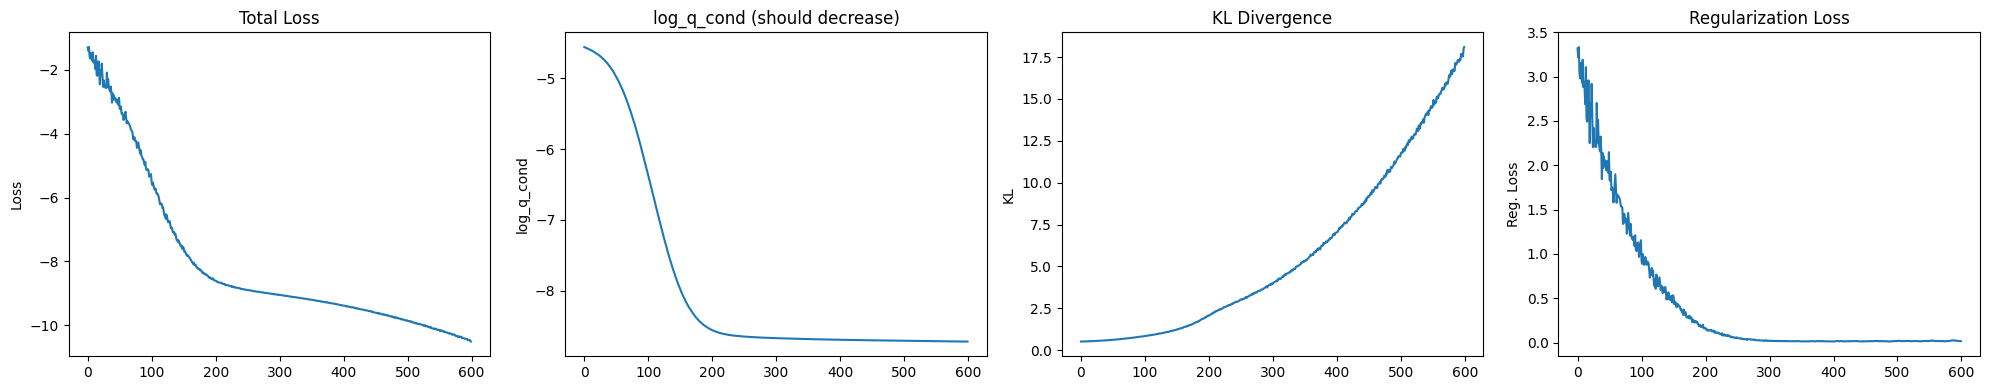

Training new model iteration 20...
Epoch 1: Loss=-1.8903, log_q=-4.7108,, reg. loss=2.8746, beta * KL=0.0541
Epoch 10: Loss=-8.5012, log_q=-8.5383,, reg. loss=0.2258, beta * KL=0.1887
Epoch 20: Loss=-9.2801, log_q=-8.7013,, reg. loss=0.0387, beta * KL=0.6176
Epoch 30: Loss=-10.1624, log_q=-8.7327,, reg. loss=0.0579, beta * KL=1.4877


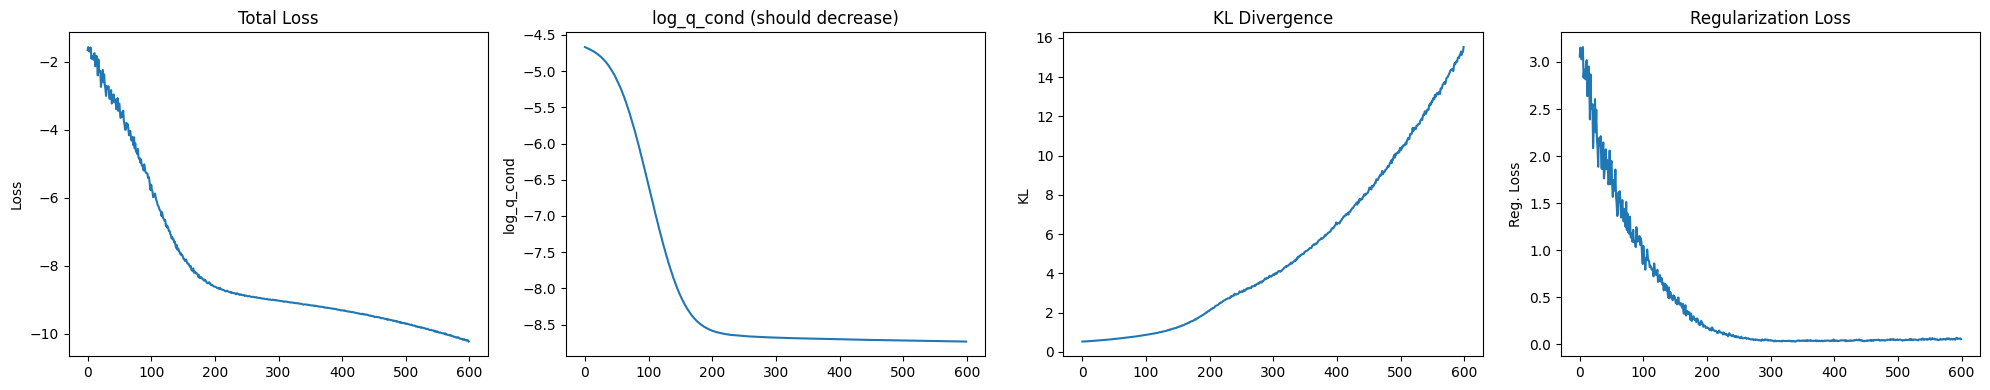

Training new model iteration 21...
Epoch 1: Loss=-1.3760, log_q=-4.6330,, reg. loss=3.3094, beta * KL=0.0524
Epoch 10: Loss=-8.4060, log_q=-8.6012,, reg. loss=0.4797, beta * KL=0.2845
Epoch 20: Loss=-9.1328, log_q=-8.7051,, reg. loss=0.0870, beta * KL=0.5148
Epoch 30: Loss=-9.7473, log_q=-8.7494,, reg. loss=0.1142, beta * KL=1.1122


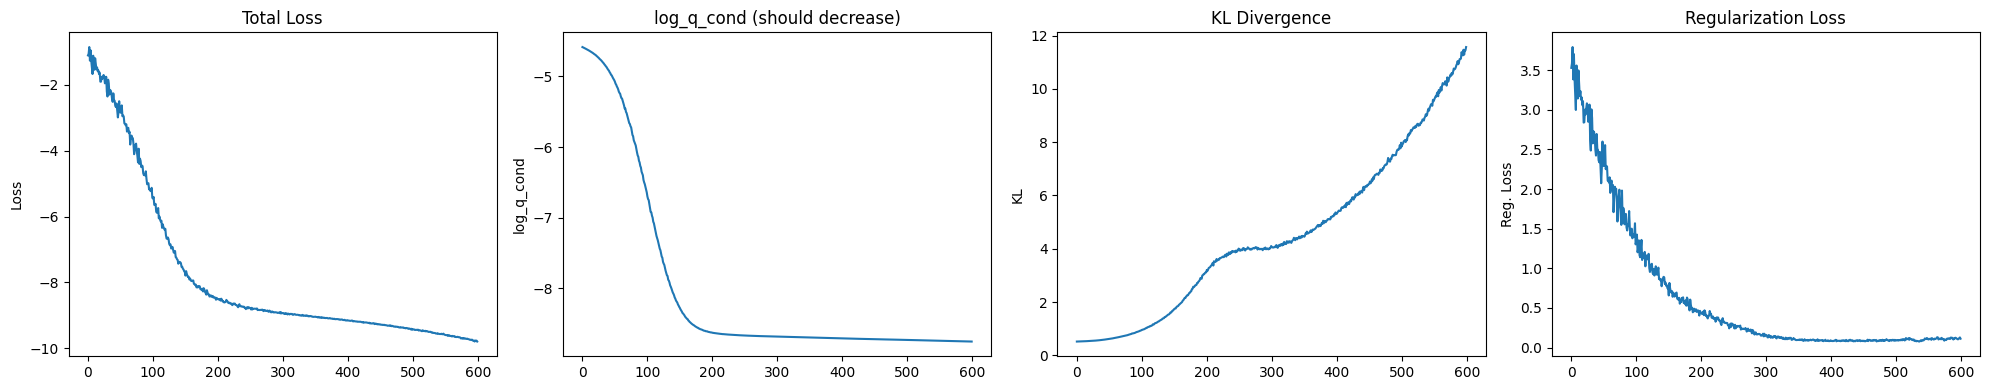

Training new model iteration 22...
Epoch 1: Loss=-1.6747, log_q=-4.4665,, reg. loss=2.8443, beta * KL=0.0526
Epoch 10: Loss=-8.4732, log_q=-8.5408,, reg. loss=0.2876, beta * KL=0.2200
Epoch 20: Loss=-9.2982, log_q=-8.6933,, reg. loss=0.0028, beta * KL=0.6078
Epoch 30: Loss=-10.2877, log_q=-8.7204,, reg. loss=0.0003, beta * KL=1.5676


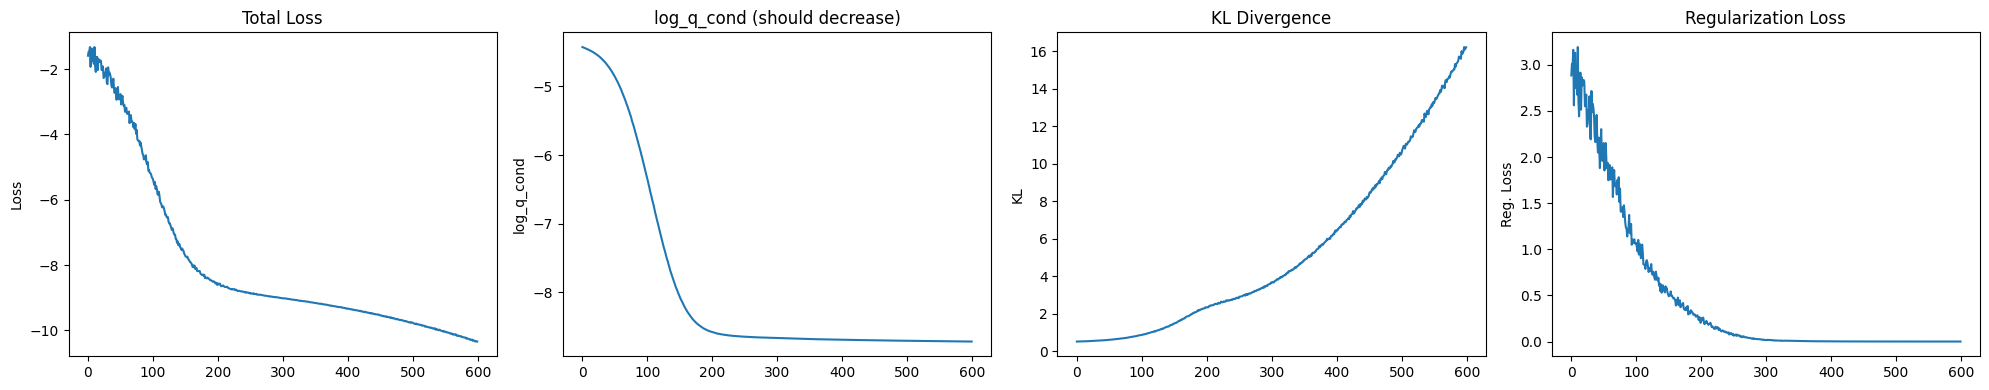

Training new model iteration 23...
Epoch 1: Loss=-0.3421, log_q=-4.6094,, reg. loss=4.3197, beta * KL=0.0524
Epoch 10: Loss=-8.1818, log_q=-8.4975,, reg. loss=0.4366, beta * KL=0.1209
Epoch 20: Loss=-9.1433, log_q=-8.6993,, reg. loss=0.0178, beta * KL=0.4618
Epoch 30: Loss=-9.7905, log_q=-8.7343,, reg. loss=0.0369, beta * KL=1.0930


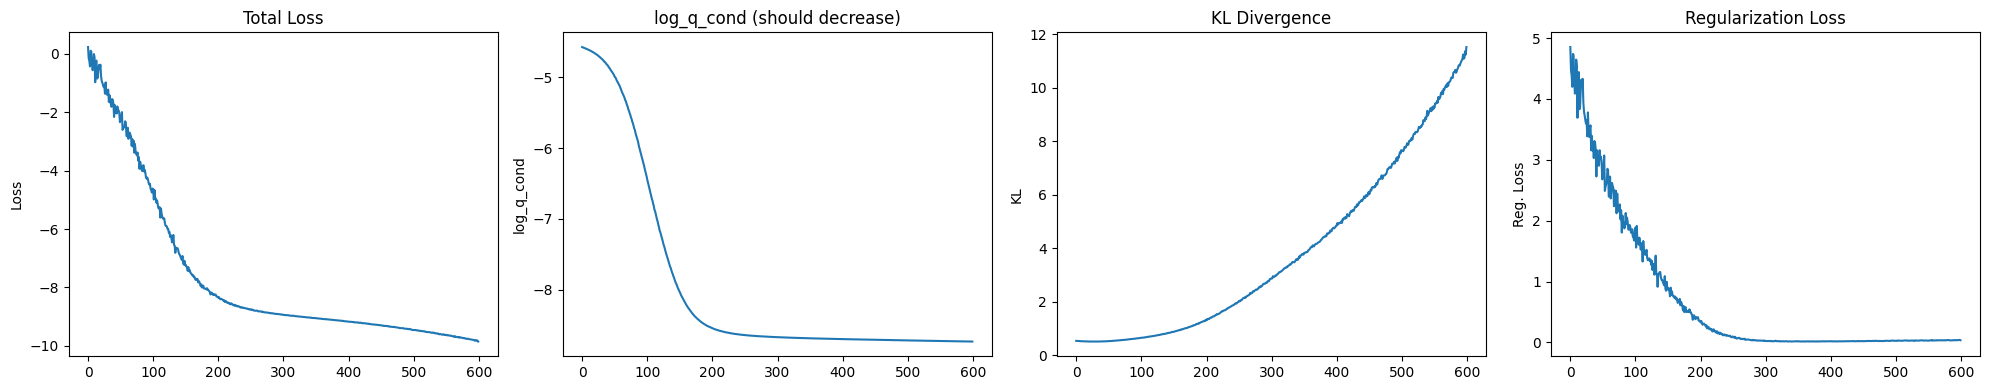

Training new model iteration 24...
Epoch 1: Loss=-0.4582, log_q=-4.5409,, reg. loss=4.1334, beta * KL=0.0507
Epoch 10: Loss=-8.3736, log_q=-8.5120,, reg. loss=0.2911, beta * KL=0.1527
Epoch 20: Loss=-9.2640, log_q=-8.7003,, reg. loss=0.0173, beta * KL=0.5810
Epoch 30: Loss=-10.2139, log_q=-8.7309,, reg. loss=0.0329, beta * KL=1.5158


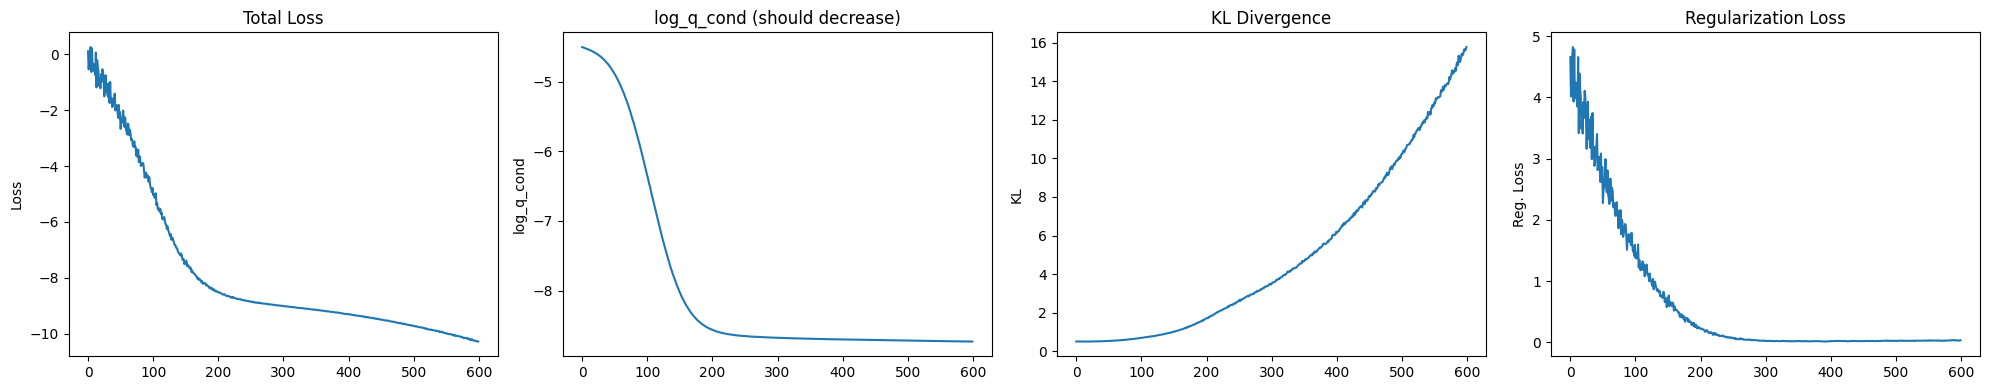

Training new model iteration 25...
Epoch 1: Loss=-2.1248, log_q=-4.6871,, reg. loss=2.6192, beta * KL=0.0569
Epoch 10: Loss=-8.5389, log_q=-8.5641,, reg. loss=0.2872, beta * KL=0.2620
Epoch 20: Loss=-9.3369, log_q=-8.6993,, reg. loss=0.0291, beta * KL=0.6667
Epoch 30: Loss=-10.3677, log_q=-8.7308,, reg. loss=0.0424, beta * KL=1.6793


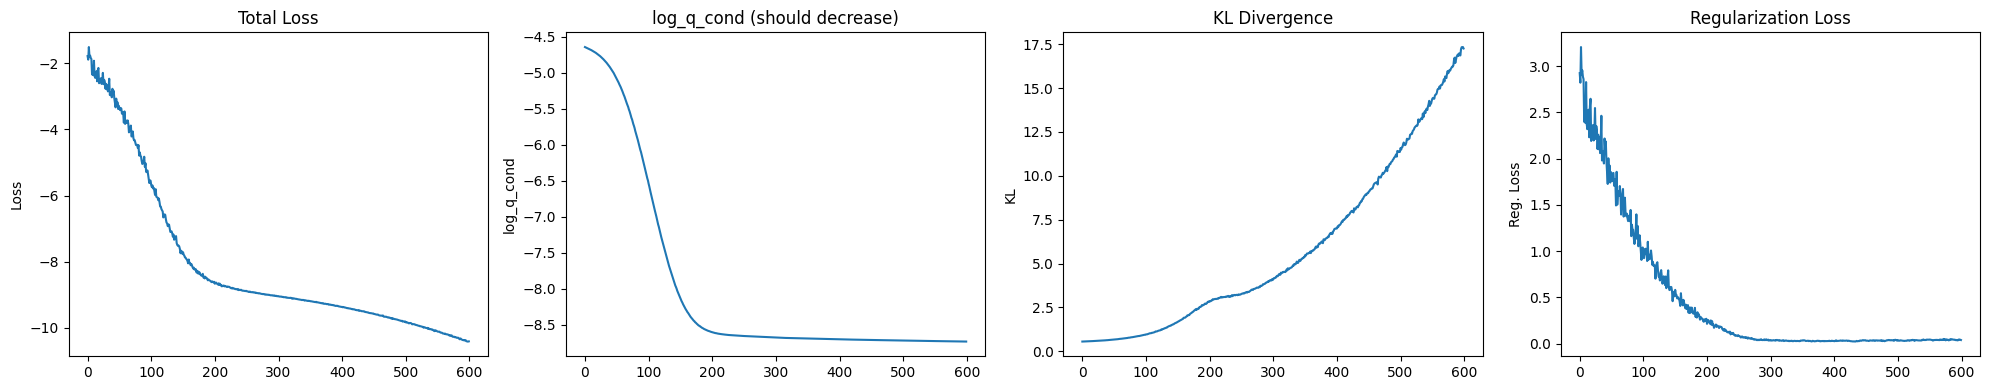

Training new model iteration 26...
Epoch 1: Loss=-1.8220, log_q=-4.5169,, reg. loss=2.7481, beta * KL=0.0532
Epoch 10: Loss=-8.5278, log_q=-8.5454,, reg. loss=0.2710, beta * KL=0.2534
Epoch 20: Loss=-9.2884, log_q=-8.6981,, reg. loss=0.0206, beta * KL=0.6109
Epoch 30: Loss=-10.2712, log_q=-8.7280,, reg. loss=0.0098, beta * KL=1.5531


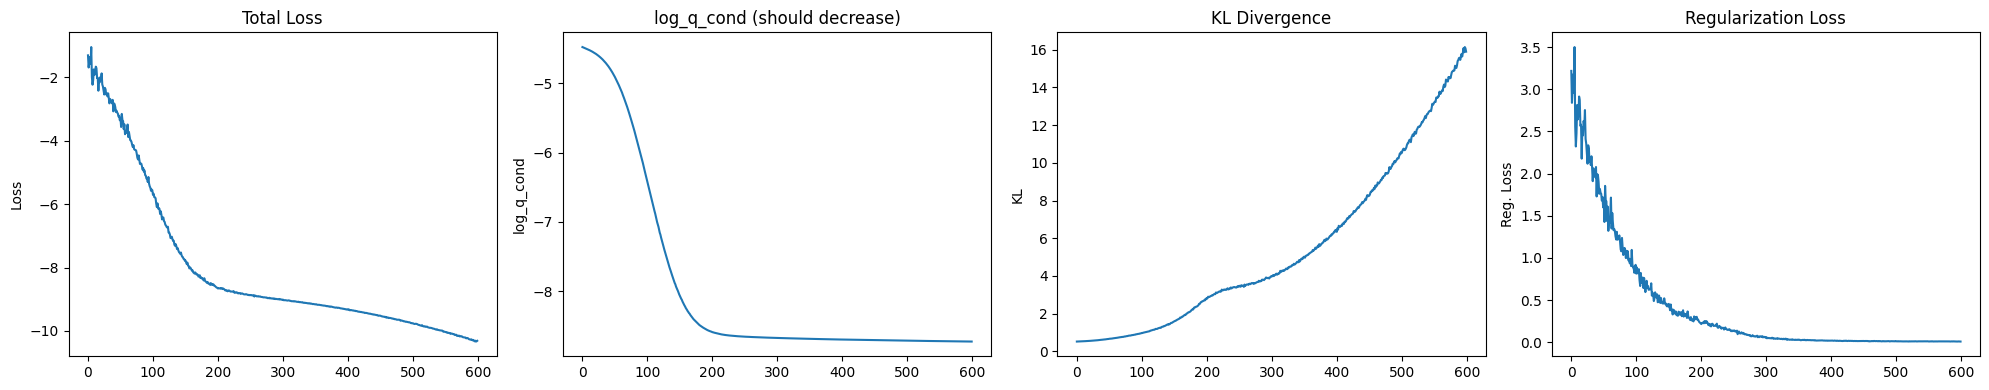

Training new model iteration 27...
Epoch 1: Loss=-0.0071, log_q=-4.5832,, reg. loss=4.6268, beta * KL=0.0507
Epoch 10: Loss=-7.7903, log_q=-8.4649,, reg. loss=0.7744, beta * KL=0.0999
Epoch 20: Loss=-9.0219, log_q=-8.6992,, reg. loss=0.0103, beta * KL=0.3330
Epoch 30: Loss=-9.5027, log_q=-8.7392,, reg. loss=0.0026, beta * KL=0.7661


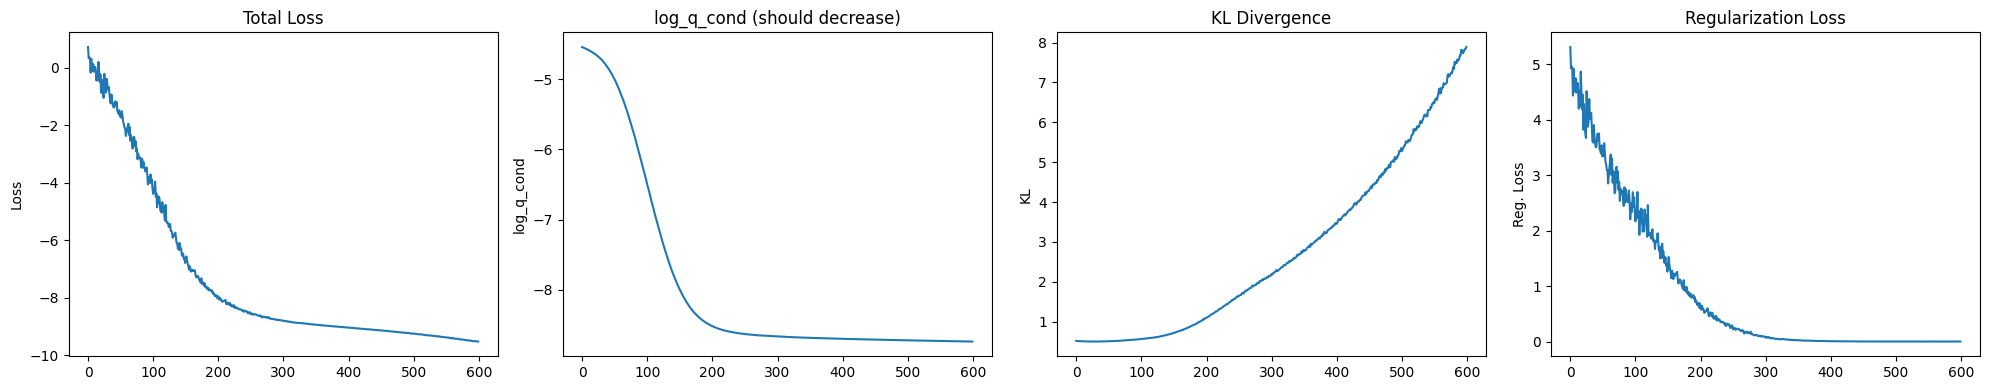

Training new model iteration 28...
Epoch 1: Loss=-1.6495, log_q=-4.8299,, reg. loss=3.2313, beta * KL=0.0509
Epoch 10: Loss=-8.5748, log_q=-8.5602,, reg. loss=0.2276, beta * KL=0.2422
Epoch 20: Loss=-9.3693, log_q=-8.6996,, reg. loss=0.0285, beta * KL=0.6982
Epoch 30: Loss=-10.4446, log_q=-8.7275,, reg. loss=0.0311, beta * KL=1.7483


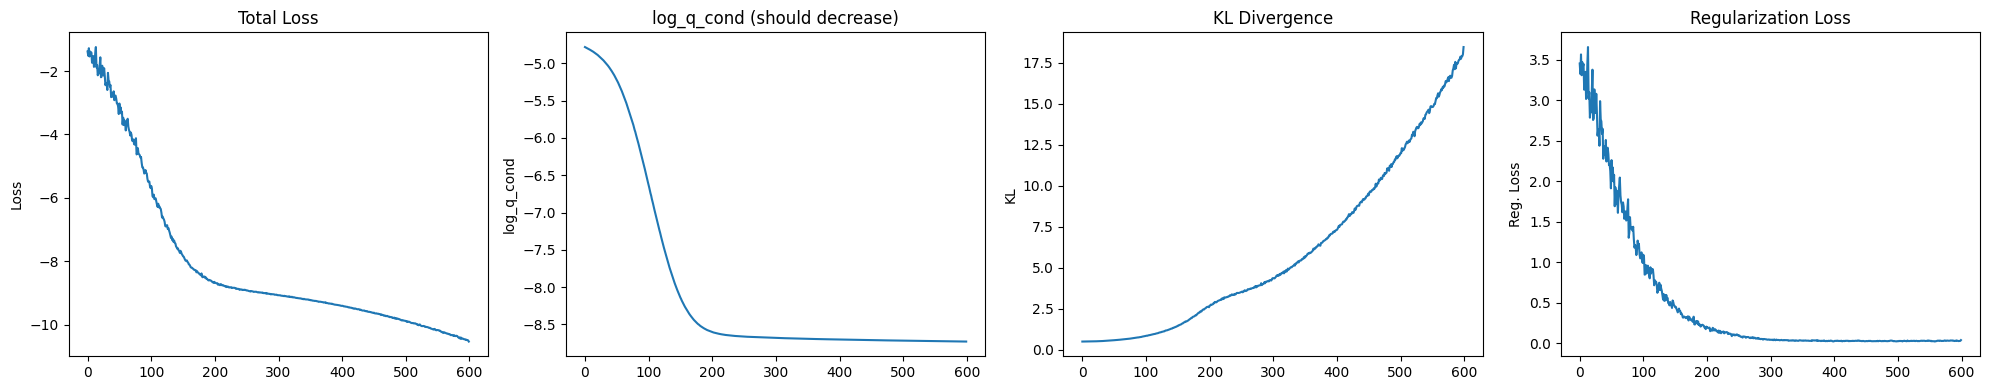

Training new model iteration 29...
Epoch 1: Loss=-1.0282, log_q=-4.5132,, reg. loss=3.5385, beta * KL=0.0535
Epoch 10: Loss=-8.0437, log_q=-8.4662,, reg. loss=0.5354, beta * KL=0.1129
Epoch 20: Loss=-9.1156, log_q=-8.6999,, reg. loss=0.0203, beta * KL=0.4360
Epoch 30: Loss=-9.7849, log_q=-8.7369,, reg. loss=0.0376, beta * KL=1.0856


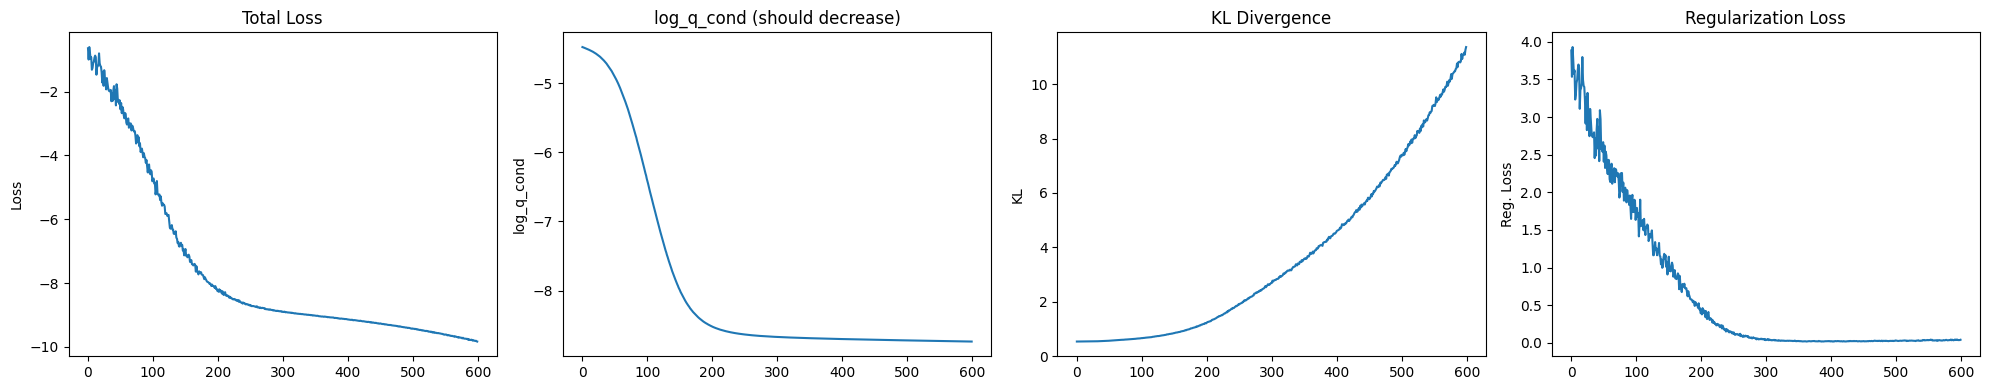

Training new model iteration 30...
Epoch 1: Loss=-1.1680, log_q=-4.6936,, reg. loss=3.5768, beta * KL=0.0513
Epoch 10: Loss=-8.5223, log_q=-8.5519,, reg. loss=0.2250, beta * KL=0.1953
Epoch 20: Loss=-9.2806, log_q=-8.7004,, reg. loss=0.0283, beta * KL=0.6084
Epoch 30: Loss=-10.1856, log_q=-8.7300,, reg. loss=0.0310, beta * KL=1.4866


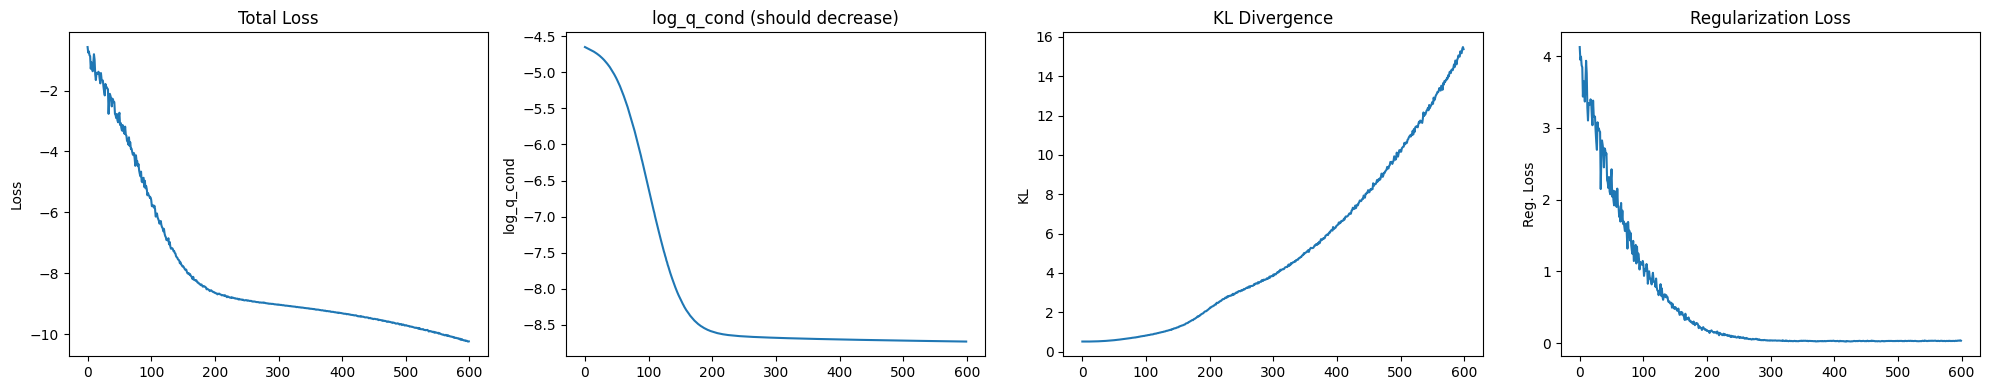

Training new model iteration 31...
Epoch 1: Loss=-2.0067, log_q=-4.8225,, reg. loss=2.8685, beta * KL=0.0527
Epoch 10: Loss=-8.5884, log_q=-8.5515,, reg. loss=0.1857, beta * KL=0.2226
Epoch 20: Loss=-9.3964, log_q=-8.6990,, reg. loss=0.0423, beta * KL=0.7397
Epoch 30: Loss=-10.5245, log_q=-8.7268,, reg. loss=0.0602, beta * KL=1.8579


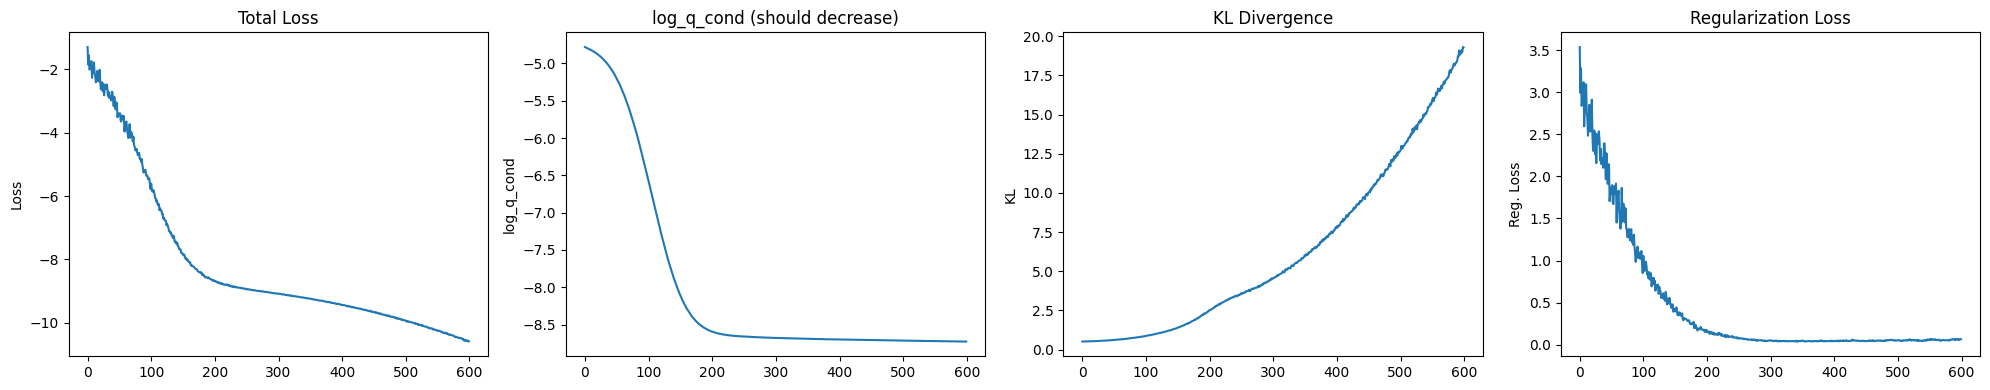

Training new model iteration 32...
Epoch 1: Loss=-1.5462, log_q=-4.4749,, reg. loss=2.9832, beta * KL=0.0545
Epoch 10: Loss=-8.5827, log_q=-8.5430,, reg. loss=0.1863, beta * KL=0.2261
Epoch 20: Loss=-9.3656, log_q=-8.6983,, reg. loss=0.0451, beta * KL=0.7124
Epoch 30: Loss=-10.3943, log_q=-8.7243,, reg. loss=0.0558, beta * KL=1.7257


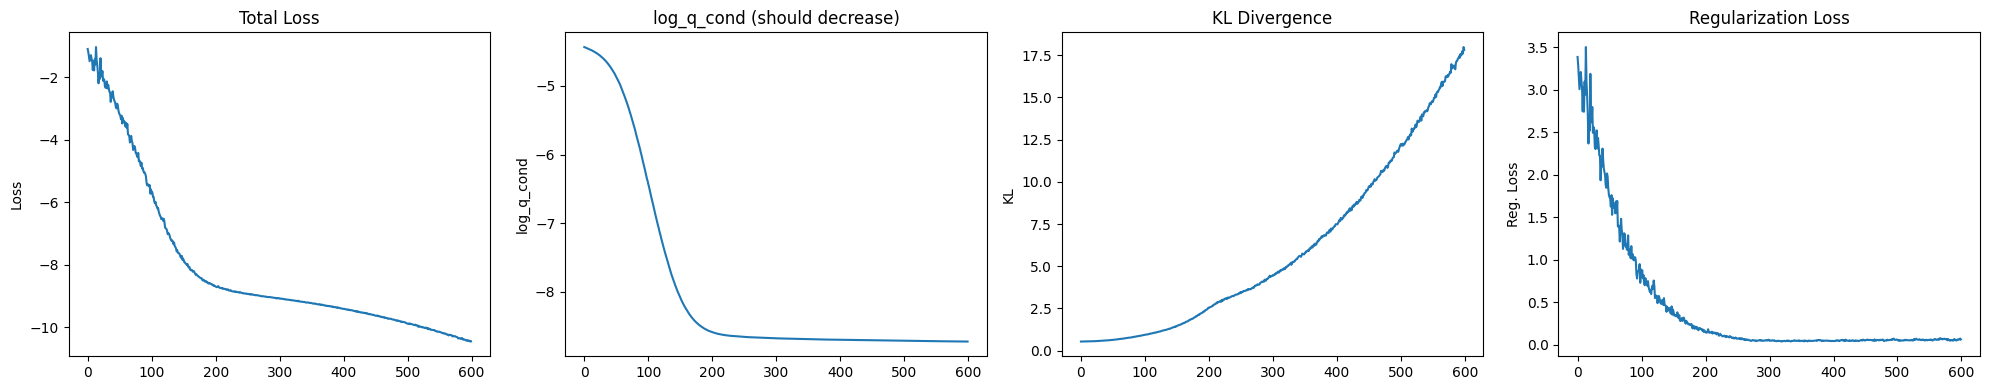

Training new model iteration 33...
Epoch 1: Loss=-0.1736, log_q=-4.9624,, reg. loss=4.8401, beta * KL=0.0513
Epoch 10: Loss=-7.9140, log_q=-8.4807,, reg. loss=0.6691, beta * KL=0.1024
Epoch 20: Loss=-9.1036, log_q=-8.7018,, reg. loss=0.0279, beta * KL=0.4297
Epoch 30: Loss=-9.7160, log_q=-8.7427,, reg. loss=0.0465, beta * KL=1.0197


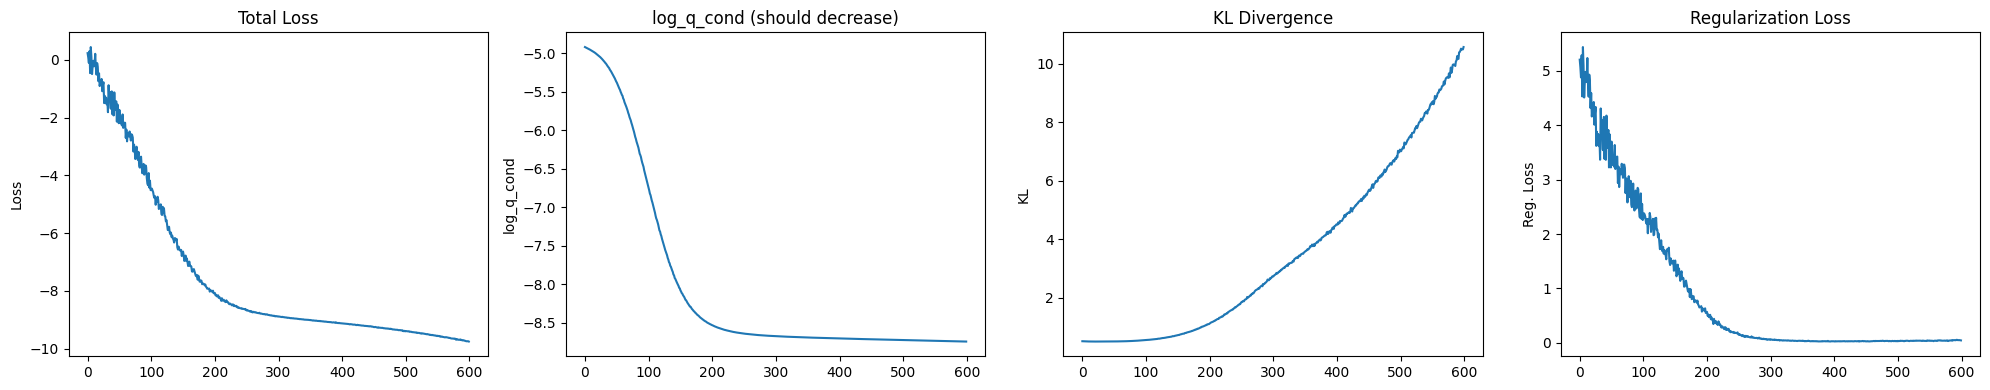

Training new model iteration 34...
Epoch 1: Loss=-2.0696, log_q=-4.6120,, reg. loss=2.5966, beta * KL=0.0541
Epoch 10: Loss=-8.4293, log_q=-8.5438,, reg. loss=0.3129, beta * KL=0.1985
Epoch 20: Loss=-9.2269, log_q=-8.6972,, reg. loss=0.0088, beta * KL=0.5385
Epoch 30: Loss=-10.1371, log_q=-8.7271,, reg. loss=0.0015, beta * KL=1.4115


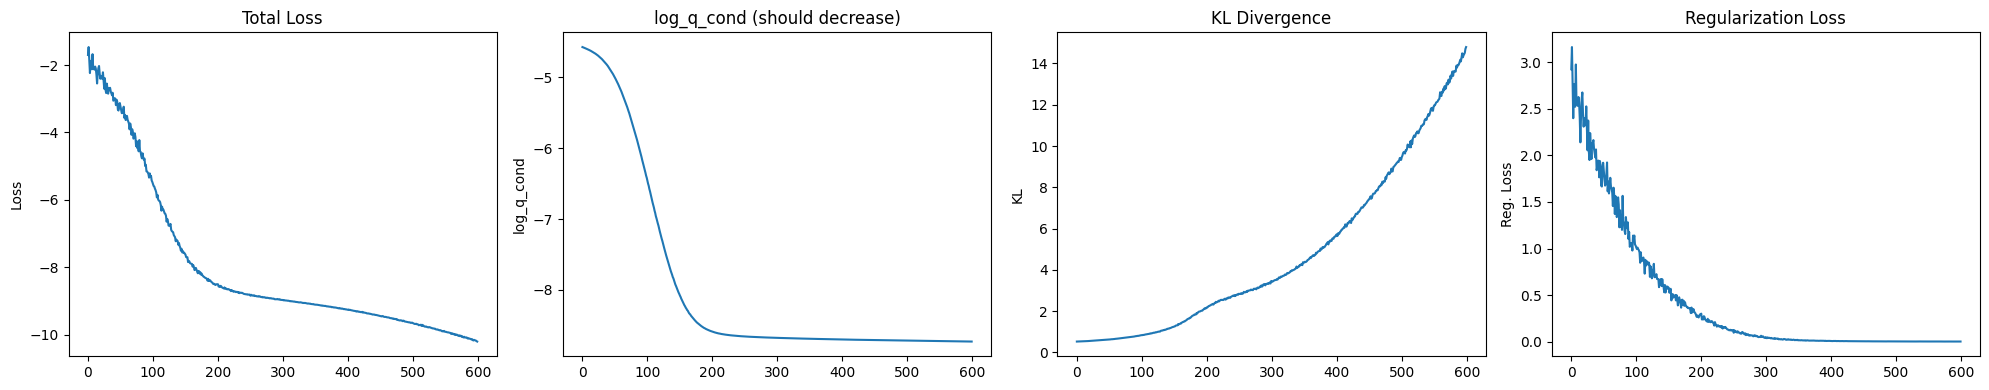

Training new model iteration 35...
Epoch 1: Loss=-0.0876, log_q=-4.8467,, reg. loss=4.8101, beta * KL=0.0510
Epoch 10: Loss=-8.1568, log_q=-8.5191,, reg. loss=0.4814, beta * KL=0.1191
Epoch 20: Loss=-9.1117, log_q=-8.7016,, reg. loss=0.0056, beta * KL=0.4156
Epoch 30: Loss=-9.7141, log_q=-8.7371,, reg. loss=0.0074, beta * KL=0.9845


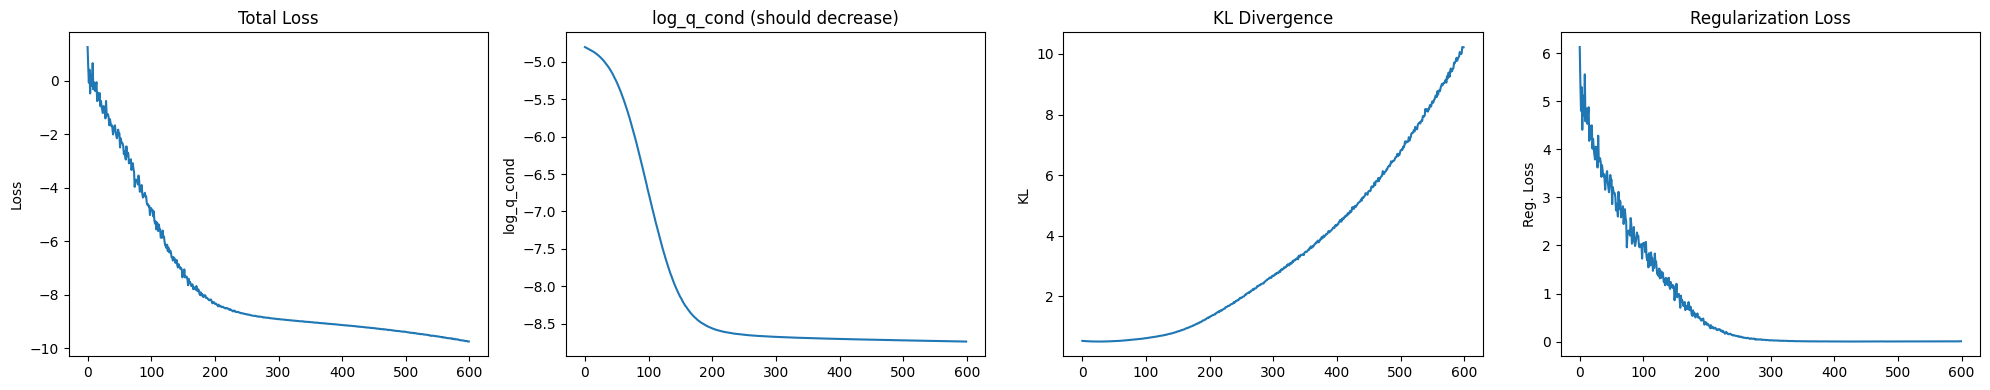

Training new model iteration 36...
Epoch 1: Loss=-1.6359, log_q=-4.7196,, reg. loss=3.1357, beta * KL=0.0520
Epoch 10: Loss=-8.4988, log_q=-8.5343,, reg. loss=0.2154, beta * KL=0.1799
Epoch 20: Loss=-9.3161, log_q=-8.7006,, reg. loss=0.0260, beta * KL=0.6415
Epoch 30: Loss=-10.2978, log_q=-8.7294,, reg. loss=0.0384, beta * KL=1.6067


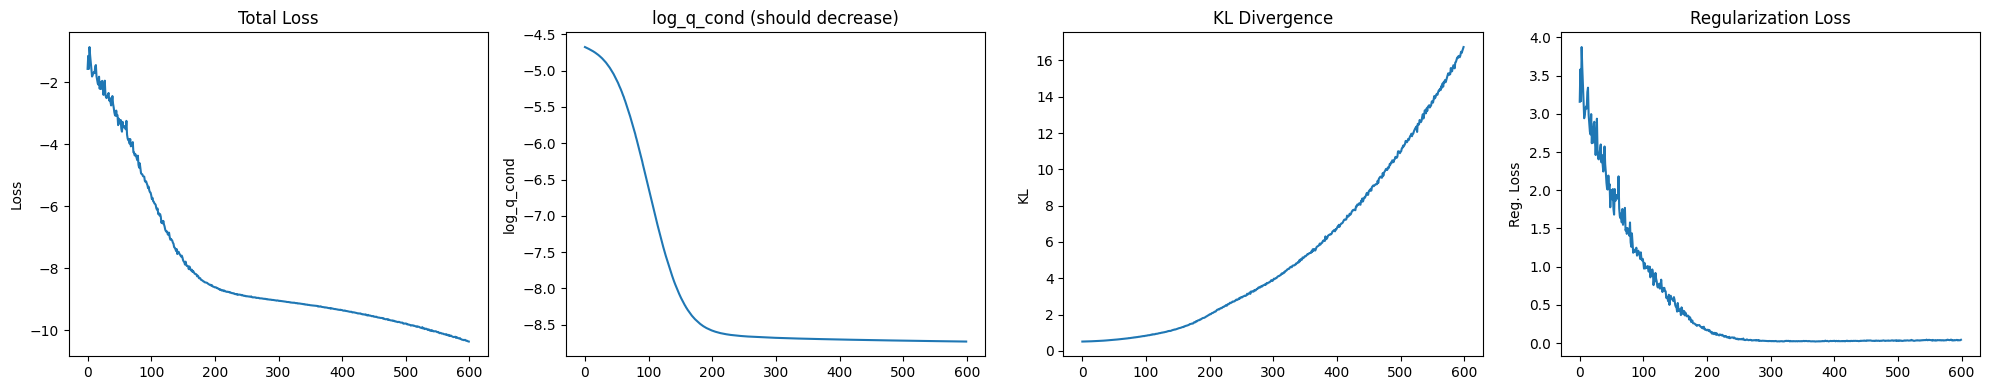

Training new model iteration 37...
Epoch 1: Loss=-1.8320, log_q=-4.5769,, reg. loss=2.7976, beta * KL=0.0526
Epoch 10: Loss=-8.2395, log_q=-8.4548,, reg. loss=0.3544, beta * KL=0.1390
Epoch 20: Loss=-9.2170, log_q=-8.6967,, reg. loss=0.0006, beta * KL=0.5209
Epoch 30: Loss=-10.1425, log_q=-8.7282,, reg. loss=0.0035, beta * KL=1.4178


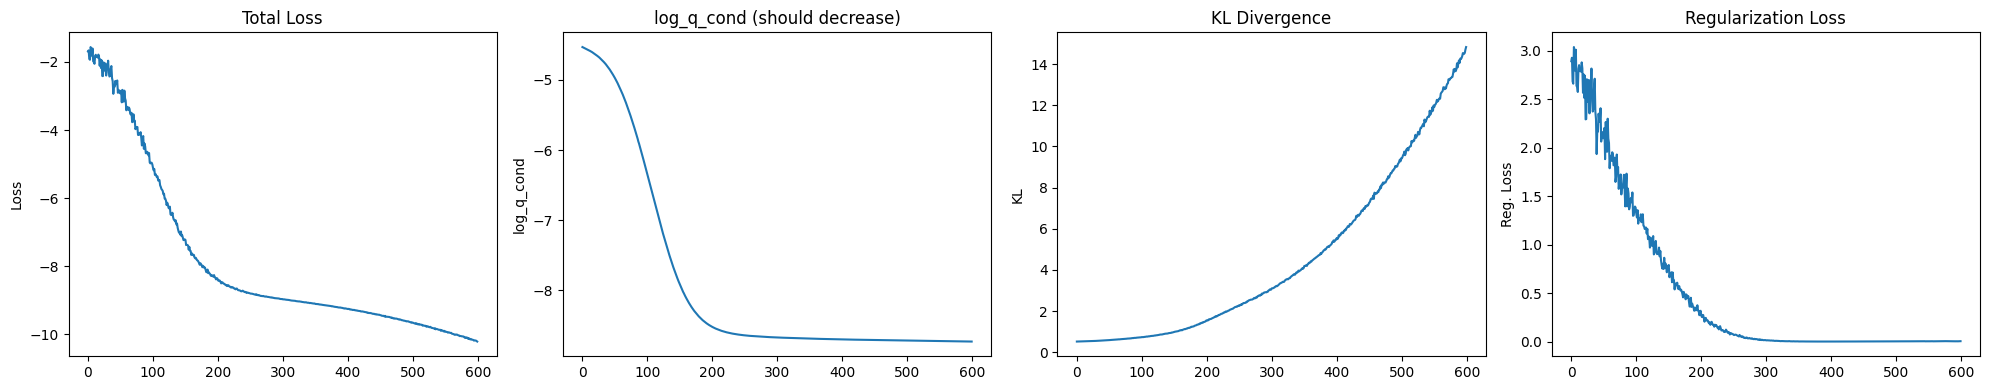

Training new model iteration 38...
Epoch 1: Loss=-2.0919, log_q=-4.6810,, reg. loss=2.6438, beta * KL=0.0546
Epoch 10: Loss=-8.4714, log_q=-8.5332,, reg. loss=0.2768, beta * KL=0.2150
Epoch 20: Loss=-9.2613, log_q=-8.6996,, reg. loss=0.0481, beta * KL=0.6098
Epoch 30: Loss=-10.1546, log_q=-8.7306,, reg. loss=0.0542, beta * KL=1.4783


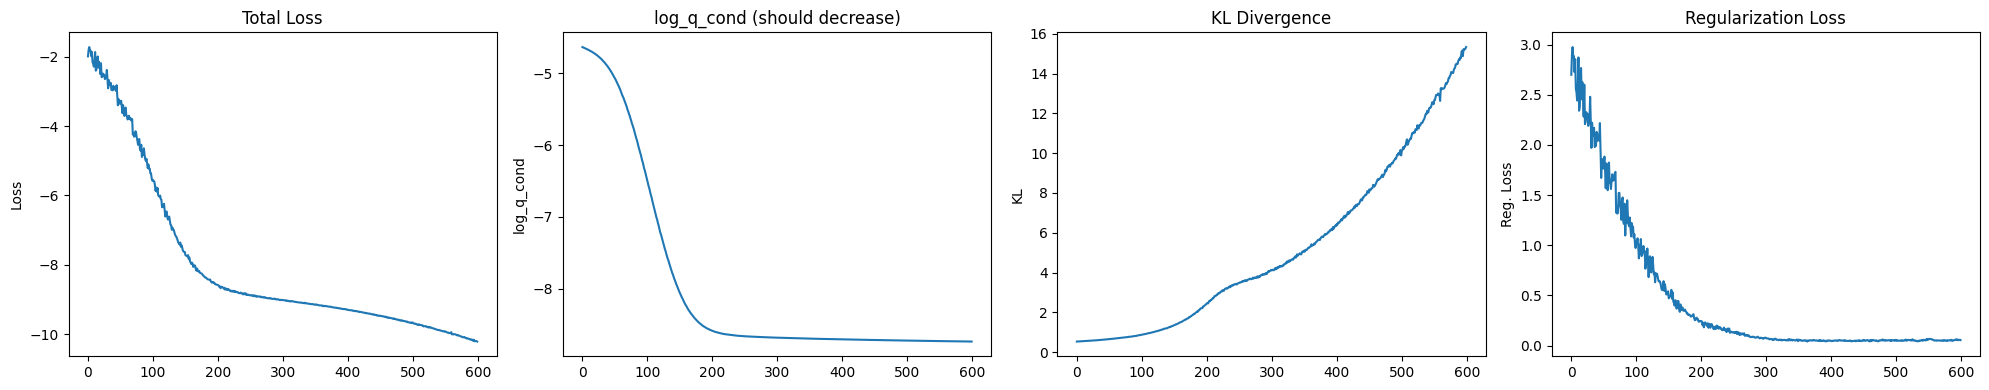

Training new model iteration 39...
Epoch 1: Loss=-0.7650, log_q=-4.7742,, reg. loss=4.0600, beta * KL=0.0507
Epoch 10: Loss=-8.1282, log_q=-8.4873,, reg. loss=0.4990, beta * KL=0.1398
Epoch 20: Loss=-9.1180, log_q=-8.7010,, reg. loss=0.0101, beta * KL=0.4272
Epoch 30: Loss=-9.7705, log_q=-8.7372,, reg. loss=0.0114, beta * KL=1.0446


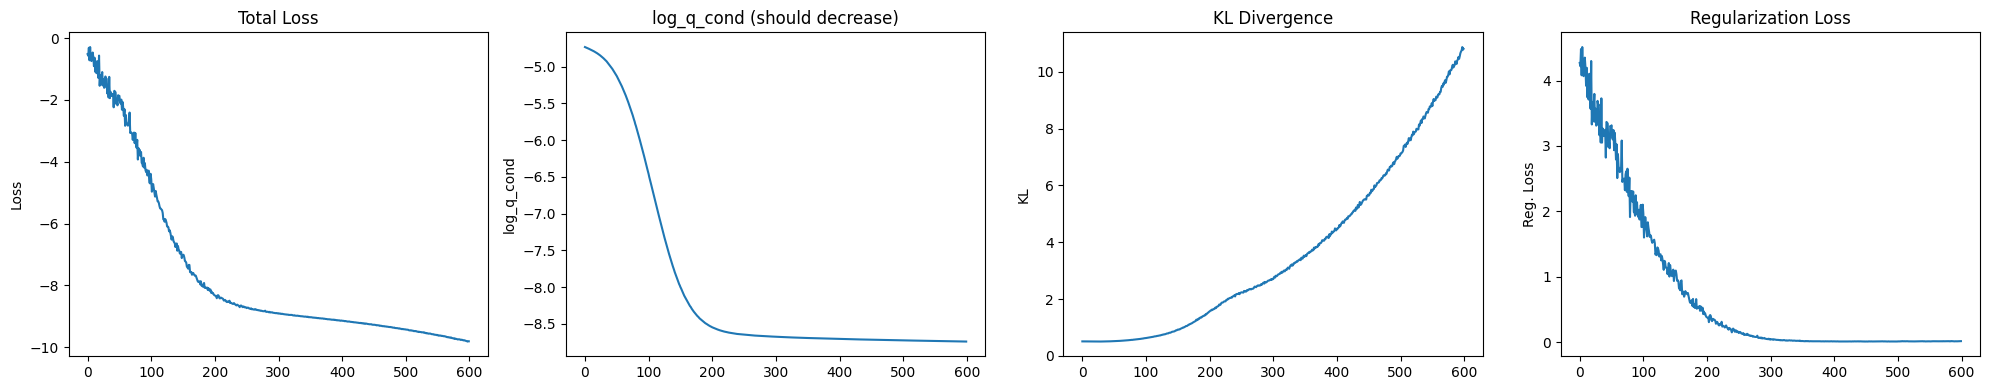

Training new model iteration 40...
Epoch 1: Loss=-0.8534, log_q=-4.6281,, reg. loss=3.8250, beta * KL=0.0503
Epoch 10: Loss=-8.0130, log_q=-8.4784,, reg. loss=0.5726, beta * KL=0.1072
Epoch 20: Loss=-9.0831, log_q=-8.7017,, reg. loss=0.0196, beta * KL=0.4010
Epoch 30: Loss=-9.6423, log_q=-8.7408,, reg. loss=0.0325, beta * KL=0.9340


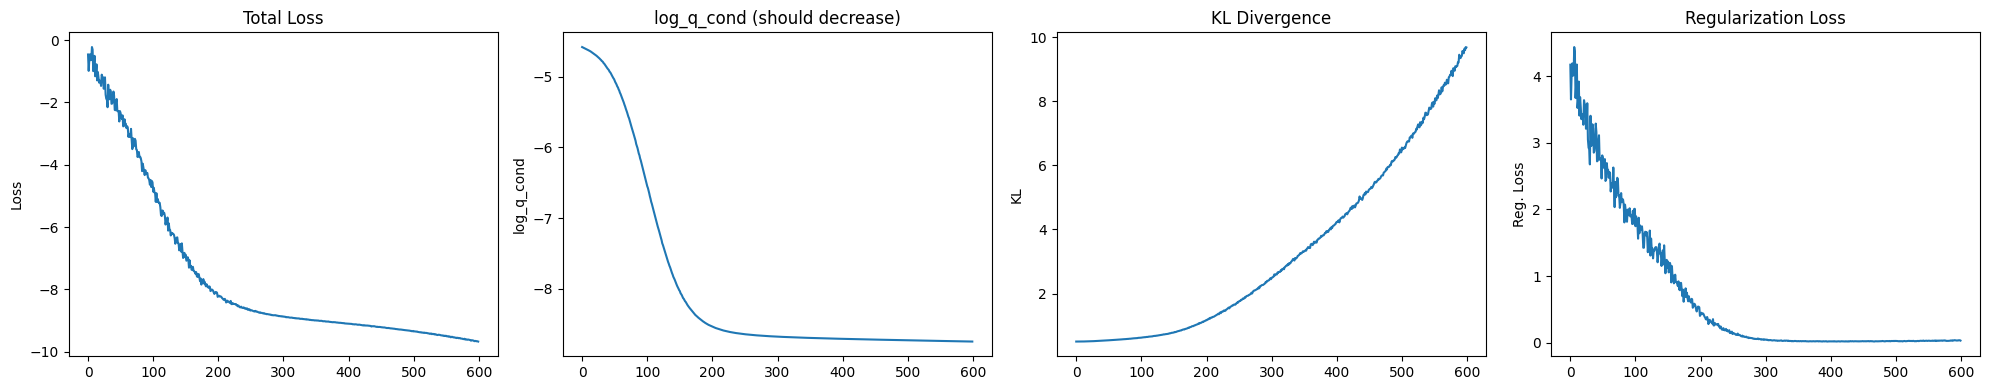

Training new model iteration 41...
Epoch 1: Loss=-0.8935, log_q=-4.6322,, reg. loss=3.7893, beta * KL=0.0506
Epoch 10: Loss=-8.3687, log_q=-8.5224,, reg. loss=0.3090, beta * KL=0.1553
Epoch 20: Loss=-9.2203, log_q=-8.7037,, reg. loss=0.0134, beta * KL=0.5300
Epoch 30: Loss=-10.0198, log_q=-8.7361,, reg. loss=0.0196, beta * KL=1.3033


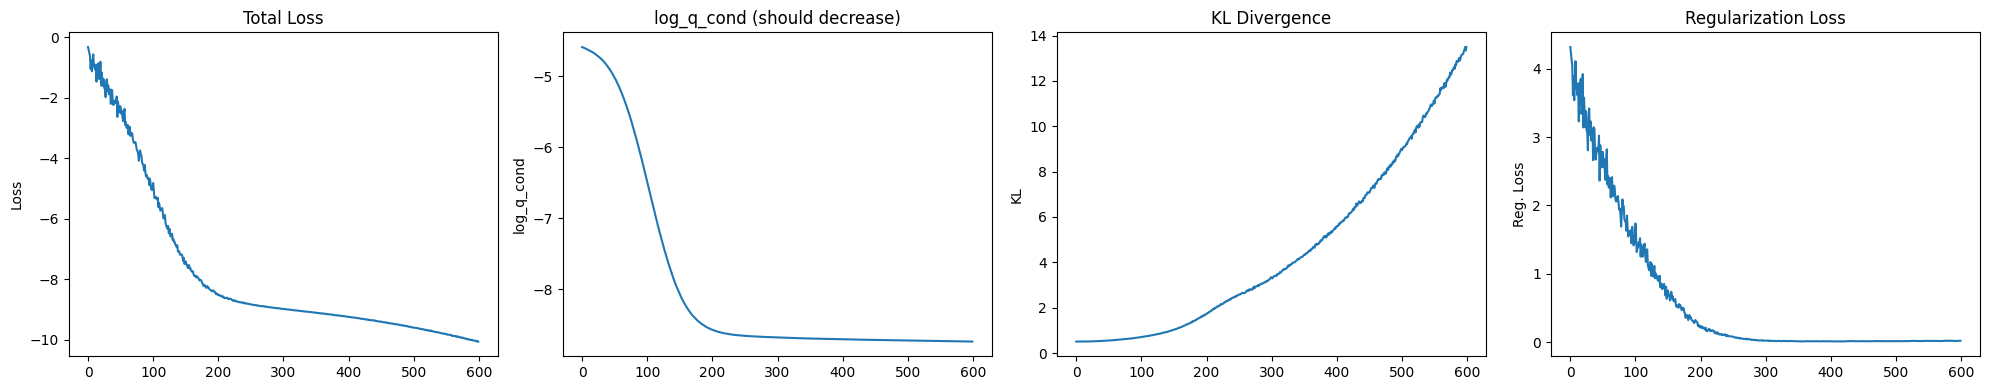

Training new model iteration 42...
Epoch 1: Loss=-1.0058, log_q=-4.7762,, reg. loss=3.8224, beta * KL=0.0520
Epoch 10: Loss=-8.3805, log_q=-8.5018,, reg. loss=0.2686, beta * KL=0.1473
Epoch 20: Loss=-9.2125, log_q=-8.7010,, reg. loss=0.0197, beta * KL=0.5312
Epoch 30: Loss=-9.9863, log_q=-8.7320,, reg. loss=0.0243, beta * KL=1.2785


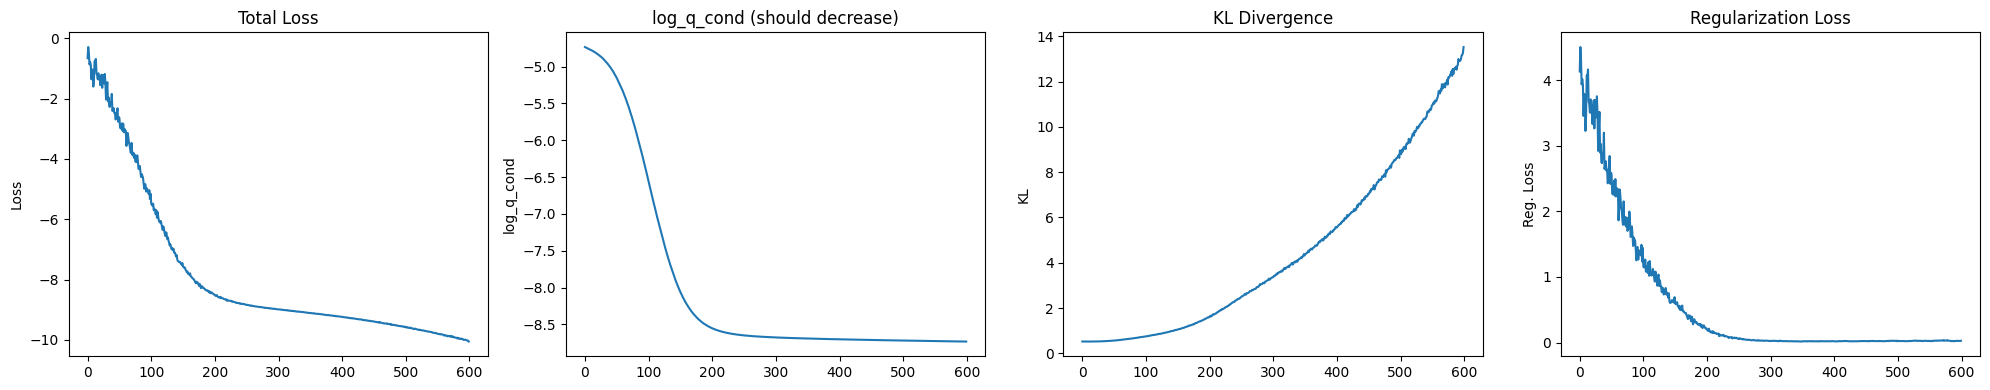

Training new model iteration 43...
Epoch 1: Loss=-1.7009, log_q=-4.7591,, reg. loss=3.1098, beta * KL=0.0516
Epoch 10: Loss=-8.4460, log_q=-8.5784,, reg. loss=0.4054, beta * KL=0.2730
Epoch 20: Loss=-9.2290, log_q=-8.7019,, reg. loss=0.0314, beta * KL=0.5585
Epoch 30: Loss=-10.0996, log_q=-8.7341,, reg. loss=0.0225, beta * KL=1.3879


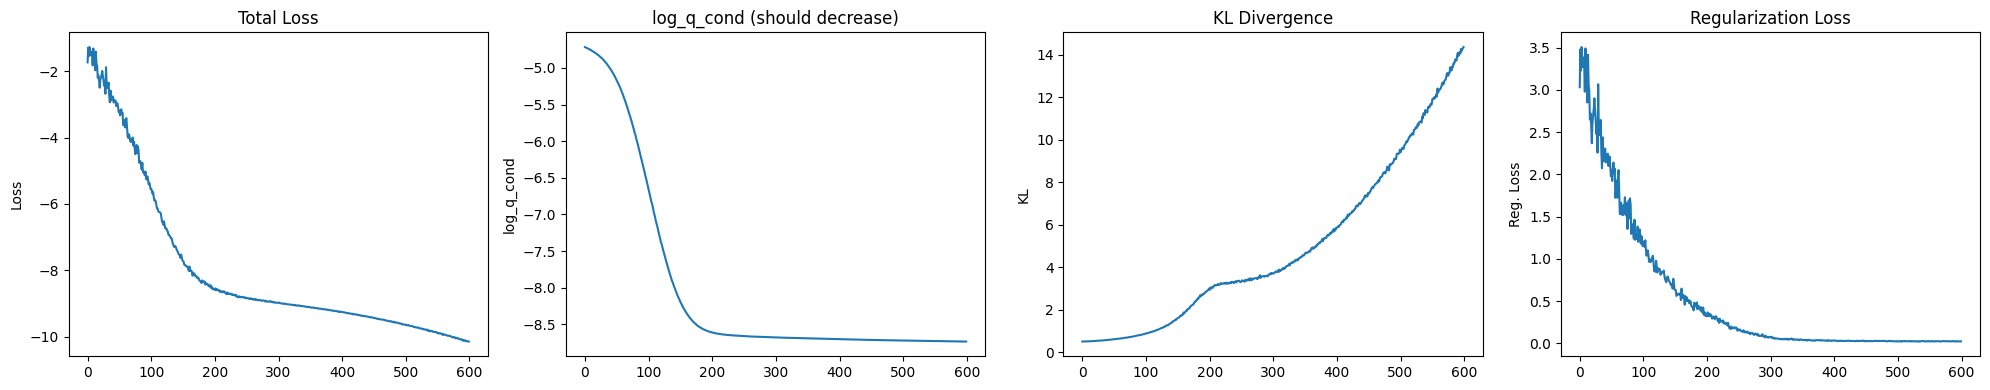

Training new model iteration 44...
Epoch 1: Loss=-1.0808, log_q=-4.6258,, reg. loss=3.6000, beta * KL=0.0549
Epoch 10: Loss=-8.4947, log_q=-8.6023,, reg. loss=0.4743, beta * KL=0.3666
Epoch 20: Loss=-9.1793, log_q=-8.6986,, reg. loss=0.0841, beta * KL=0.5648
Epoch 30: Loss=-9.9062, log_q=-8.7315,, reg. loss=0.0865, beta * KL=1.2613


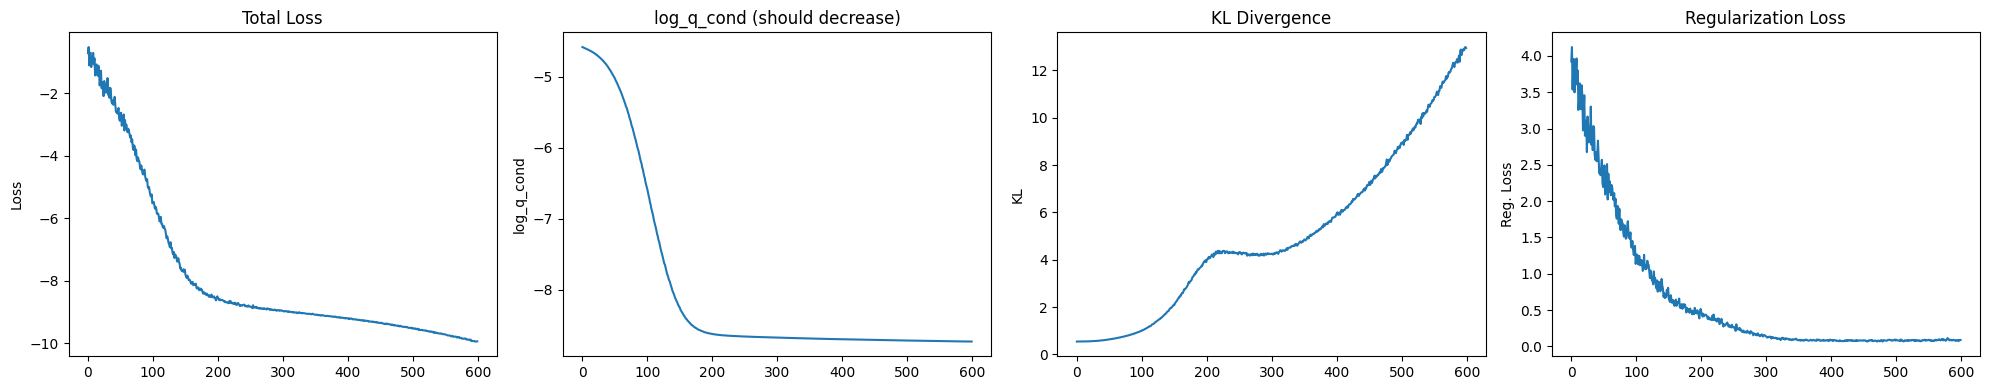

Training new model iteration 45...
Epoch 1: Loss=-1.6097, log_q=-4.4445,, reg. loss=2.8879, beta * KL=0.0530
Epoch 10: Loss=-8.3383, log_q=-8.4770,, reg. loss=0.3101, beta * KL=0.1714
Epoch 20: Loss=-9.2694, log_q=-8.6960,, reg. loss=0.0234, beta * KL=0.5967
Epoch 30: Loss=-10.2116, log_q=-8.7250,, reg. loss=0.0229, beta * KL=1.5095


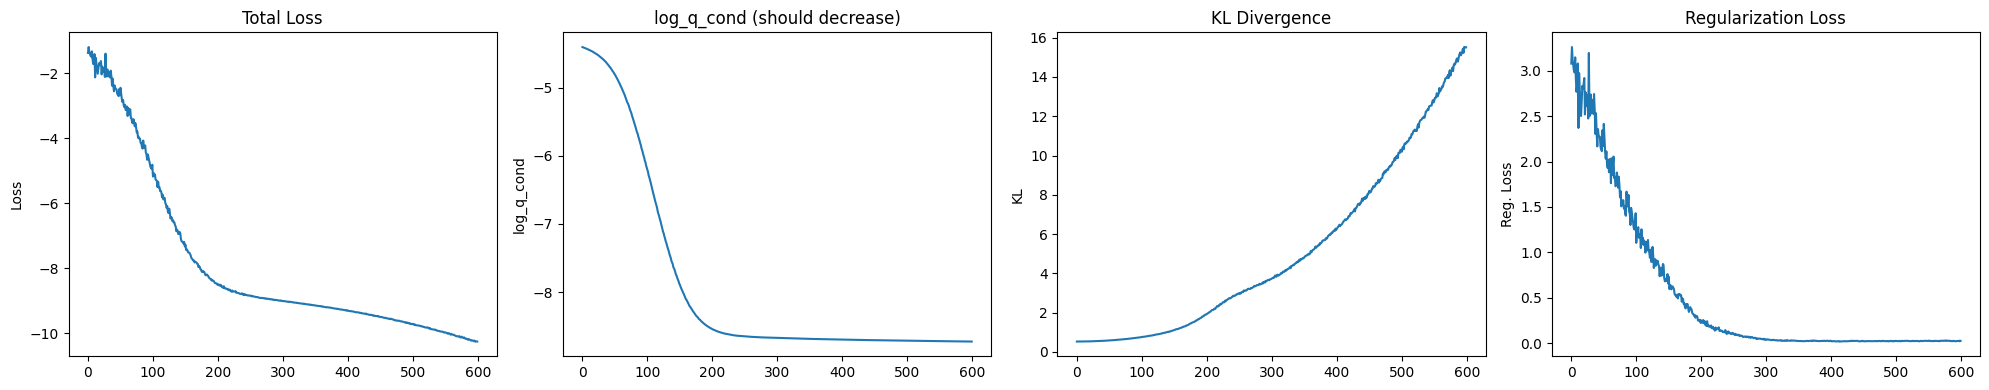

Training new model iteration 46...
Epoch 1: Loss=-0.3037, log_q=-4.6433,, reg. loss=4.3923, beta * KL=0.0527
Epoch 10: Loss=-8.3875, log_q=-8.5422,, reg. loss=0.3180, beta * KL=0.1634
Epoch 20: Loss=-9.2102, log_q=-8.7017,, reg. loss=0.0336, beta * KL=0.5422
Epoch 30: Loss=-10.0062, log_q=-8.7349,, reg. loss=0.0572, beta * KL=1.3285


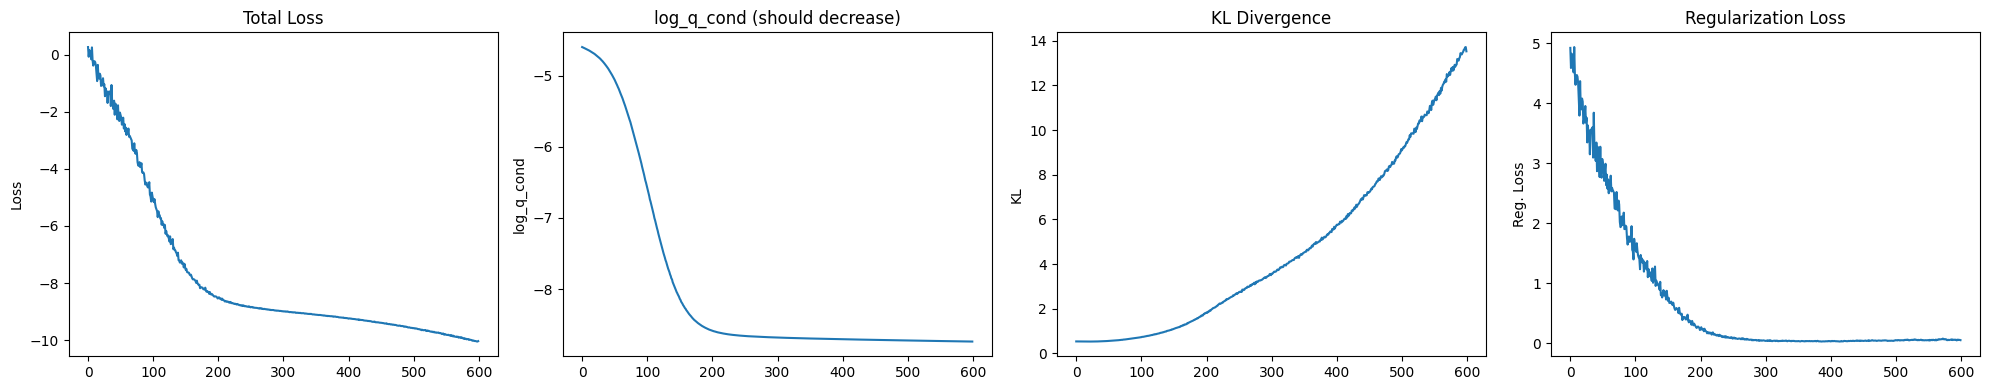

Training new model iteration 47...
Epoch 1: Loss=-1.5789, log_q=-5.0977,, reg. loss=3.5711, beta * KL=0.0523
Epoch 10: Loss=-8.4653, log_q=-8.6026,, reg. loss=0.4689, beta * KL=0.3315
Epoch 20: Loss=-9.2151, log_q=-8.6973,, reg. loss=0.0327, beta * KL=0.5505
Epoch 30: Loss=-10.0761, log_q=-8.7279,, reg. loss=0.0195, beta * KL=1.3677


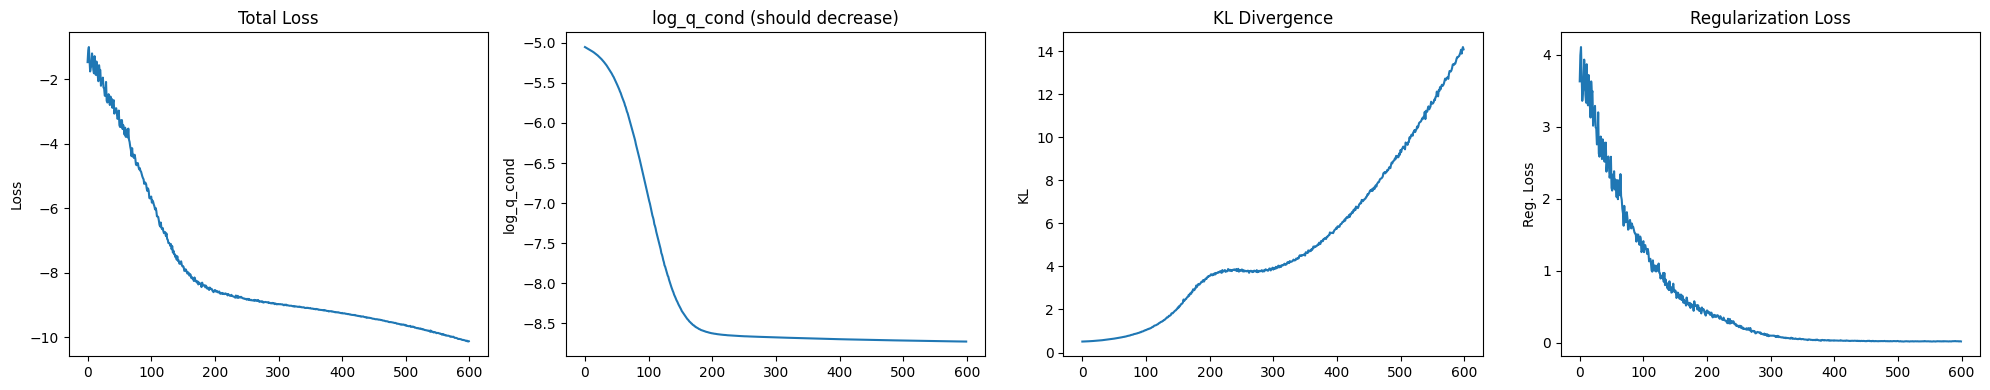

Training new model iteration 48...
Epoch 1: Loss=-0.7164, log_q=-4.3312,, reg. loss=3.6666, beta * KL=0.0517
Epoch 10: Loss=-8.1304, log_q=-8.4860,, reg. loss=0.4718, beta * KL=0.1162
Epoch 20: Loss=-9.1353, log_q=-8.6997,, reg. loss=0.0255, beta * KL=0.4611
Epoch 30: Loss=-9.7956, log_q=-8.7359,, reg. loss=0.0466, beta * KL=1.1062


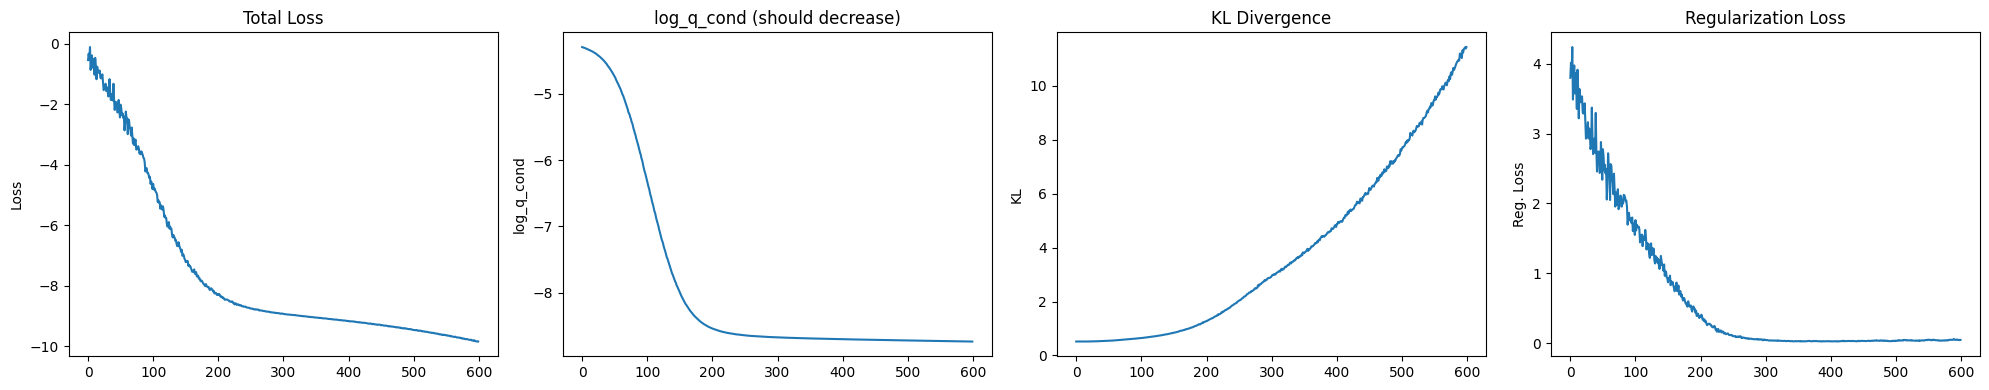

Training new model iteration 49...
Epoch 1: Loss=-0.4808, log_q=-4.7088,, reg. loss=4.2793, beta * KL=0.0513
Epoch 10: Loss=-8.2196, log_q=-8.4842,, reg. loss=0.4162, beta * KL=0.1516
Epoch 20: Loss=-9.1637, log_q=-8.6987,, reg. loss=0.0352, beta * KL=0.5002
Epoch 30: Loss=-9.8956, log_q=-8.7309,, reg. loss=0.0479, beta * KL=1.2127


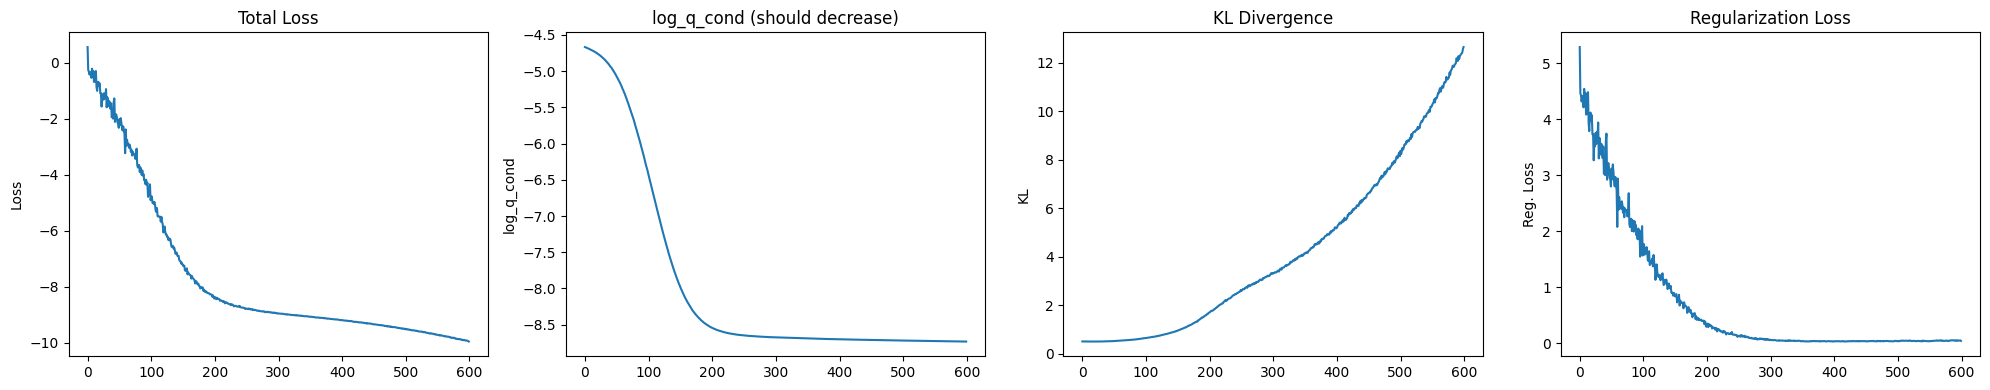

Training new model iteration 50...
Epoch 1: Loss=-0.6999, log_q=-4.4829,, reg. loss=3.8345, beta * KL=0.0515
Epoch 10: Loss=-8.1648, log_q=-8.4751,, reg. loss=0.4287, beta * KL=0.1185
Epoch 20: Loss=-9.1431, log_q=-8.7012,, reg. loss=0.0183, beta * KL=0.4602
Epoch 30: Loss=-9.8405, log_q=-8.7371,, reg. loss=0.0324, beta * KL=1.1358


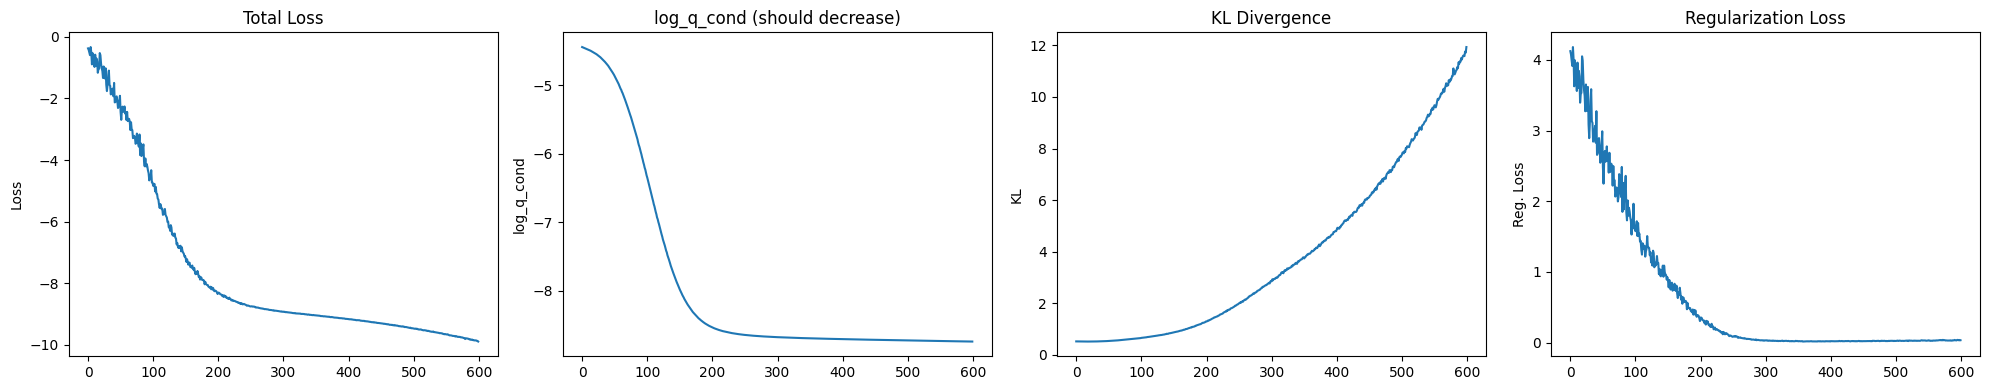

Training new model iteration 51...
Epoch 1: Loss=-1.2764, log_q=-4.9777,, reg. loss=3.7517, beta * KL=0.0504
Epoch 10: Loss=-8.2202, log_q=-8.5477,, reg. loss=0.5032, beta * KL=0.1757
Epoch 20: Loss=-9.1085, log_q=-8.6998,, reg. loss=0.0232, beta * KL=0.4318
Epoch 30: Loss=-9.7662, log_q=-8.7345,, reg. loss=0.0142, beta * KL=1.0458


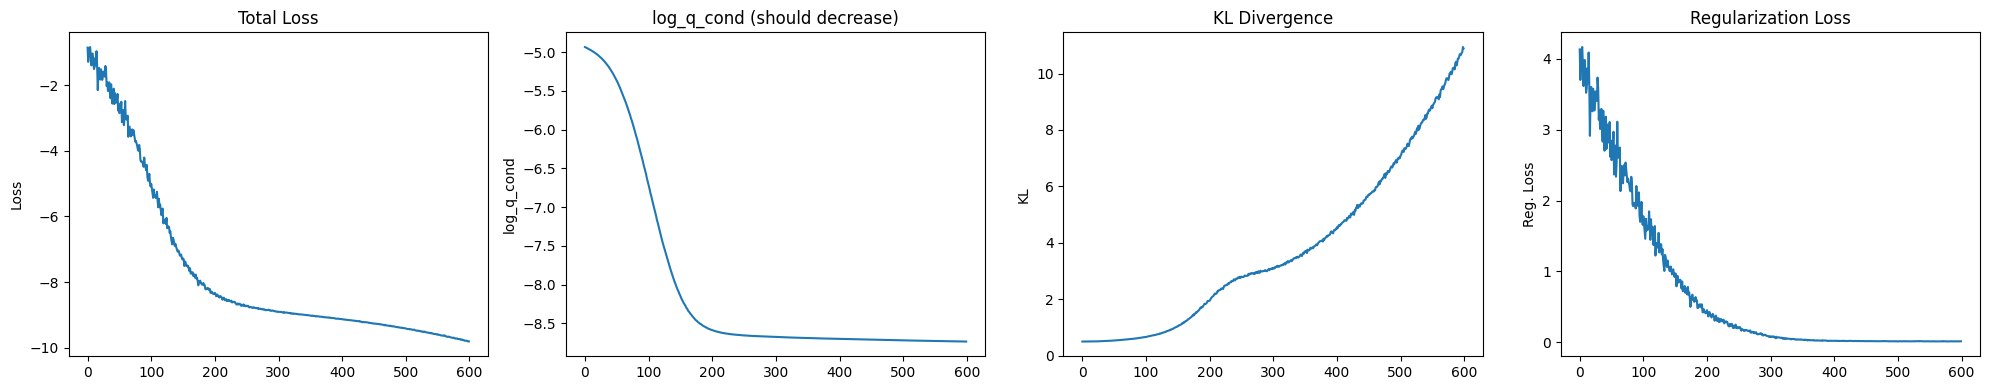

Training new model iteration 52...
Epoch 1: Loss=0.1681, log_q=-4.4604,, reg. loss=4.6800, beta * KL=0.0515
Epoch 10: Loss=-8.1305, log_q=-8.5143,, reg. loss=0.5077, beta * KL=0.1239
Epoch 20: Loss=-9.1500, log_q=-8.7052,, reg. loss=0.0234, beta * KL=0.4683
Epoch 30: Loss=-9.8867, log_q=-8.7517,, reg. loss=0.0521, beta * KL=1.1871


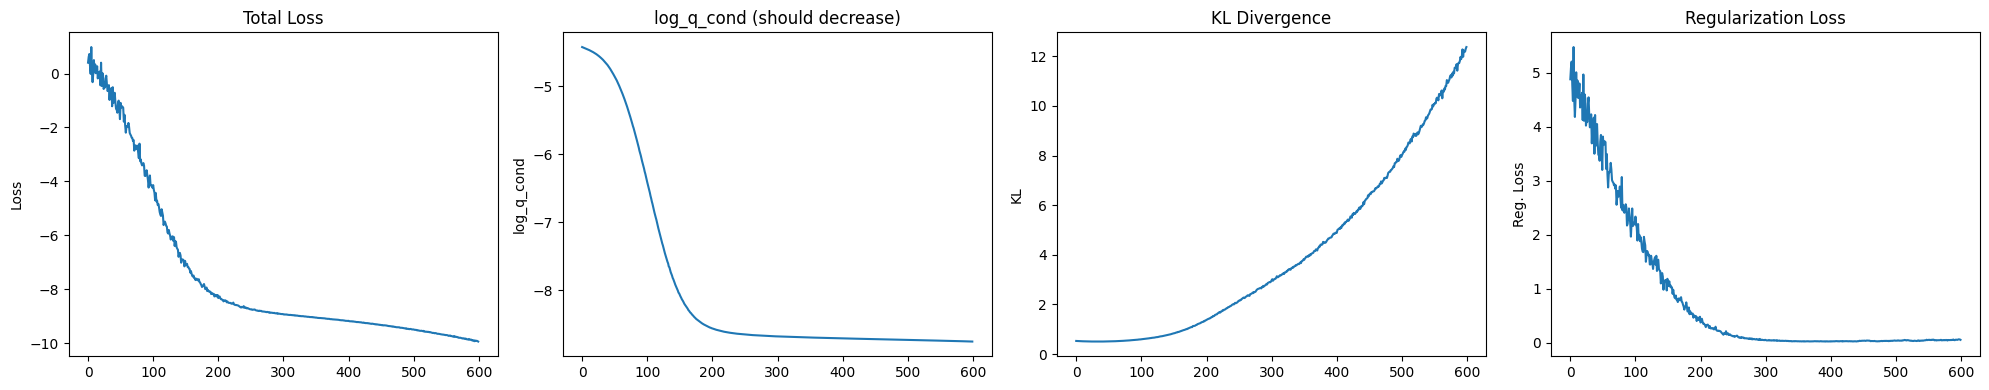

Training new model iteration 53...
Epoch 1: Loss=-1.1452, log_q=-4.5125,, reg. loss=3.4181, beta * KL=0.0508
Epoch 10: Loss=-8.5085, log_q=-8.5531,, reg. loss=0.3007, beta * KL=0.2562
Epoch 20: Loss=-9.2475, log_q=-8.6998,, reg. loss=0.0770, beta * KL=0.6247
Epoch 30: Loss=-10.1336, log_q=-8.7310,, reg. loss=0.0699, beta * KL=1.4725


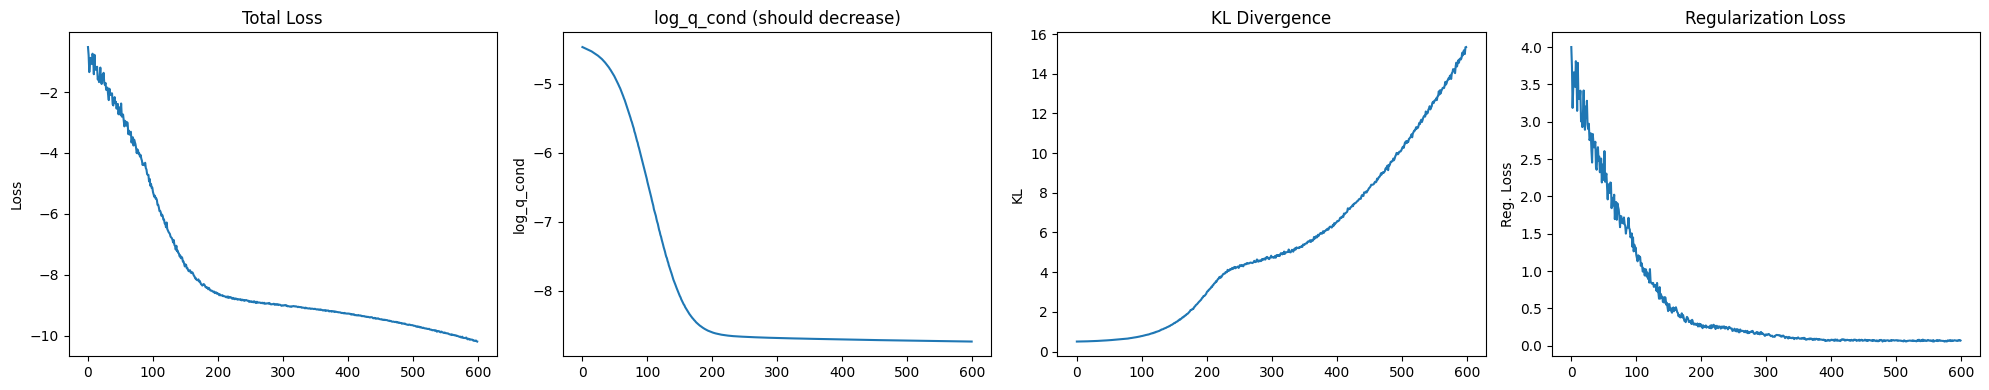

Training new model iteration 54...
Epoch 1: Loss=-0.2789, log_q=-4.4804,, reg. loss=4.2519, beta * KL=0.0505
Epoch 10: Loss=-8.3542, log_q=-8.5624,, reg. loss=0.4360, beta * KL=0.2278
Epoch 20: Loss=-9.1002, log_q=-8.6956,, reg. loss=0.0402, beta * KL=0.4448
Epoch 30: Loss=-9.7456, log_q=-8.7262,, reg. loss=0.0121, beta * KL=1.0315


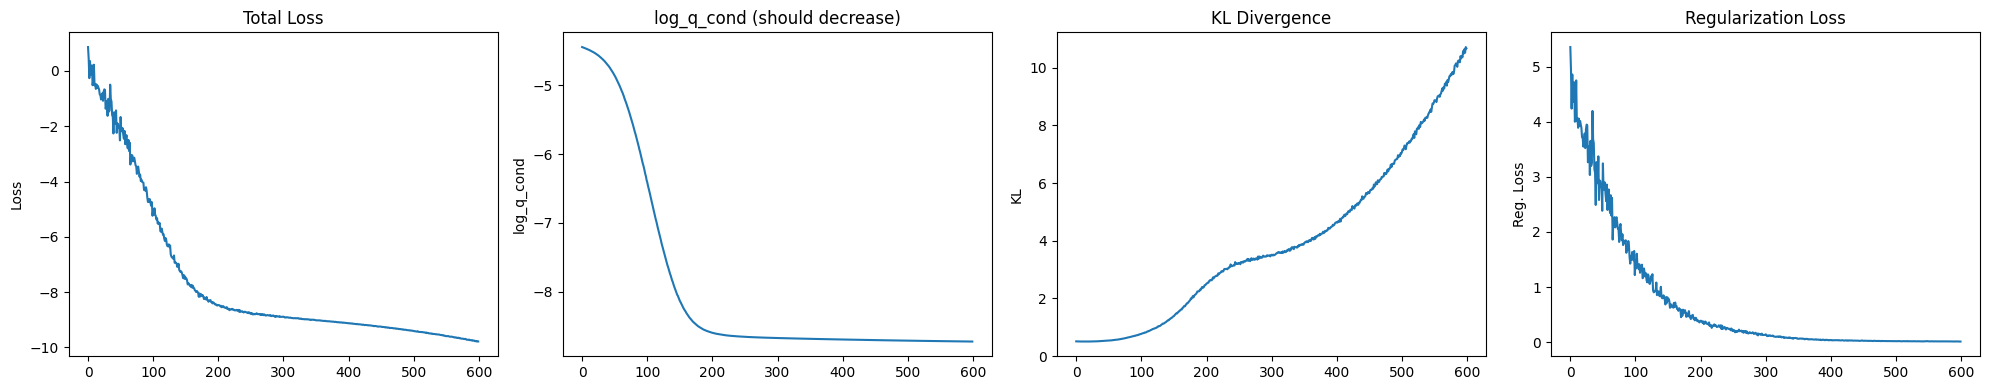

Training new model iteration 55...
Epoch 1: Loss=-1.4596, log_q=-4.7248,, reg. loss=3.3166, beta * KL=0.0515
Epoch 10: Loss=-8.1688, log_q=-8.5367,, reg. loss=0.5811, beta * KL=0.2131
Epoch 20: Loss=-9.0377, log_q=-8.6966,, reg. loss=0.0531, beta * KL=0.3942
Epoch 30: Loss=-9.5694, log_q=-8.7321,, reg. loss=0.0244, beta * KL=0.8616


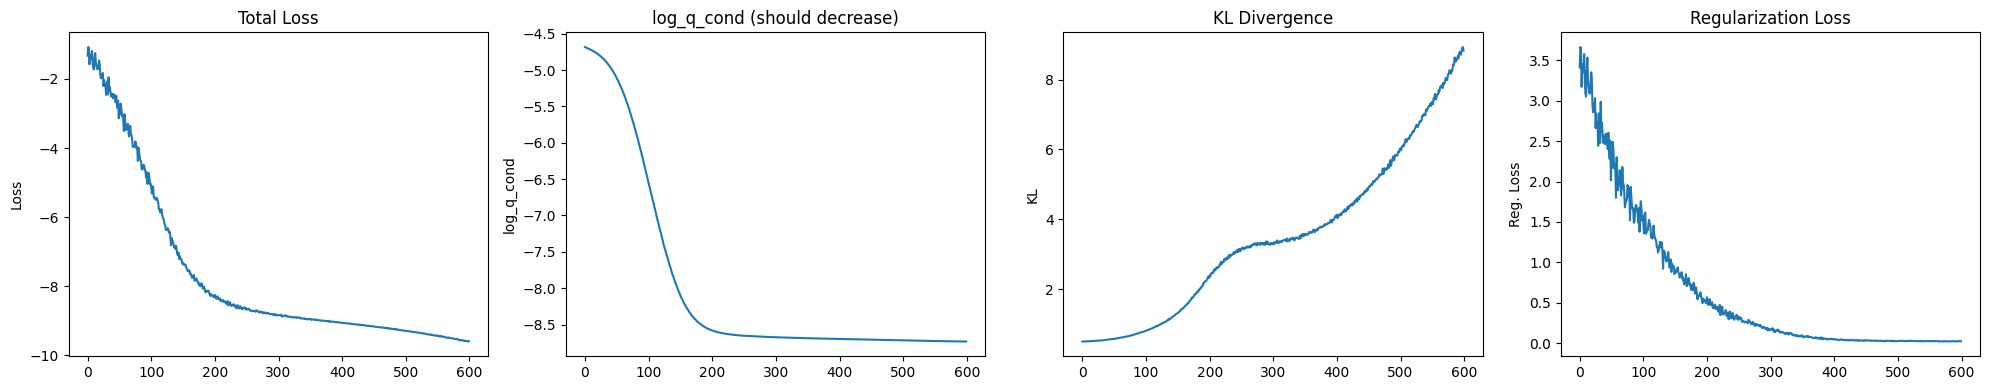

Training new model iteration 56...
Epoch 1: Loss=-1.1523, log_q=-4.4815,, reg. loss=3.3810, beta * KL=0.0518
Epoch 10: Loss=-8.5779, log_q=-8.5930,, reg. loss=0.2911, beta * KL=0.2760
Epoch 20: Loss=-9.3084, log_q=-8.6968,, reg. loss=0.0468, beta * KL=0.6585
Epoch 30: Loss=-10.2802, log_q=-8.7244,, reg. loss=0.0418, beta * KL=1.5976


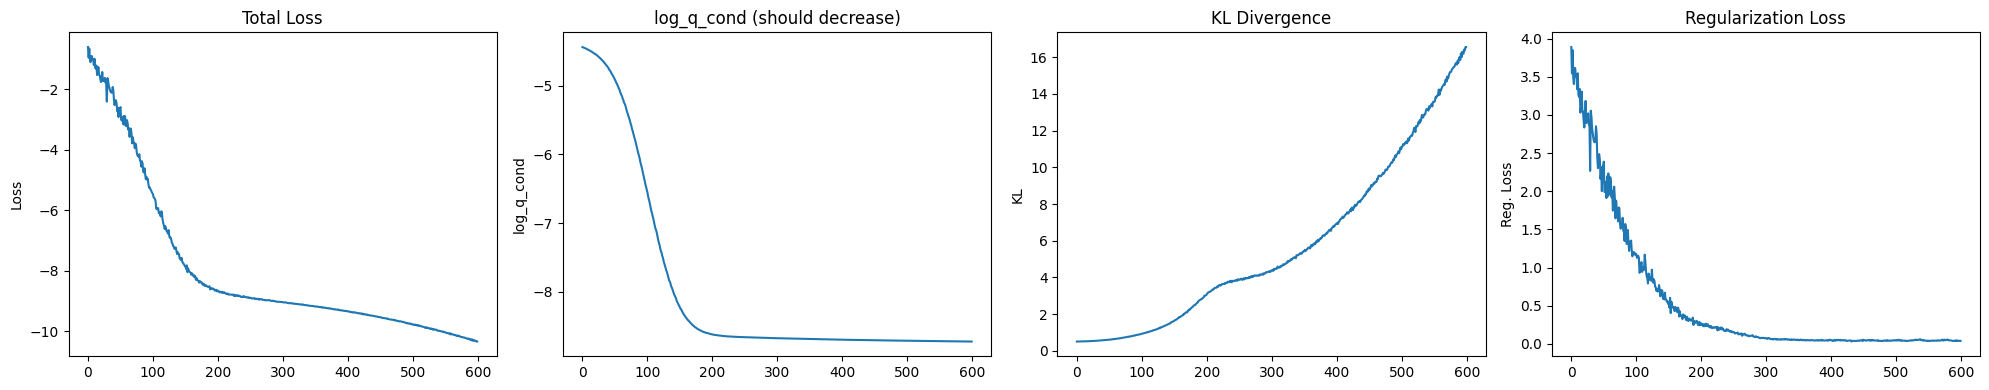

Training new model iteration 57...
Epoch 1: Loss=-1.1293, log_q=-4.8672,, reg. loss=3.7888, beta * KL=0.0509
Epoch 10: Loss=-8.2045, log_q=-8.4932,, reg. loss=0.4128, beta * KL=0.1242
Epoch 20: Loss=-9.1616, log_q=-8.6994,, reg. loss=0.0232, beta * KL=0.4855
Epoch 30: Loss=-9.8842, log_q=-8.7323,, reg. loss=0.0353, beta * KL=1.1872


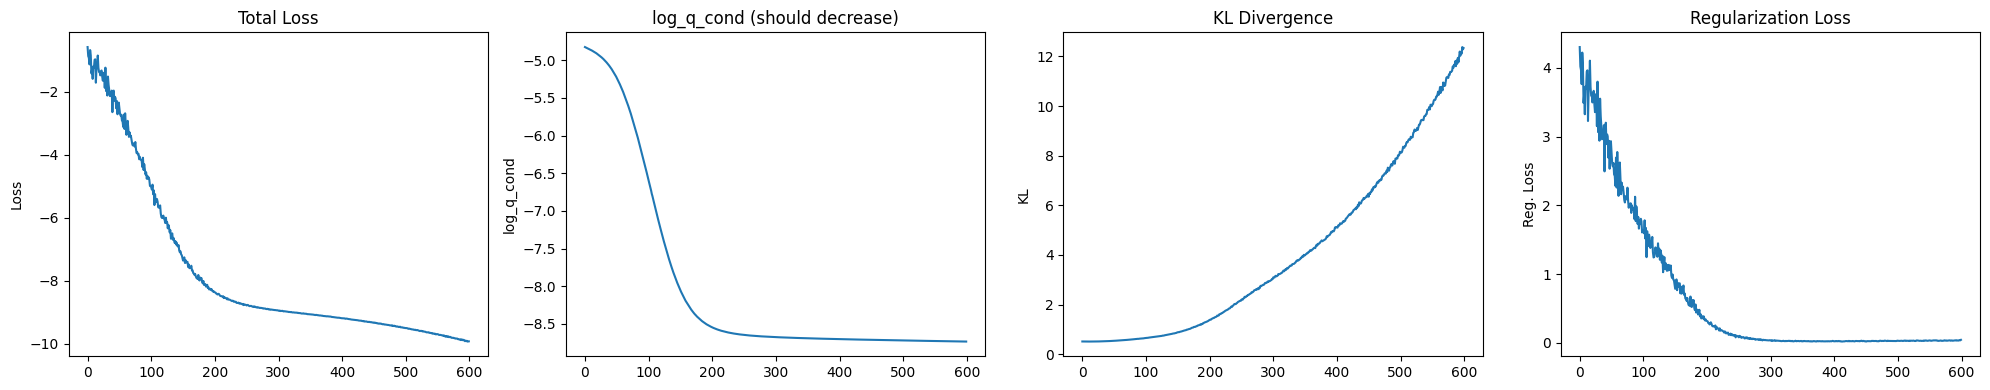

Training new model iteration 58...
Epoch 1: Loss=-1.6984, log_q=-4.5414,, reg. loss=2.8972, beta * KL=0.0541
Epoch 10: Loss=-8.3742, log_q=-8.5092,, reg. loss=0.2858, beta * KL=0.1508
Epoch 20: Loss=-9.2391, log_q=-8.6981,, reg. loss=0.0167, beta * KL=0.5578
Epoch 30: Loss=-10.1237, log_q=-8.7292,, reg. loss=0.0230, beta * KL=1.4176


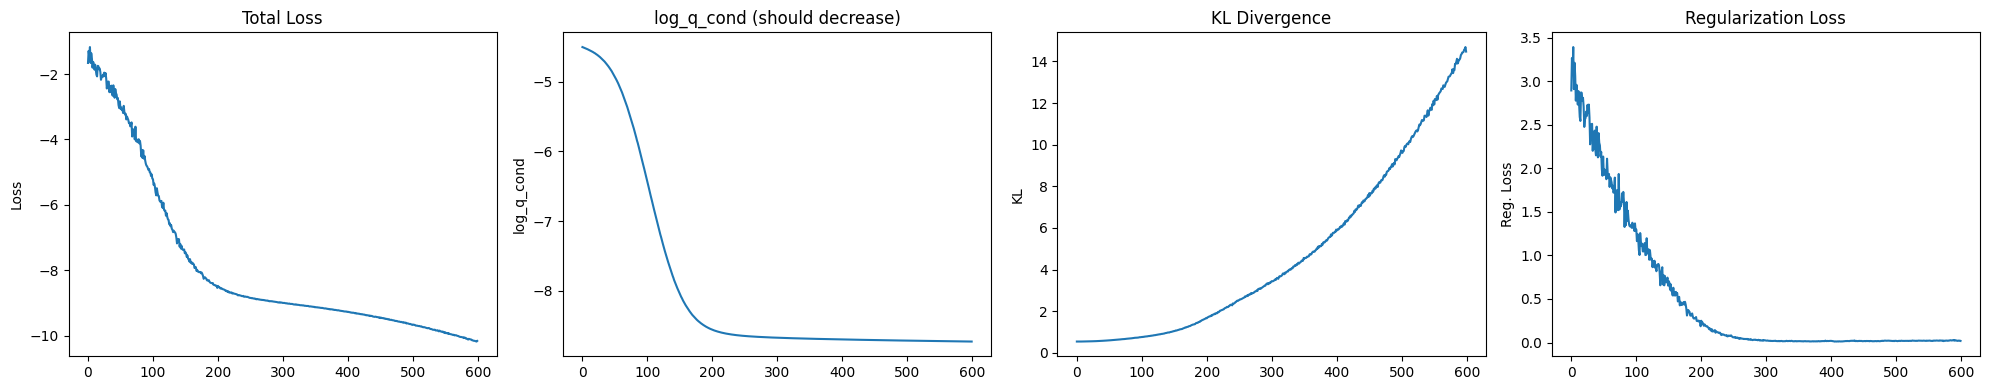

Training new model iteration 59...
Epoch 1: Loss=-1.2061, log_q=-4.6636,, reg. loss=3.5089, beta * KL=0.0514
Epoch 10: Loss=-8.5565, log_q=-8.5796,, reg. loss=0.2545, beta * KL=0.2314
Epoch 20: Loss=-9.3504, log_q=-8.7030,, reg. loss=0.0289, beta * KL=0.6763
Epoch 30: Loss=-10.3863, log_q=-8.7333,, reg. loss=0.0429, beta * KL=1.6959


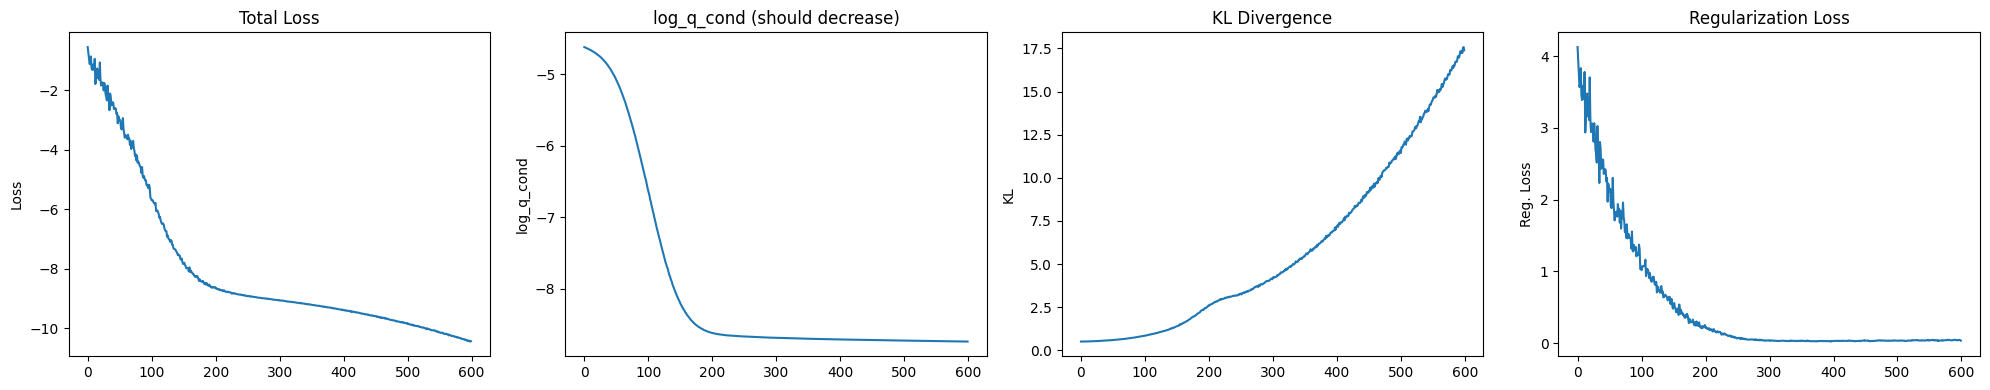

Training new model iteration 60...
Epoch 1: Loss=-1.5708, log_q=-4.6857,, reg. loss=3.1664, beta * KL=0.0515
Epoch 10: Loss=-8.3144, log_q=-8.4886,, reg. loss=0.3126, beta * KL=0.1384
Epoch 20: Loss=-9.1975, log_q=-8.6978,, reg. loss=0.0139, beta * KL=0.5135
Epoch 30: Loss=-9.9733, log_q=-8.7280,, reg. loss=0.0172, beta * KL=1.2624


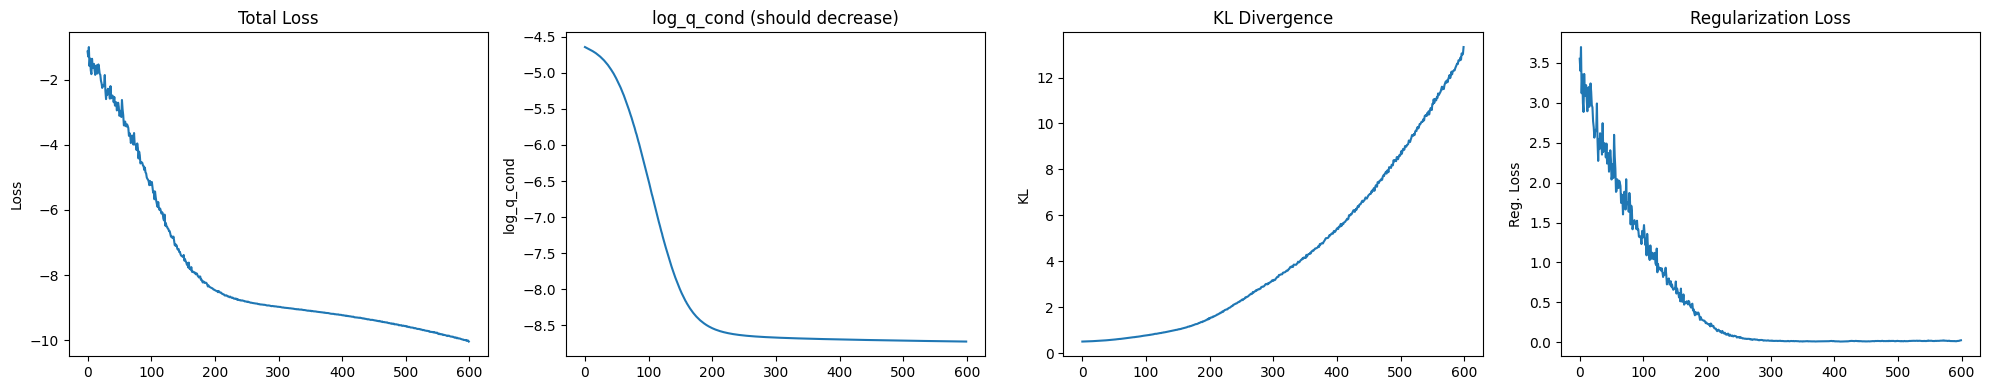

Training new model iteration 61...
Epoch 1: Loss=-0.4573, log_q=-4.4673,, reg. loss=4.0632, beta * KL=0.0531
Epoch 10: Loss=-7.9461, log_q=-8.4845,, reg. loss=0.6998, beta * KL=0.1614
Epoch 20: Loss=-9.0422, log_q=-8.6965,, reg. loss=0.0723, beta * KL=0.4180
Epoch 30: Loss=-9.5513, log_q=-8.7329,, reg. loss=0.0565, beta * KL=0.8749


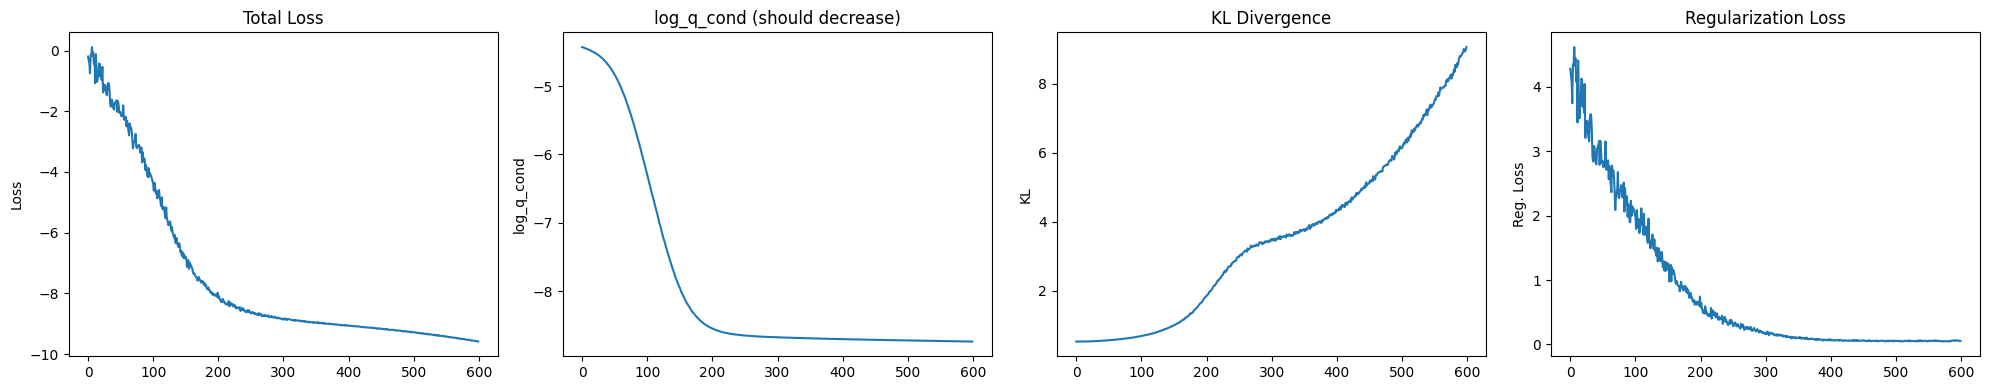

Training new model iteration 62...
Epoch 1: Loss=-1.1955, log_q=-4.6866,, reg. loss=3.5421, beta * KL=0.0510
Epoch 10: Loss=-8.3494, log_q=-8.5283,, reg. loss=0.3497, beta * KL=0.1708
Epoch 20: Loss=-9.1939, log_q=-8.6973,, reg. loss=0.0120, beta * KL=0.5086
Epoch 30: Loss=-9.9710, log_q=-8.7272,, reg. loss=0.0095, beta * KL=1.2533


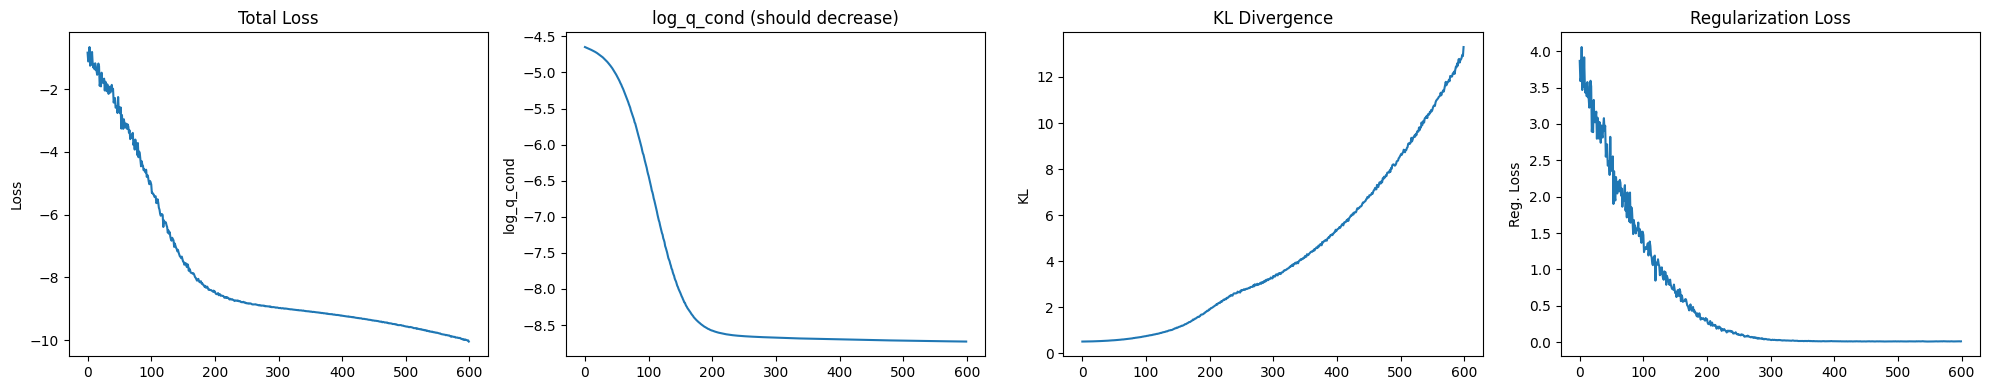

Training new model iteration 63...
Epoch 1: Loss=-1.2155, log_q=-4.4264,, reg. loss=3.2627, beta * KL=0.0518
Epoch 10: Loss=-8.5063, log_q=-8.5473,, reg. loss=0.2380, beta * KL=0.1970
Epoch 20: Loss=-9.2781, log_q=-8.7012,, reg. loss=0.0327, beta * KL=0.6096
Epoch 30: Loss=-10.1606, log_q=-8.7310,, reg. loss=0.0397, beta * KL=1.4693


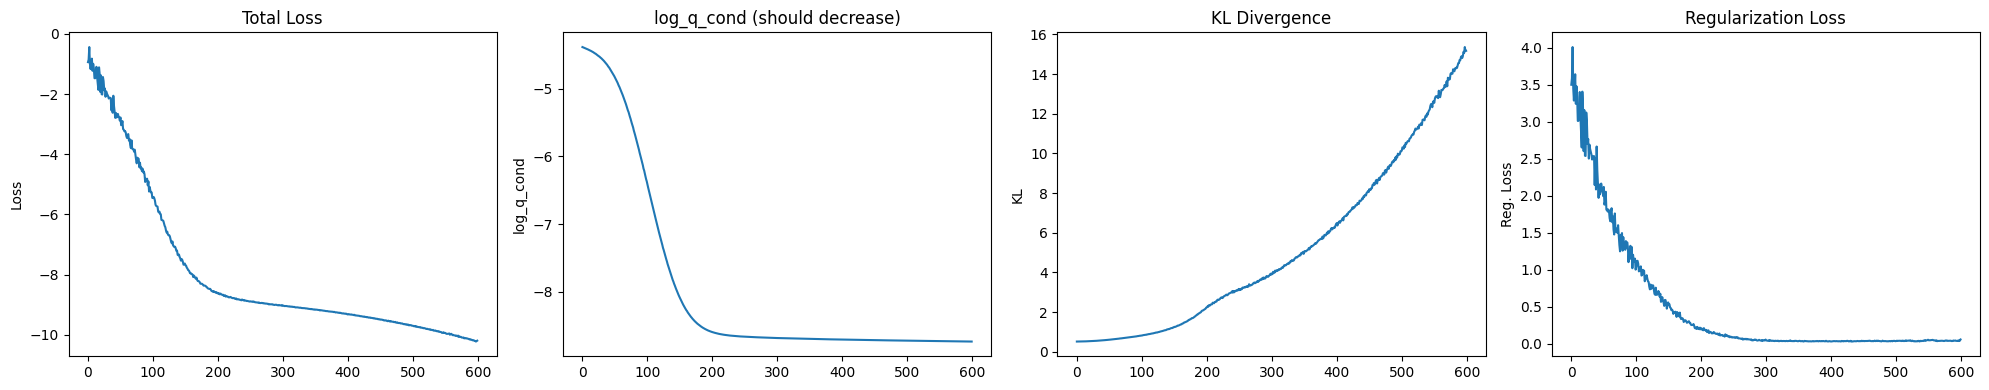

Training new model iteration 64...
Epoch 1: Loss=-1.6494, log_q=-4.5548,, reg. loss=2.9577, beta * KL=0.0523
Epoch 10: Loss=-8.5046, log_q=-8.5386,, reg. loss=0.2131, beta * KL=0.1790
Epoch 20: Loss=-9.3452, log_q=-8.6988,, reg. loss=0.0004, beta * KL=0.6467
Epoch 30: Loss=-10.4396, log_q=-8.7261,, reg. loss=0.0000, beta * KL=1.7135


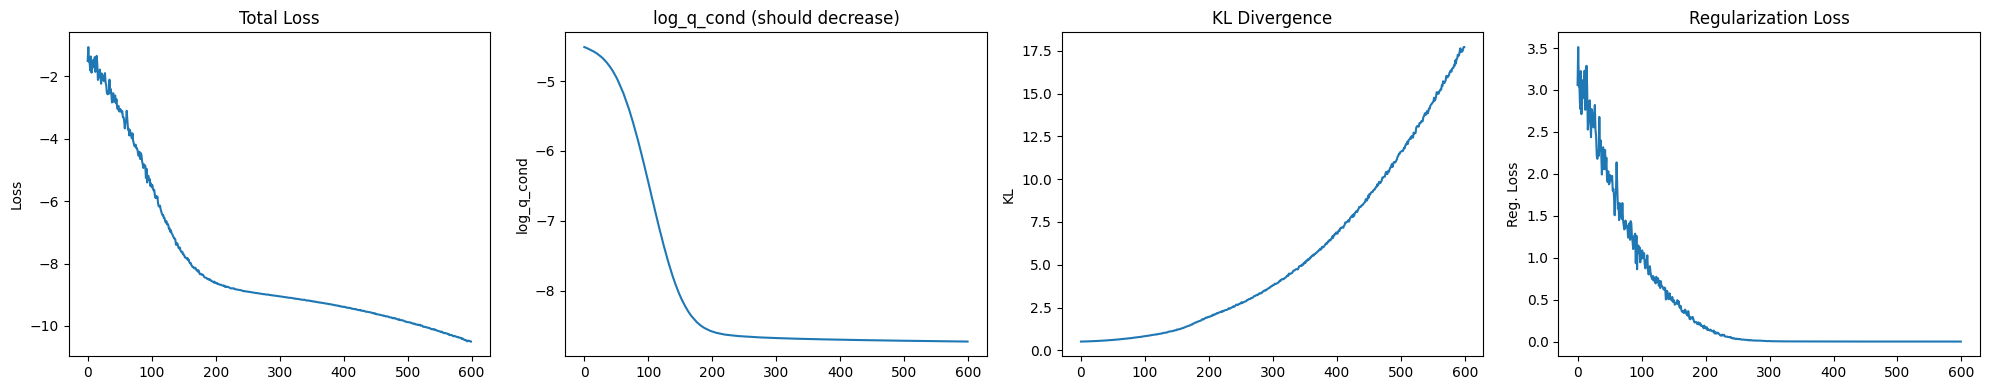

Training new model iteration 65...
Epoch 1: Loss=-0.8221, log_q=-4.4162,, reg. loss=3.6452, beta * KL=0.0512
Epoch 10: Loss=-8.5216, log_q=-8.6076,, reg. loss=0.5113, beta * KL=0.4253
Epoch 20: Loss=-9.2293, log_q=-8.6973,, reg. loss=0.0925, beta * KL=0.6245
Epoch 30: Loss=-10.0606, log_q=-8.7266,, reg. loss=0.1108, beta * KL=1.4448


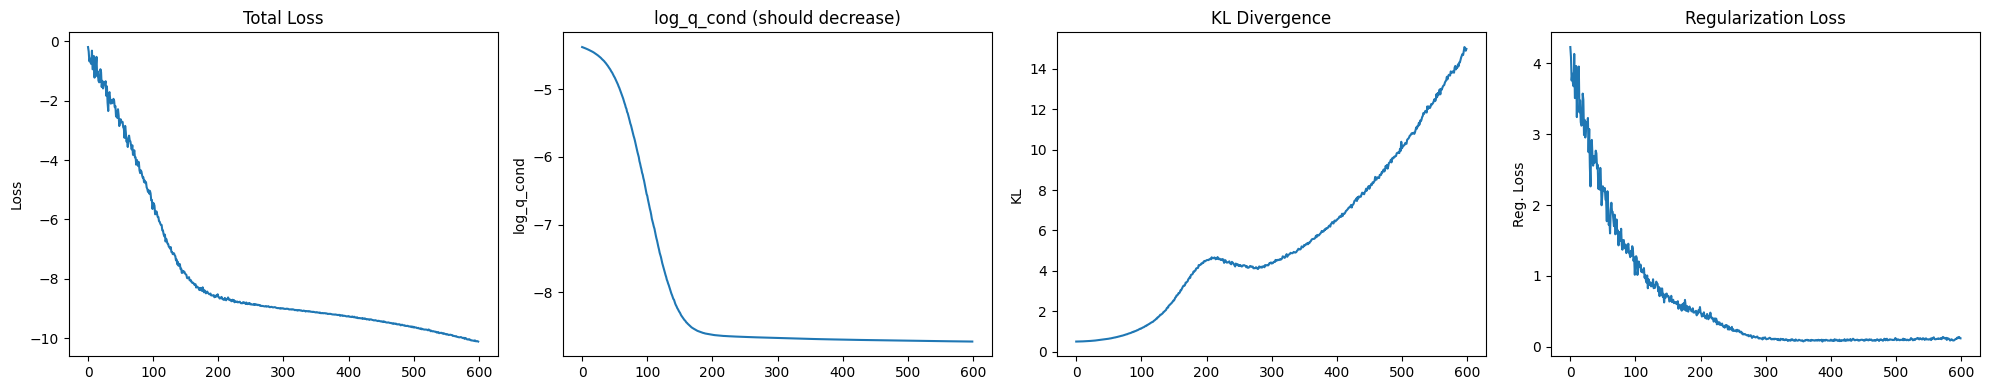

Training new model iteration 66...
Epoch 1: Loss=-1.3425, log_q=-4.7436,, reg. loss=3.4528, beta * KL=0.0517
Epoch 10: Loss=-8.1463, log_q=-8.4885,, reg. loss=0.4583, beta * KL=0.1161
Epoch 20: Loss=-9.0835, log_q=-8.6991,, reg. loss=0.0070, beta * KL=0.3914
Epoch 30: Loss=-9.6310, log_q=-8.7345,, reg. loss=0.0114, beta * KL=0.9079


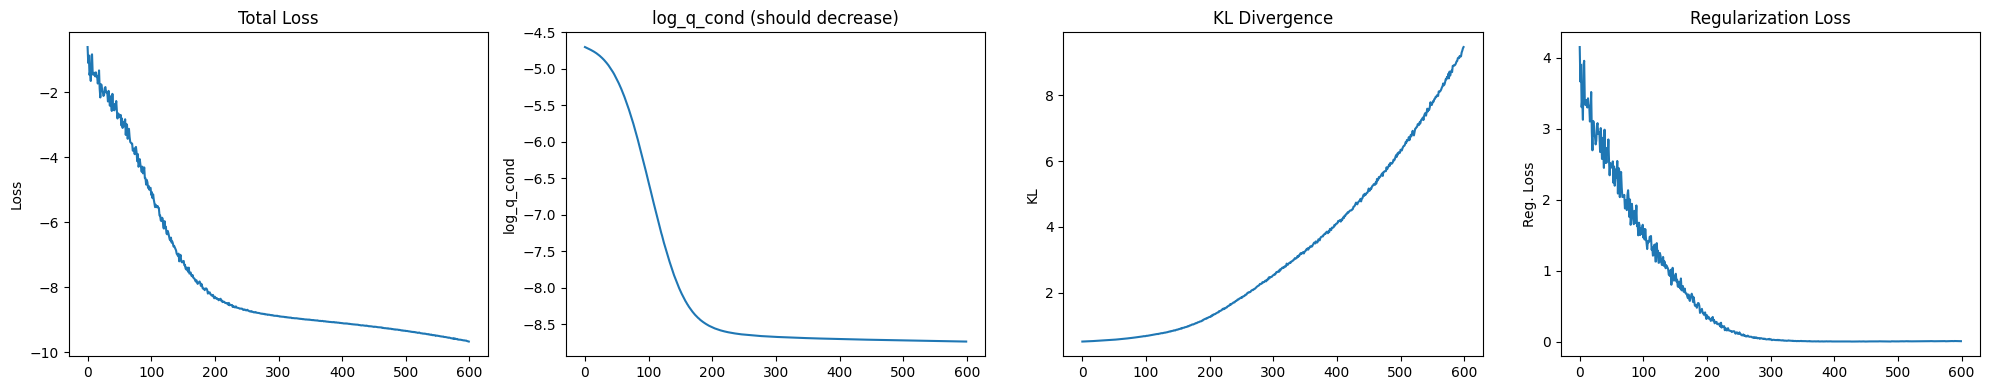

Training new model iteration 67...
Epoch 1: Loss=0.4276, log_q=-4.5963,, reg. loss=5.0759, beta * KL=0.0520
Epoch 10: Loss=-8.3800, log_q=-8.5960,, reg. loss=0.5087, beta * KL=0.2928
Epoch 20: Loss=-9.1290, log_q=-8.7028,, reg. loss=0.0735, beta * KL=0.4997
Epoch 30: Loss=-9.9072, log_q=-8.7364,, reg. loss=0.0419, beta * KL=1.2128


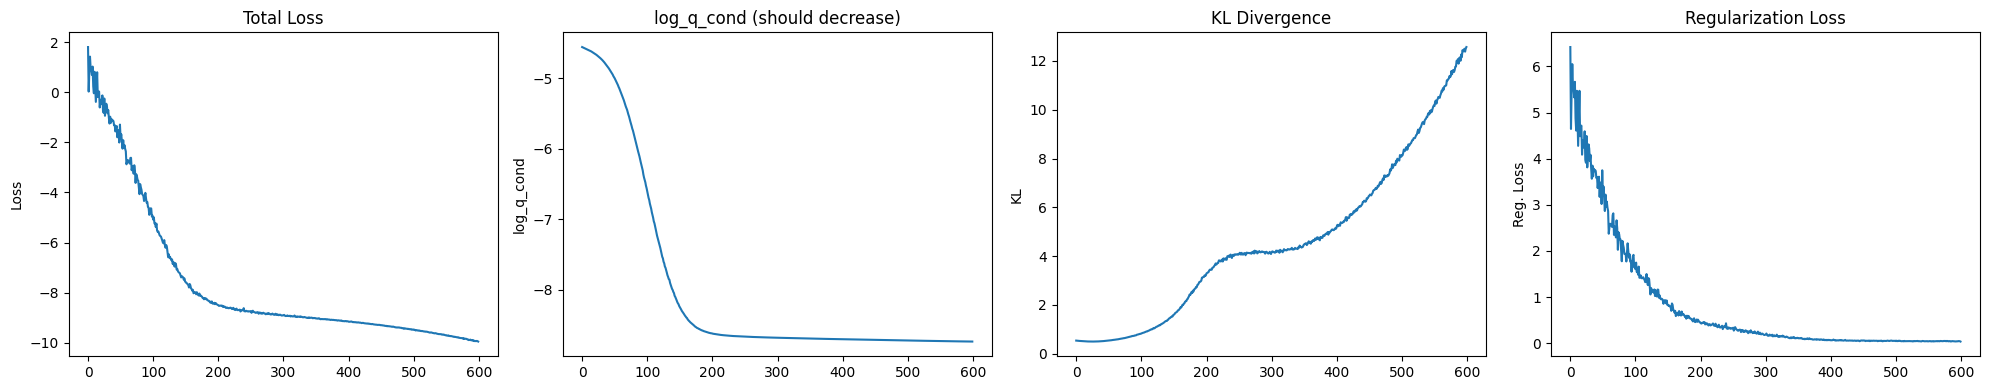

Training new model iteration 68...
Epoch 1: Loss=-1.2734, log_q=-4.6916,, reg. loss=3.4687, beta * KL=0.0504
Epoch 10: Loss=-8.1531, log_q=-8.4642,, reg. loss=0.4342, beta * KL=0.1231
Epoch 20: Loss=-9.1126, log_q=-8.6991,, reg. loss=0.0063, beta * KL=0.4198
Epoch 30: Loss=-9.7168, log_q=-8.7340,, reg. loss=0.0065, beta * KL=0.9894


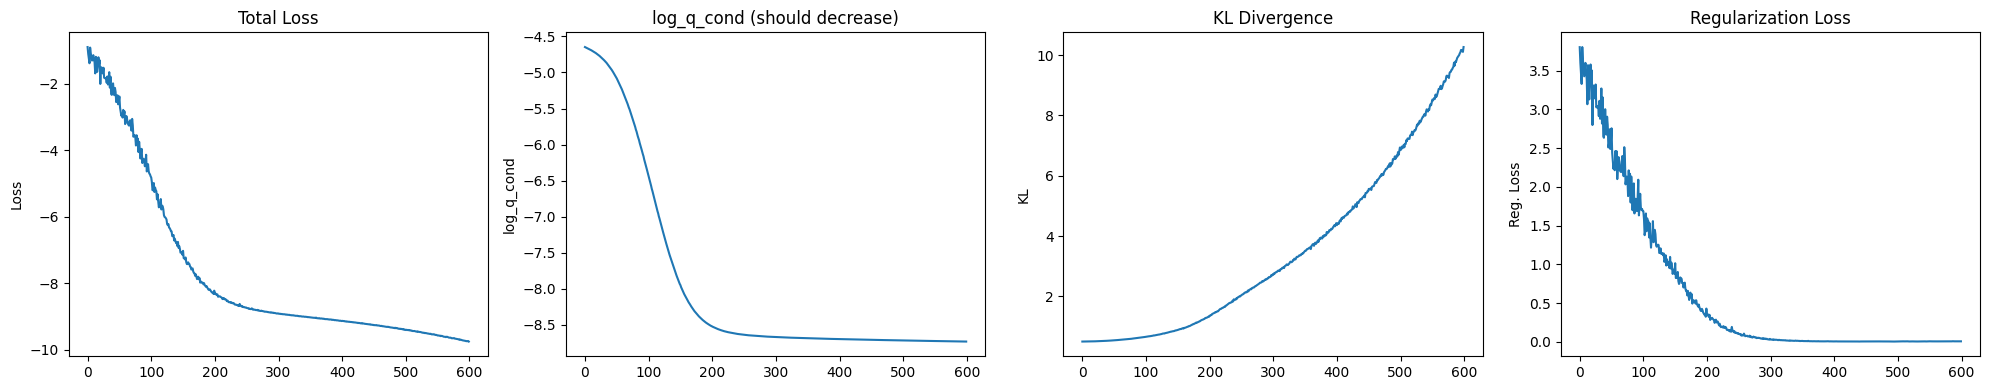

Training new model iteration 69...
Epoch 1: Loss=-0.3086, log_q=-4.5196,, reg. loss=4.2627, beta * KL=0.0517
Epoch 10: Loss=-8.0526, log_q=-8.4891,, reg. loss=0.5507, beta * KL=0.1142
Epoch 20: Loss=-9.1128, log_q=-8.7040,, reg. loss=0.0132, beta * KL=0.4221
Epoch 30: Loss=-9.7359, log_q=-8.7428,, reg. loss=0.0202, beta * KL=1.0133


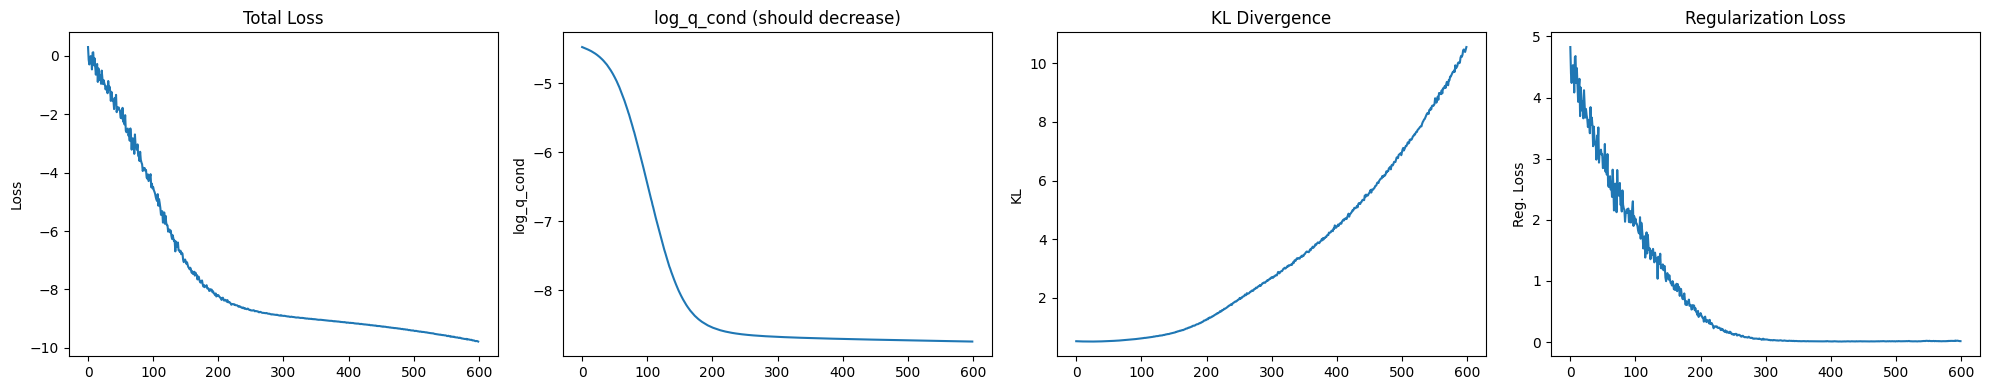

Training new model iteration 70...
Epoch 1: Loss=-0.6496, log_q=-4.7810,, reg. loss=4.1817, beta * KL=0.0502
Epoch 10: Loss=-8.3382, log_q=-8.5729,, reg. loss=0.4575, beta * KL=0.2228
Epoch 20: Loss=-9.1706, log_q=-8.7048,, reg. loss=0.0358, beta * KL=0.5017
Epoch 30: Loss=-9.9139, log_q=-8.7414,, reg. loss=0.0420, beta * KL=1.2145


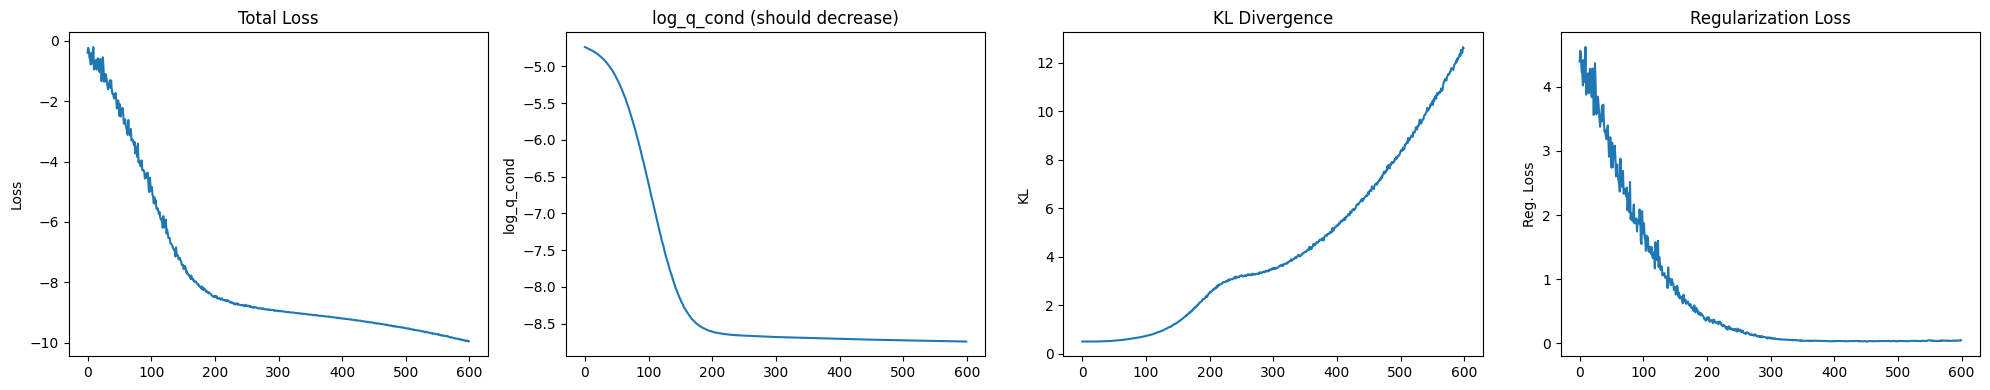

Training new model iteration 71...
Epoch 1: Loss=0.1204, log_q=-4.5373,, reg. loss=4.7084, beta * KL=0.0507
Epoch 10: Loss=-7.9190, log_q=-8.4858,, reg. loss=0.6856, beta * KL=0.1189
Epoch 20: Loss=-9.0567, log_q=-8.6975,, reg. loss=0.0070, beta * KL=0.3661
Epoch 30: Loss=-9.5817, log_q=-8.7371,, reg. loss=0.0130, beta * KL=0.8576


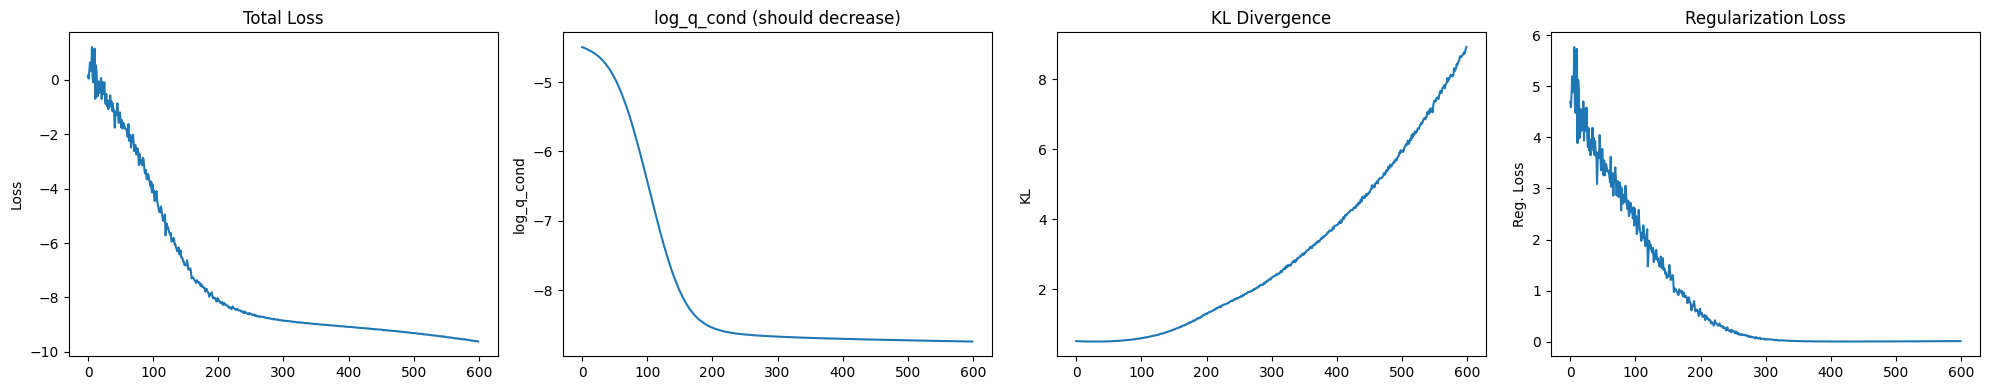

Training new model iteration 72...
Epoch 1: Loss=-1.4452, log_q=-4.4363,, reg. loss=3.0428, beta * KL=0.0517
Epoch 10: Loss=-8.0969, log_q=-8.4746,, reg. loss=0.5234, beta * KL=0.1457
Epoch 20: Loss=-9.0907, log_q=-8.6921,, reg. loss=0.0035, beta * KL=0.4022
Epoch 30: Loss=-9.7494, log_q=-8.7248,, reg. loss=0.0025, beta * KL=1.0271


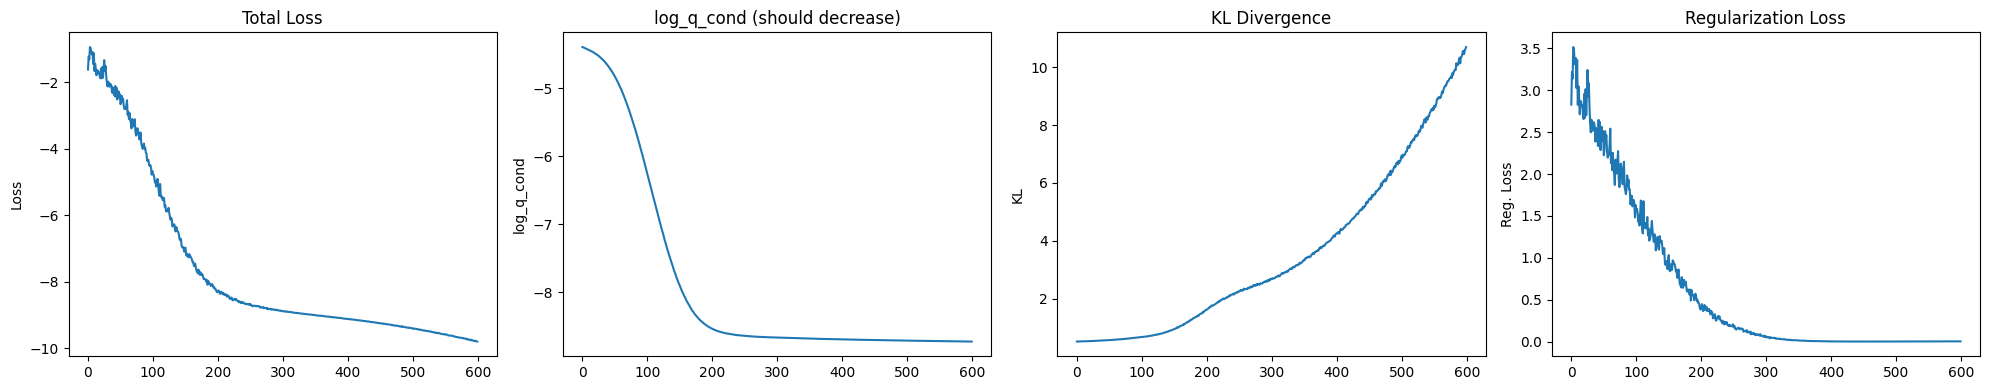

Training new model iteration 73...
Epoch 1: Loss=-0.3037, log_q=-4.6693,, reg. loss=4.4180, beta * KL=0.0524
Epoch 10: Loss=-8.0846, log_q=-8.5539,, reg. loss=0.6914, beta * KL=0.2221
Epoch 20: Loss=-9.0828, log_q=-8.7000,, reg. loss=0.0719, beta * KL=0.4547
Epoch 30: Loss=-9.6506, log_q=-8.7415,, reg. loss=0.0835, beta * KL=0.9926


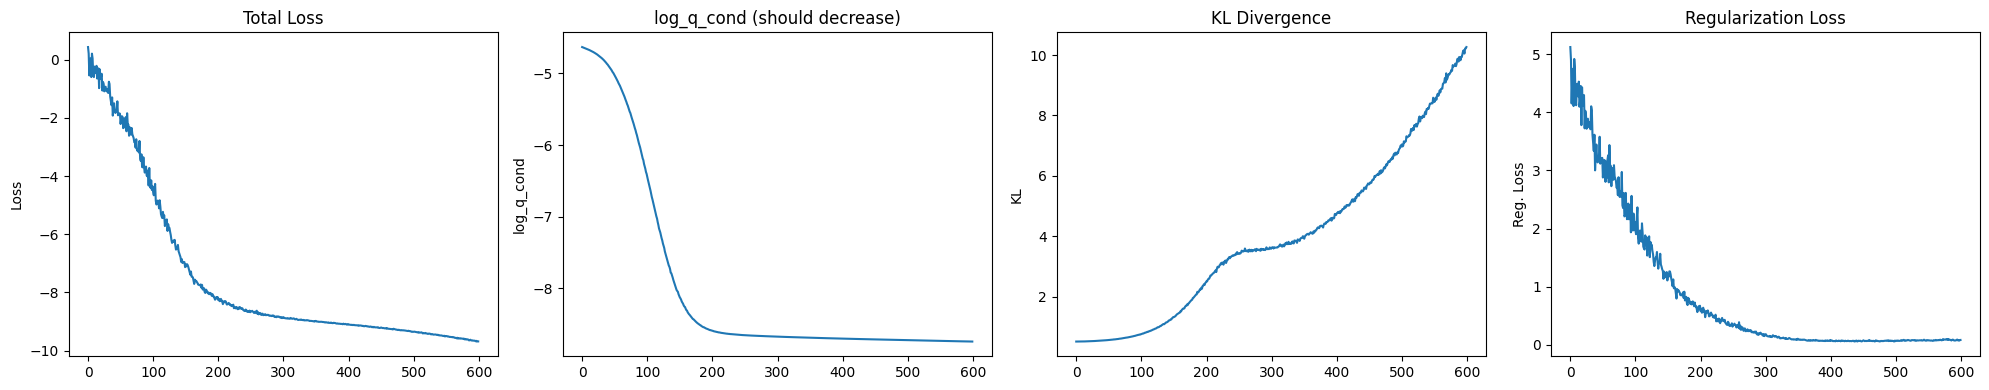

Training new model iteration 74...
Epoch 1: Loss=-1.7085, log_q=-4.7265,, reg. loss=3.0700, beta * KL=0.0521
Epoch 10: Loss=-8.4685, log_q=-8.5237,, reg. loss=0.2514, beta * KL=0.1963
Epoch 20: Loss=-9.3483, log_q=-8.6976,, reg. loss=0.0203, beta * KL=0.6710
Epoch 30: Loss=-10.4582, log_q=-8.7254,, reg. loss=0.0276, beta * KL=1.7604


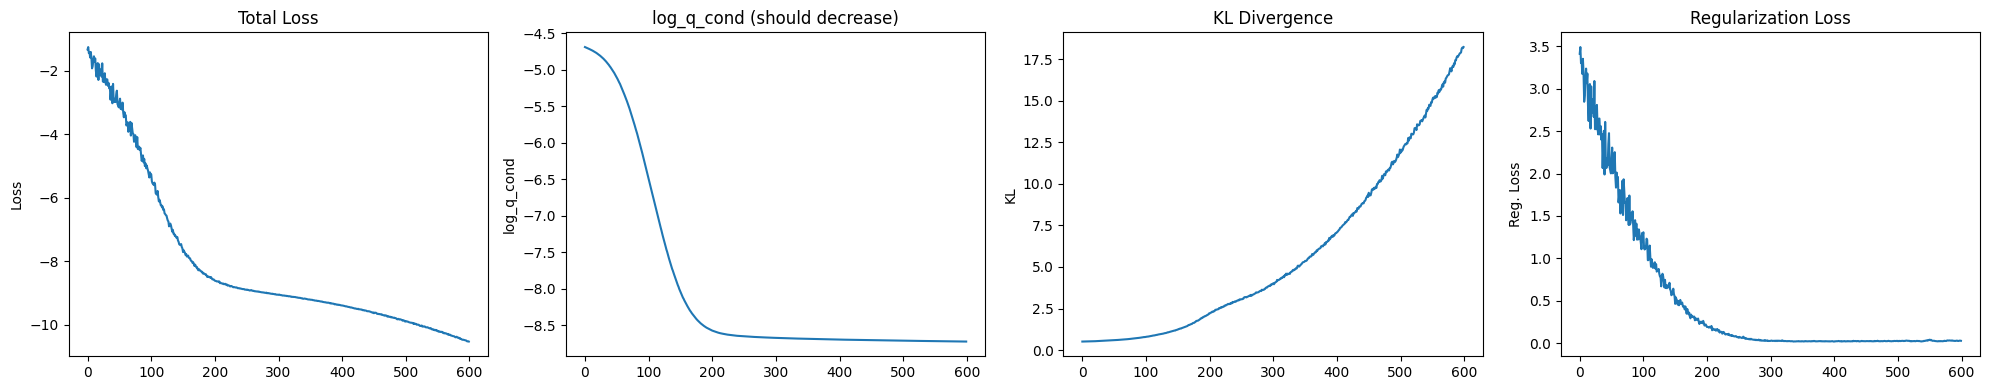

Training new model iteration 75...
Epoch 1: Loss=-1.2616, log_q=-4.8267,, reg. loss=3.6184, beta * KL=0.0533
Epoch 10: Loss=-8.2410, log_q=-8.5194,, reg. loss=0.4408, beta * KL=0.1624
Epoch 20: Loss=-9.1575, log_q=-8.7017,, reg. loss=0.0465, beta * KL=0.5023
Epoch 30: Loss=-9.8568, log_q=-8.7400,, reg. loss=0.0767, beta * KL=1.1934


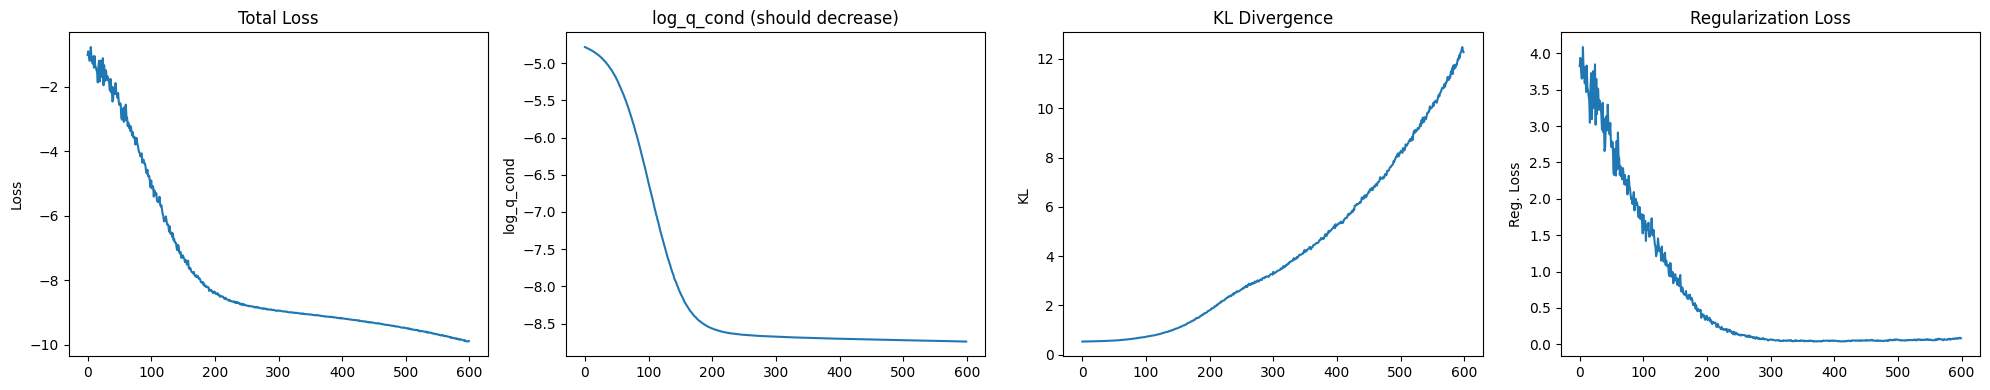

Training new model iteration 76...
Epoch 1: Loss=-1.6861, log_q=-4.6975,, reg. loss=3.0652, beta * KL=0.0537
Epoch 10: Loss=-8.4934, log_q=-8.5516,, reg. loss=0.2924, beta * KL=0.2342
Epoch 20: Loss=-9.2711, log_q=-8.6981,, reg. loss=0.0586, beta * KL=0.6316
Epoch 30: Loss=-10.2152, log_q=-8.7276,, reg. loss=0.0552, beta * KL=1.5428


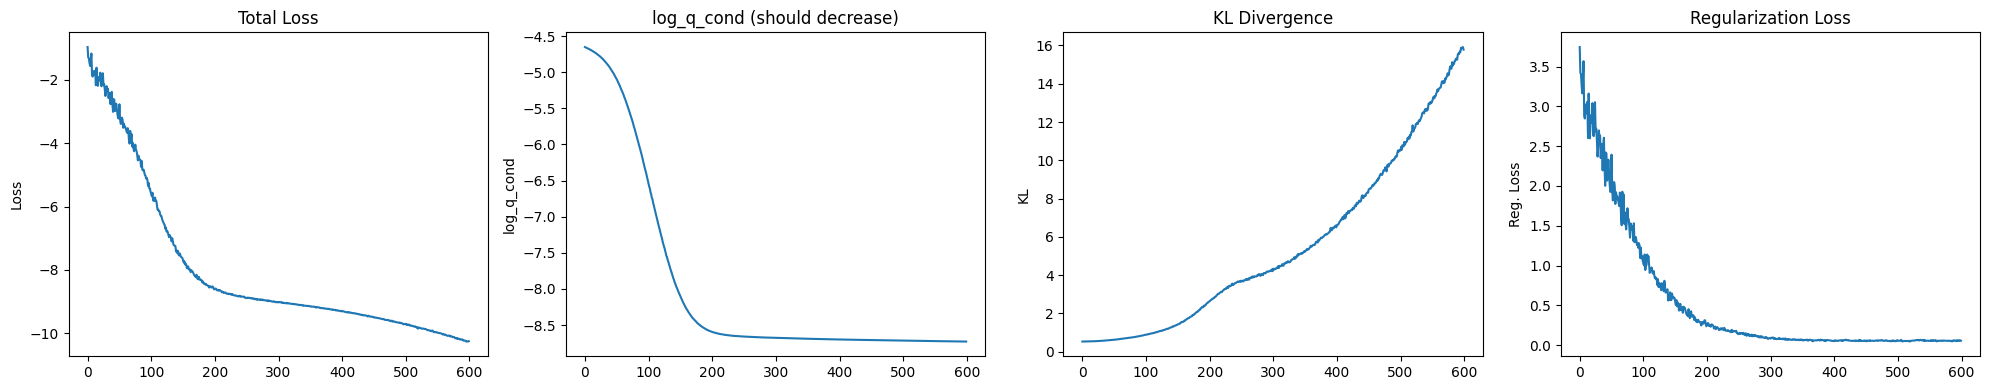

Training new model iteration 77...
Epoch 1: Loss=-1.0632, log_q=-4.4909,, reg. loss=3.4786, beta * KL=0.0509
Epoch 10: Loss=-8.3629, log_q=-8.5603,, reg. loss=0.4217, beta * KL=0.2243
Epoch 20: Loss=-9.1815, log_q=-8.7030,, reg. loss=0.0217, beta * KL=0.5002
Epoch 30: Loss=-9.9399, log_q=-8.7380,, reg. loss=0.0235, beta * KL=1.2254


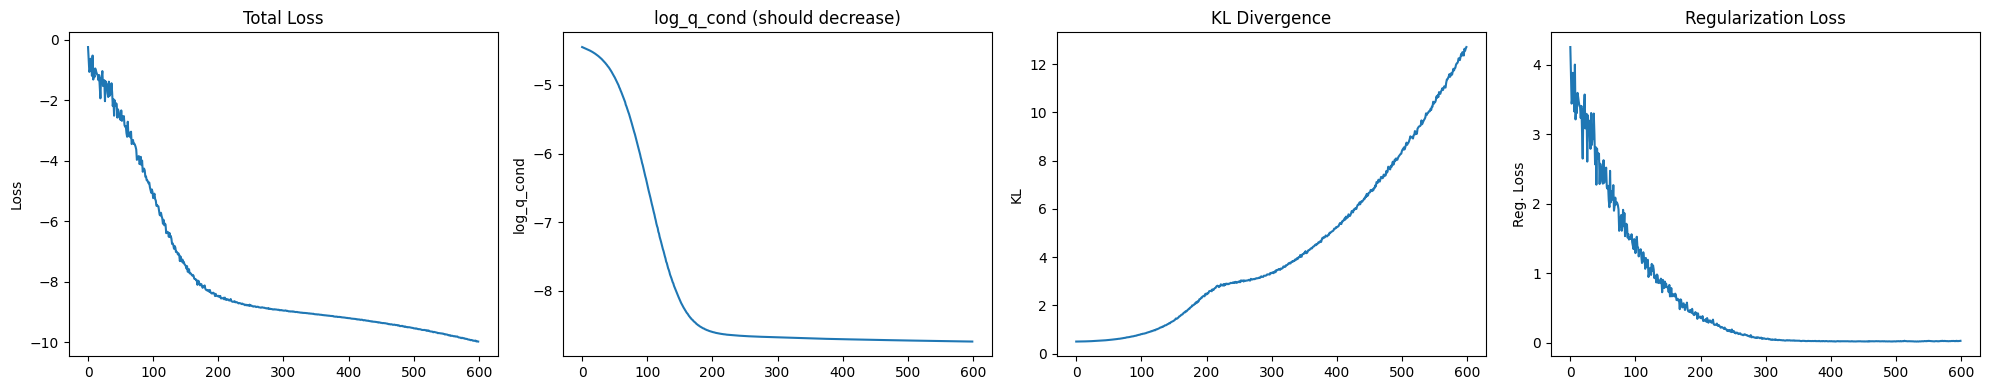

Training new model iteration 78...
Epoch 1: Loss=-1.7961, log_q=-4.5436,, reg. loss=2.8026, beta * KL=0.0551
Epoch 10: Loss=-8.4943, log_q=-8.5669,, reg. loss=0.3487, beta * KL=0.2761
Epoch 20: Loss=-9.2646, log_q=-8.6922,, reg. loss=0.0169, beta * KL=0.5893
Epoch 30: Loss=-10.1983, log_q=-8.7202,, reg. loss=0.0105, beta * KL=1.4886


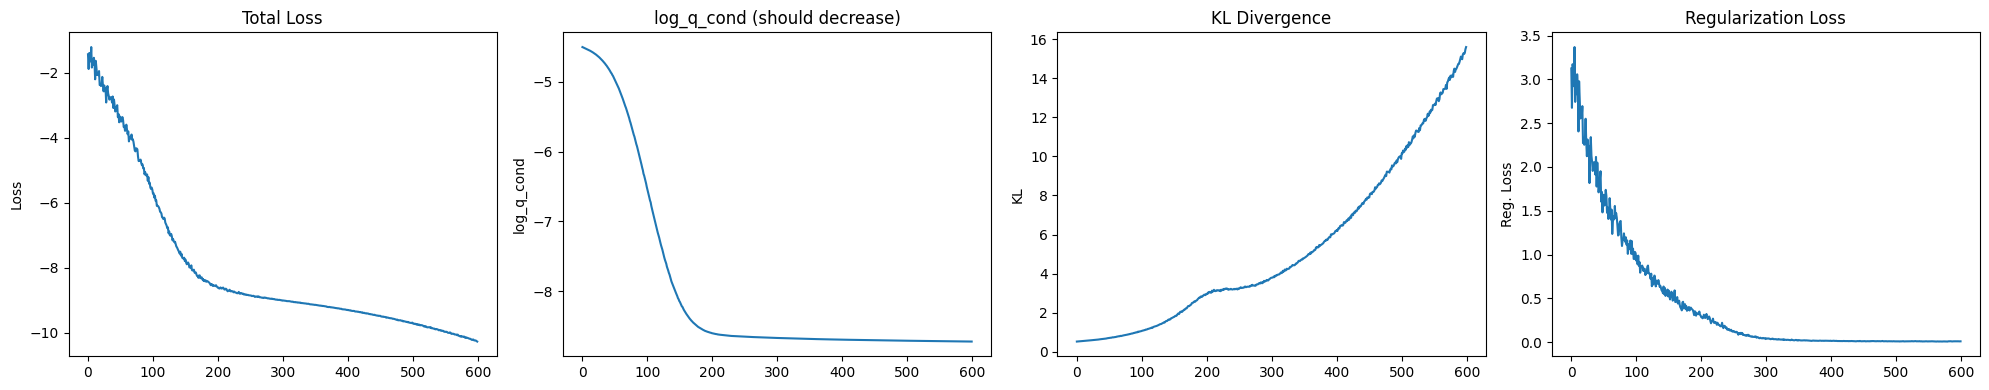

Training new model iteration 79...
Epoch 1: Loss=-0.9295, log_q=-4.9358,, reg. loss=4.0590, beta * KL=0.0528
Epoch 10: Loss=-8.2303, log_q=-8.5557,, reg. loss=0.5663, beta * KL=0.2410
Epoch 20: Loss=-9.1305, log_q=-8.7016,, reg. loss=0.0497, beta * KL=0.4786
Epoch 30: Loss=-9.8164, log_q=-8.7384,, reg. loss=0.0467, beta * KL=1.1248


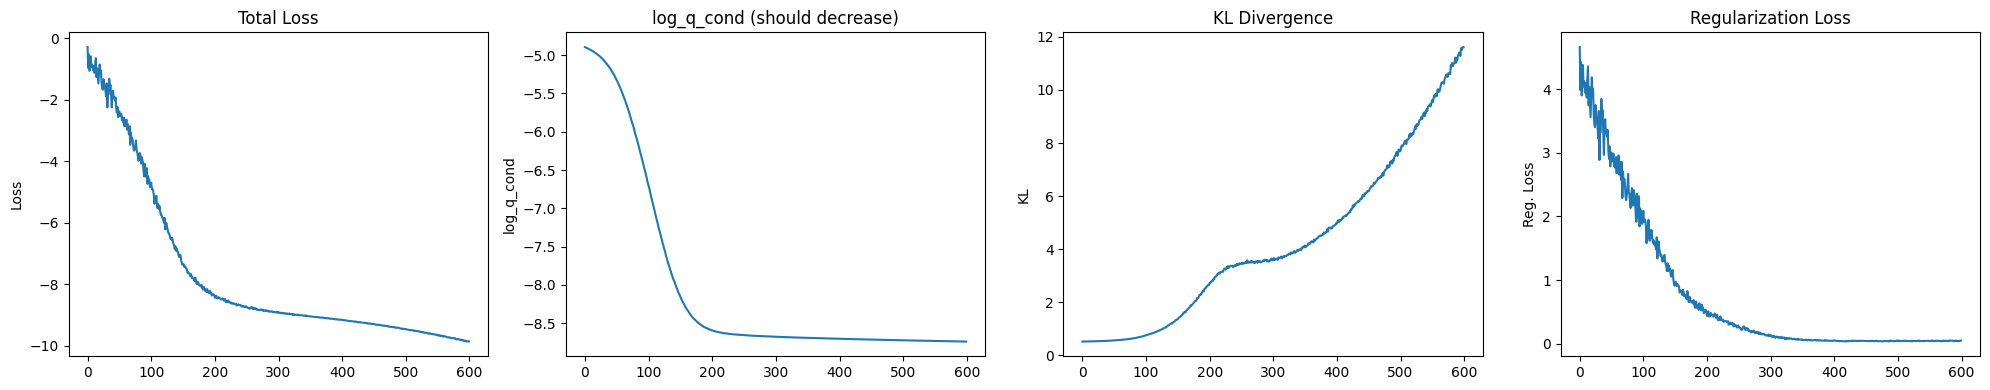

Training new model iteration 80...
Epoch 1: Loss=-0.7024, log_q=-4.7097,, reg. loss=4.0595, beta * KL=0.0522
Epoch 10: Loss=-8.2010, log_q=-8.5399,, reg. loss=0.4790, beta * KL=0.1401
Epoch 20: Loss=-9.1440, log_q=-8.7036,, reg. loss=0.0241, beta * KL=0.4645
Epoch 30: Loss=-9.8222, log_q=-8.7422,, reg. loss=0.0349, beta * KL=1.1149


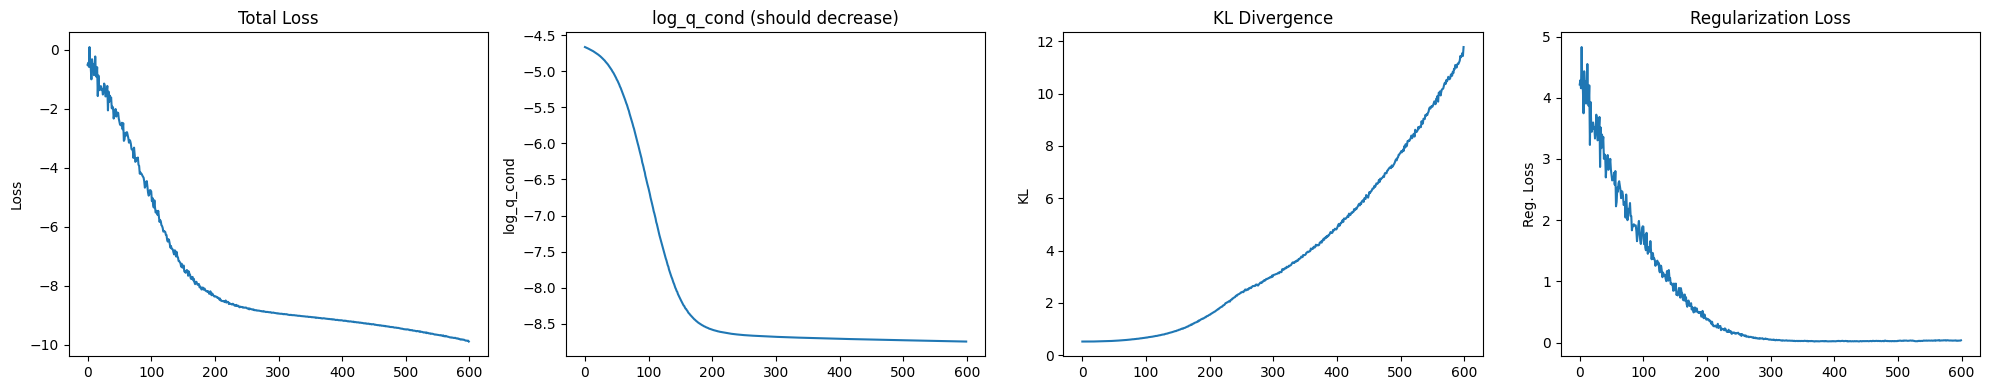

Training new model iteration 81...
Epoch 1: Loss=-1.9402, log_q=-4.7426,, reg. loss=2.8562, beta * KL=0.0537
Epoch 10: Loss=-8.4470, log_q=-8.5595,, reg. loss=0.3534, beta * KL=0.2408
Epoch 20: Loss=-9.1665, log_q=-8.6988,, reg. loss=0.0747, beta * KL=0.5424
Epoch 30: Loss=-9.8867, log_q=-8.7303,, reg. loss=0.0640, beta * KL=1.2204


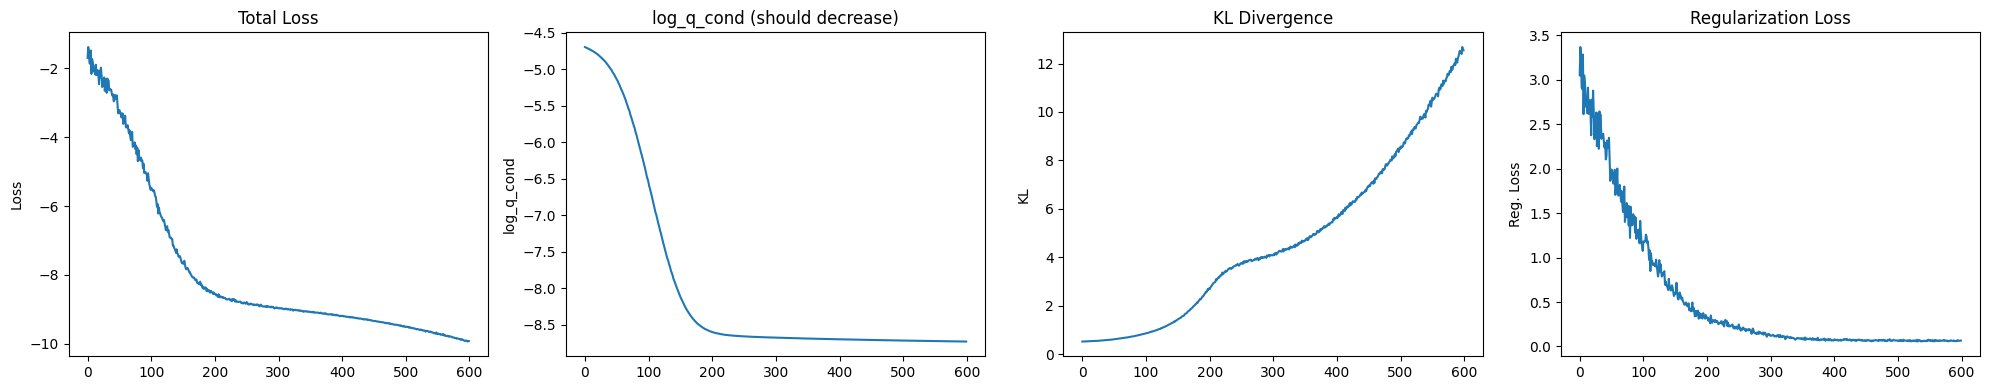

Training new model iteration 82...
Epoch 1: Loss=-1.1191, log_q=-4.6694,, reg. loss=3.6034, beta * KL=0.0531
Epoch 10: Loss=-8.2507, log_q=-8.5620,, reg. loss=0.5378, beta * KL=0.2264
Epoch 20: Loss=-9.1056, log_q=-8.6998,, reg. loss=0.0541, beta * KL=0.4599
Epoch 30: Loss=-9.7018, log_q=-8.7387,, reg. loss=0.0554, beta * KL=1.0185


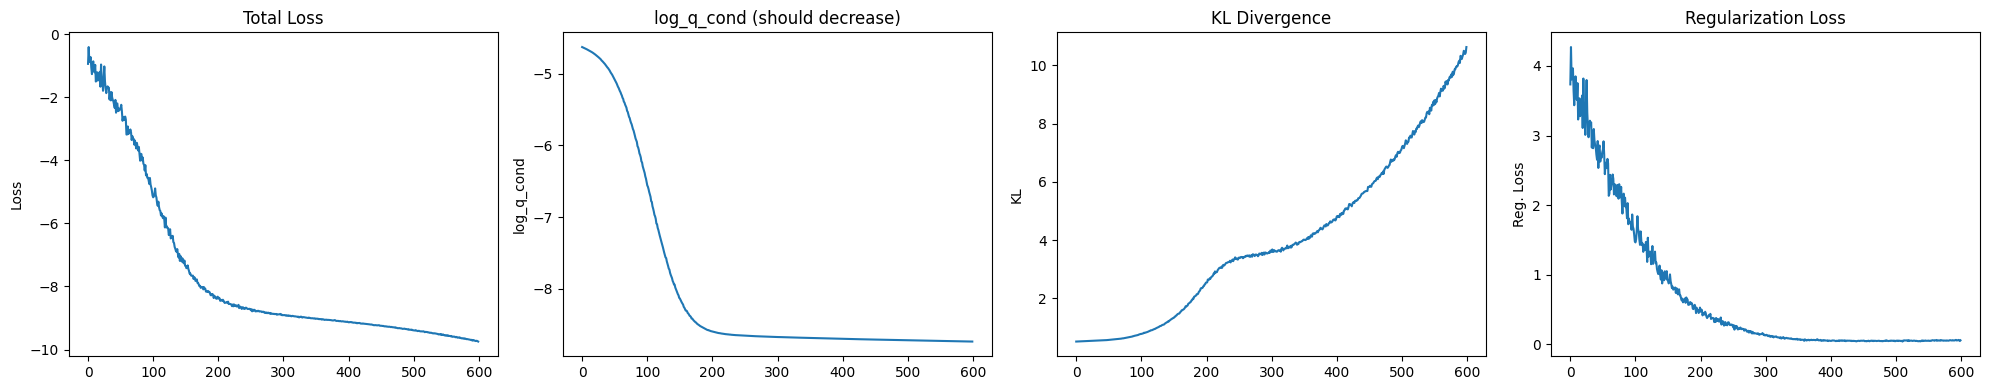

Training new model iteration 83...
Epoch 1: Loss=-1.7047, log_q=-4.7198,, reg. loss=3.0673, beta * KL=0.0522
Epoch 10: Loss=-8.5619, log_q=-8.5905,, reg. loss=0.3112, beta * KL=0.2826
Epoch 20: Loss=-9.2863, log_q=-8.7021,, reg. loss=0.0569, beta * KL=0.6411
Epoch 30: Loss=-10.2157, log_q=-8.7343,, reg. loss=0.0687, beta * KL=1.5501


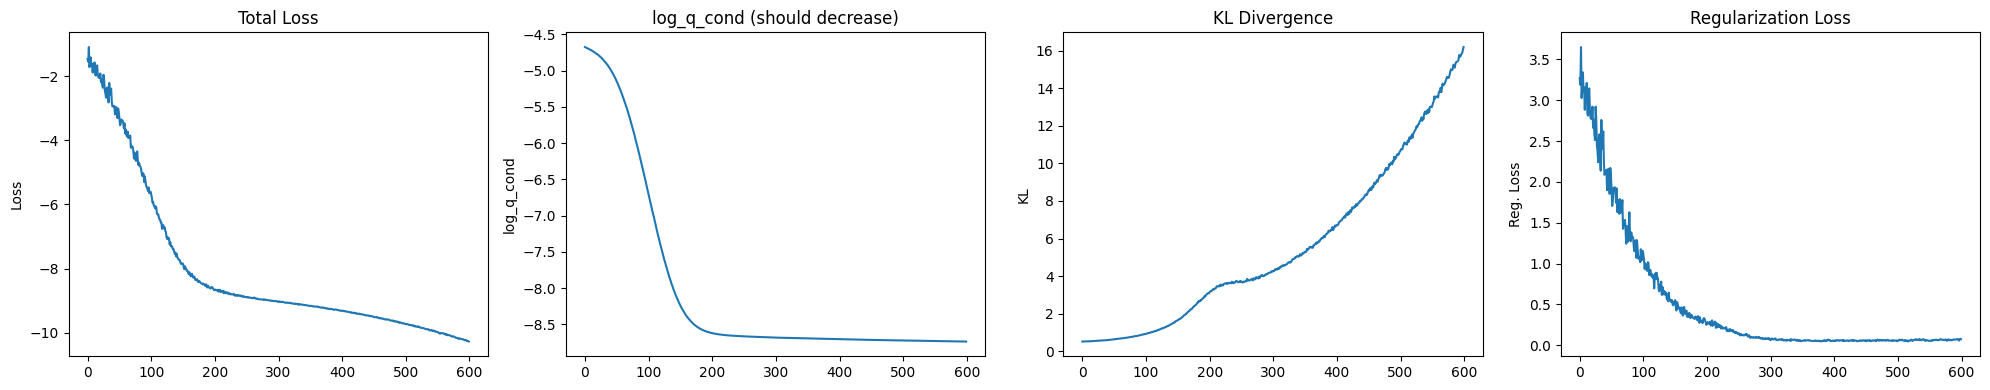

Training new model iteration 84...
Epoch 1: Loss=-0.4331, log_q=-4.7128,, reg. loss=4.3302, beta * KL=0.0504
Epoch 10: Loss=-7.9596, log_q=-8.4751,, reg. loss=0.6293, beta * KL=0.1139
Epoch 20: Loss=-9.0554, log_q=-8.7029,, reg. loss=0.0106, beta * KL=0.3631
Epoch 30: Loss=-9.5856, log_q=-8.7443,, reg. loss=0.0116, beta * KL=0.8530


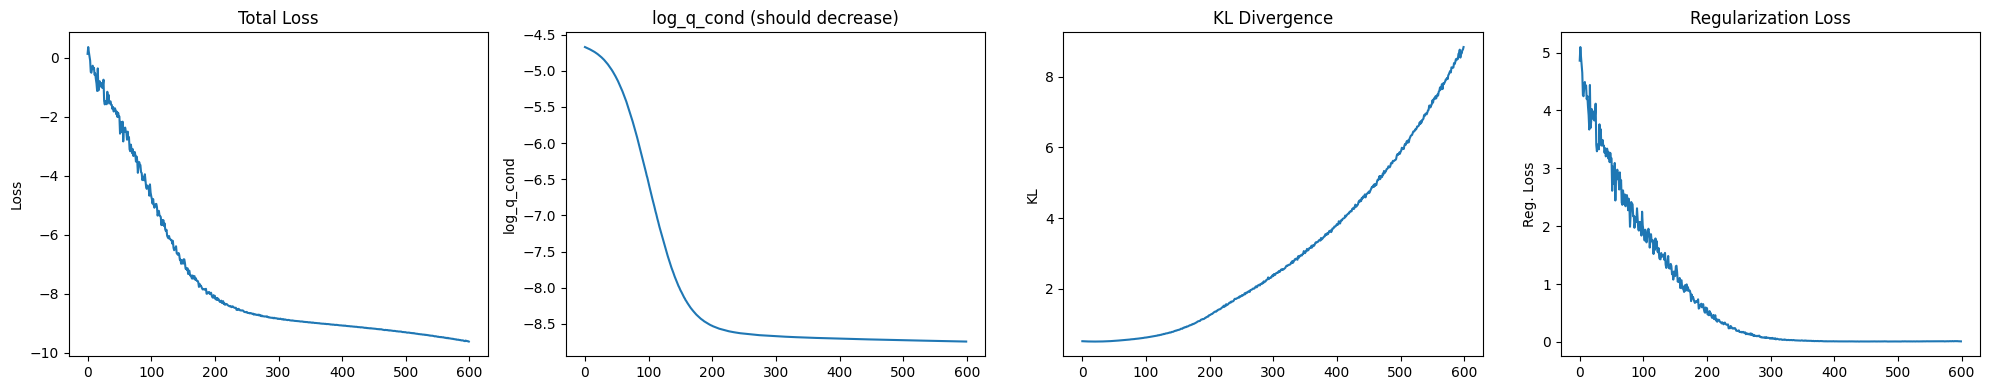

Training new model iteration 85...
Epoch 1: Loss=-1.3318, log_q=-4.5518,, reg. loss=3.2723, beta * KL=0.0523
Epoch 10: Loss=-8.4204, log_q=-8.5657,, reg. loss=0.4197, beta * KL=0.2744
Epoch 20: Loss=-9.1628, log_q=-8.6976,, reg. loss=0.0619, beta * KL=0.5270
Epoch 30: Loss=-9.9085, log_q=-8.7300,, reg. loss=0.0553, beta * KL=1.2338


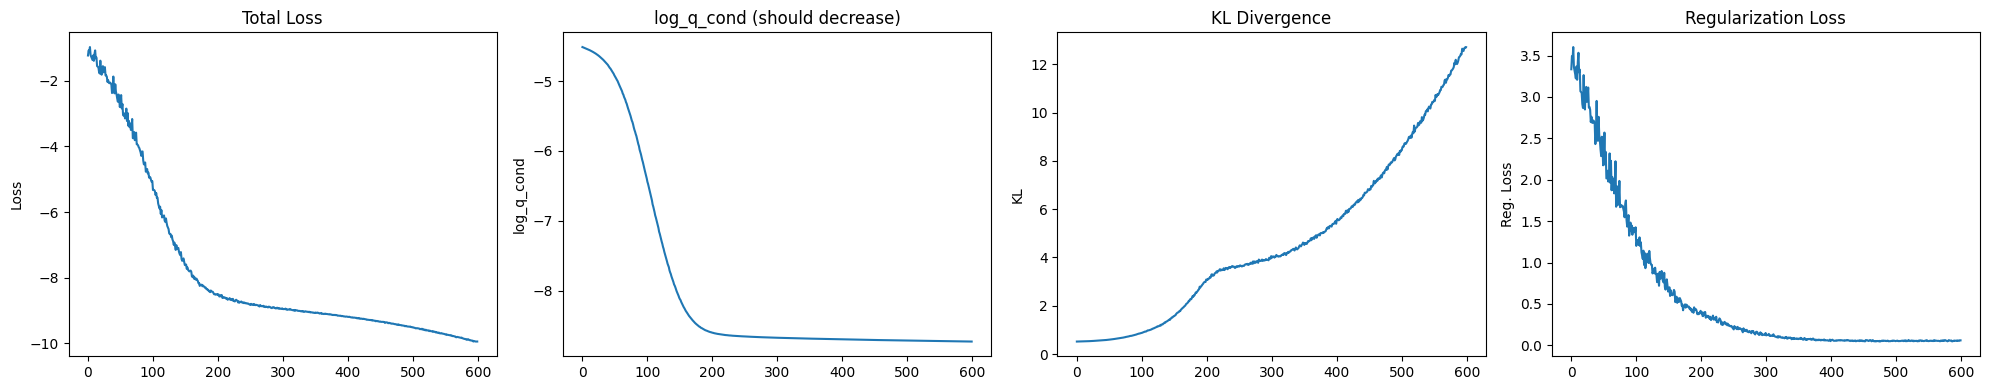

Training new model iteration 86...
Epoch 1: Loss=-0.4954, log_q=-4.6480,, reg. loss=4.2085, beta * KL=0.0560
Epoch 10: Loss=-8.5226, log_q=-8.5833,, reg. loss=0.2827, beta * KL=0.2221
Epoch 20: Loss=-9.2552, log_q=-8.7051,, reg. loss=0.0505, beta * KL=0.6007
Epoch 30: Loss=-10.1122, log_q=-8.7409,, reg. loss=0.0611, beta * KL=1.4325


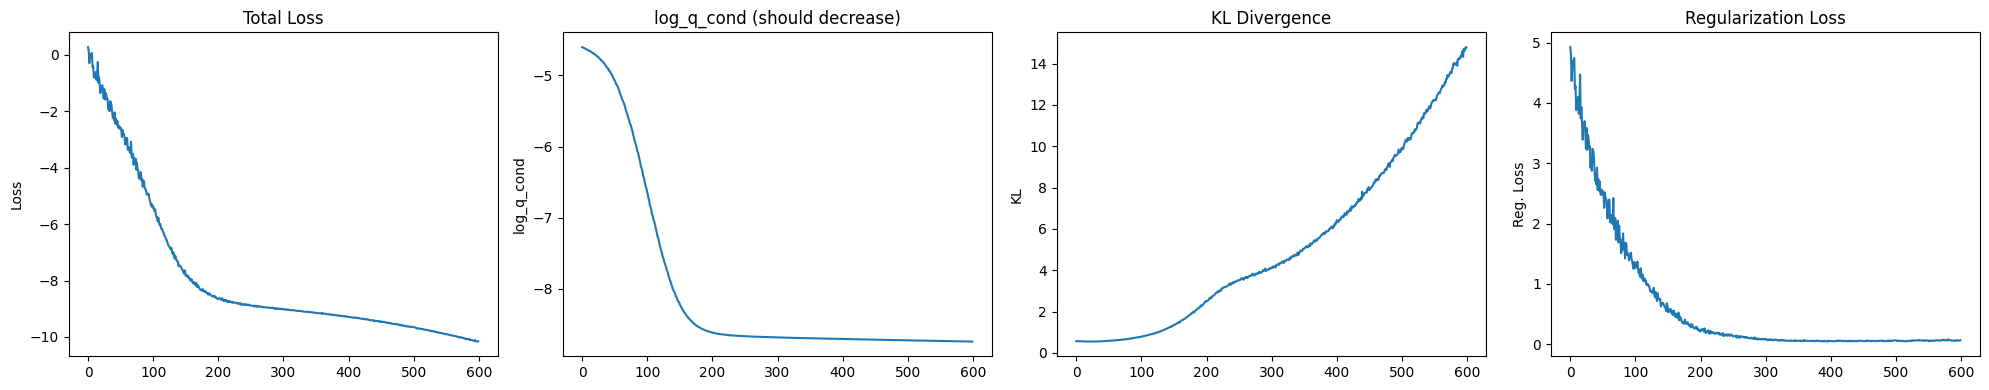

Training new model iteration 87...
Epoch 1: Loss=-0.3930, log_q=-4.4932,, reg. loss=4.1540, beta * KL=0.0538
Epoch 10: Loss=-8.0730, log_q=-8.5081,, reg. loss=0.5668, beta * KL=0.1317
Epoch 20: Loss=-9.1056, log_q=-8.7018,, reg. loss=0.0257, beta * KL=0.4295
Epoch 30: Loss=-9.7197, log_q=-8.7410,, reg. loss=0.0395, beta * KL=1.0182


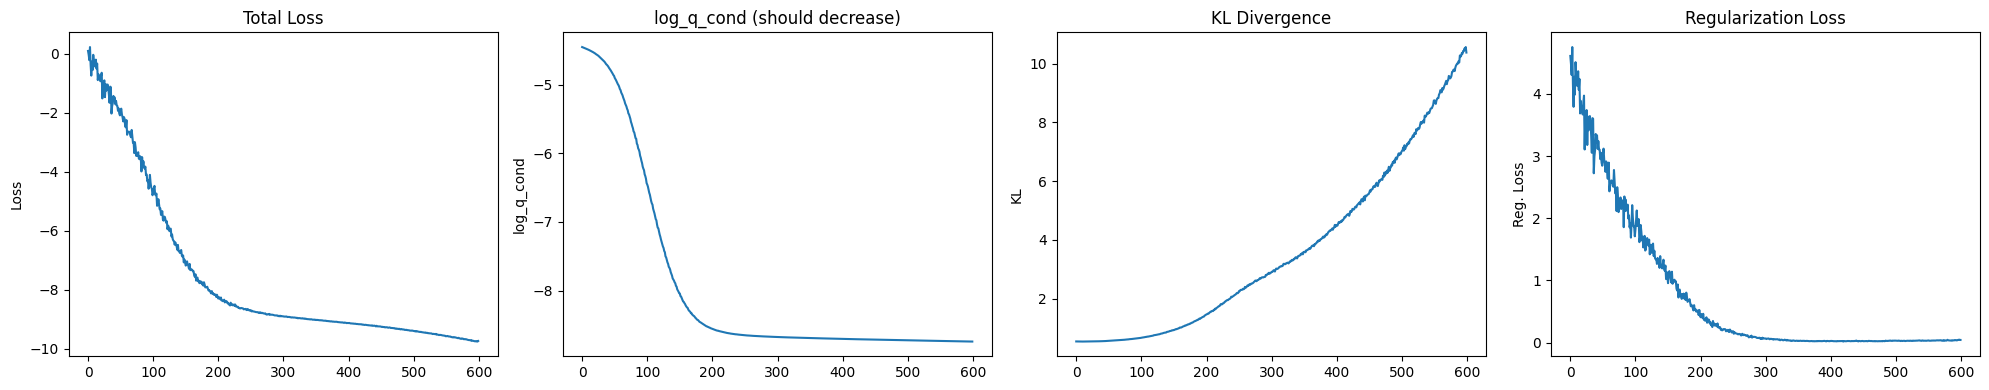

Training new model iteration 88...
Epoch 1: Loss=-1.0208, log_q=-4.6566,, reg. loss=3.6861, beta * KL=0.0503
Epoch 10: Loss=-8.2448, log_q=-8.5413,, reg. loss=0.5014, beta * KL=0.2048
Epoch 20: Loss=-9.1491, log_q=-8.6973,, reg. loss=0.0760, beta * KL=0.5279
Epoch 30: Loss=-9.9338, log_q=-8.7279,, reg. loss=0.0544, beta * KL=1.2603


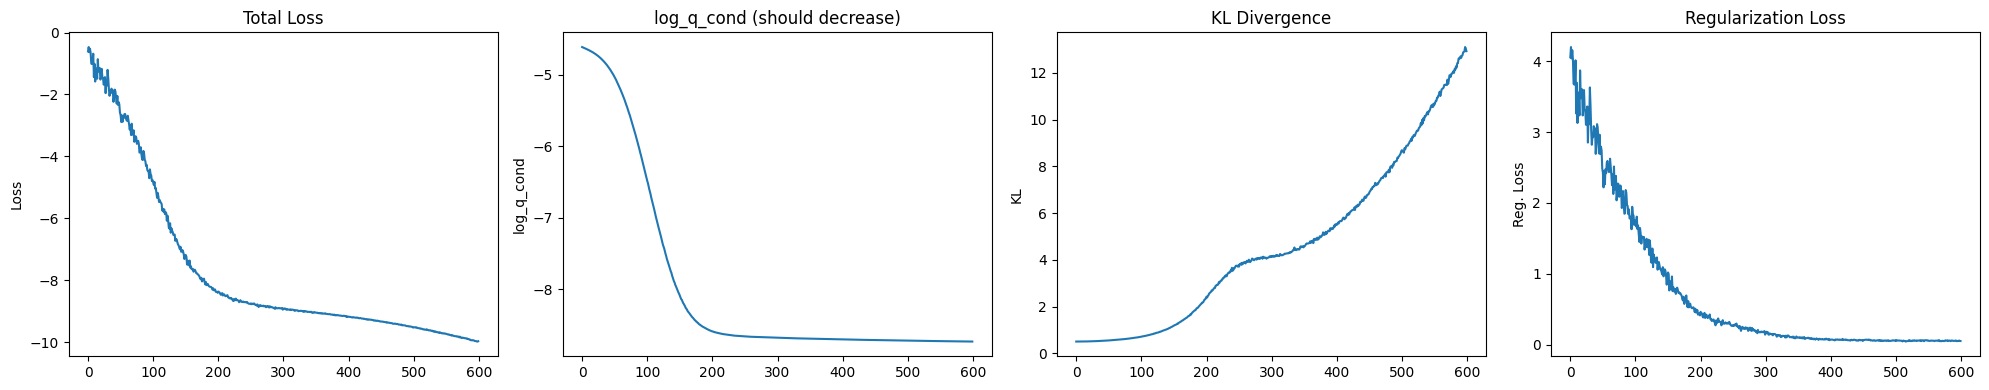

Training new model iteration 89...
Epoch 1: Loss=-1.5659, log_q=-4.8868,, reg. loss=3.3732, beta * KL=0.0523
Epoch 10: Loss=-8.2284, log_q=-8.5379,, reg. loss=0.4598, beta * KL=0.1503
Epoch 20: Loss=-9.0782, log_q=-8.7025,, reg. loss=0.0368, beta * KL=0.4125
Epoch 30: Loss=-9.5977, log_q=-8.7420,, reg. loss=0.0350, beta * KL=0.8907


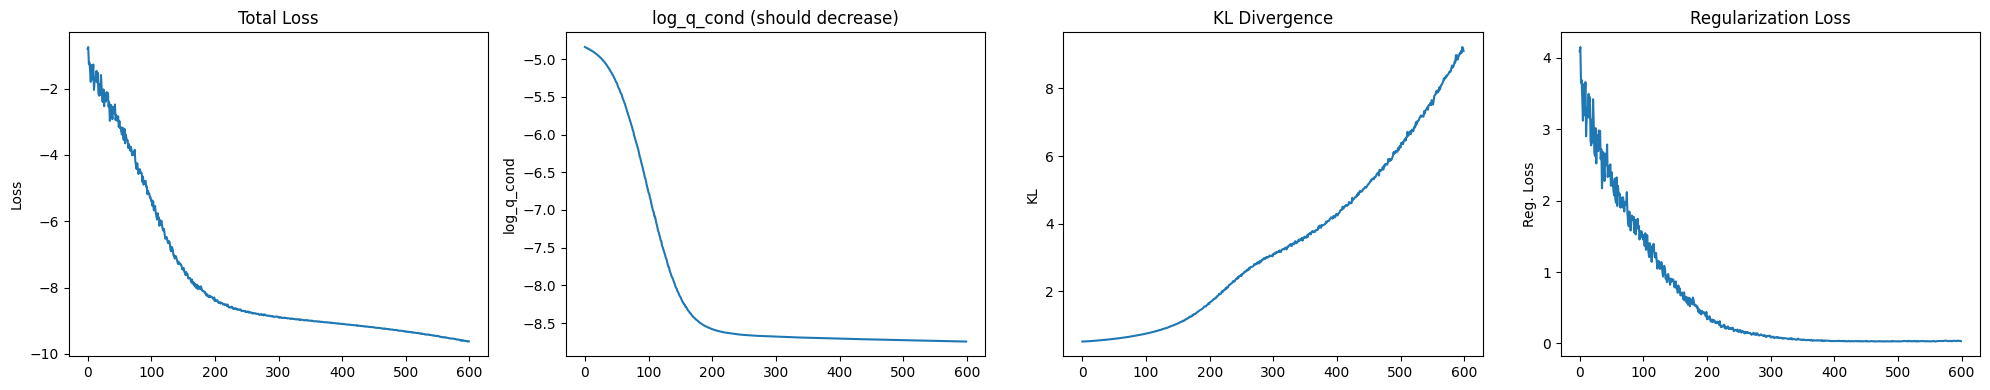

Training new model iteration 90...
Epoch 1: Loss=-1.5870, log_q=-4.5803,, reg. loss=3.0460, beta * KL=0.0528
Epoch 10: Loss=-8.0185, log_q=-8.4428,, reg. loss=0.5336, beta * KL=0.1093
Epoch 20: Loss=-9.0891, log_q=-8.6978,, reg. loss=0.0222, beta * KL=0.4136
Epoch 30: Loss=-9.6474, log_q=-8.7376,, reg. loss=0.0336, beta * KL=0.9433


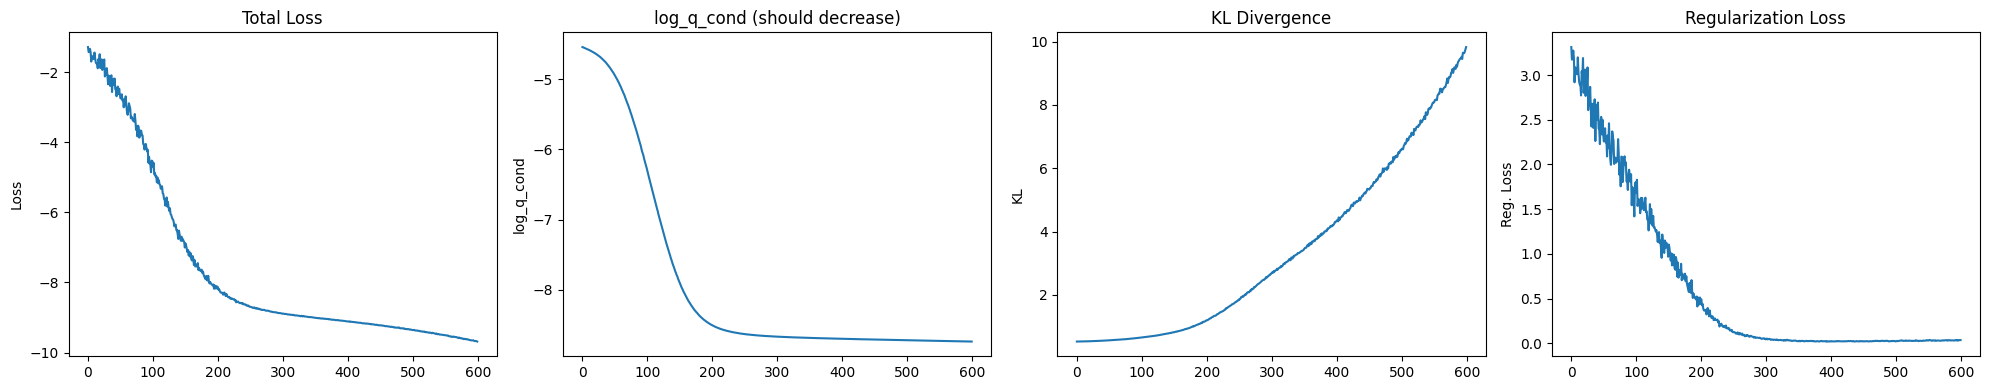

Training new model iteration 91...
Epoch 1: Loss=-0.4109, log_q=-4.4470,, reg. loss=4.0882, beta * KL=0.0520
Epoch 10: Loss=-8.3875, log_q=-8.5361,, reg. loss=0.3419, beta * KL=0.1933
Epoch 20: Loss=-9.2086, log_q=-8.6990,, reg. loss=0.0529, beta * KL=0.5625
Epoch 30: Loss=-9.9945, log_q=-8.7307,, reg. loss=0.0726, beta * KL=1.3363


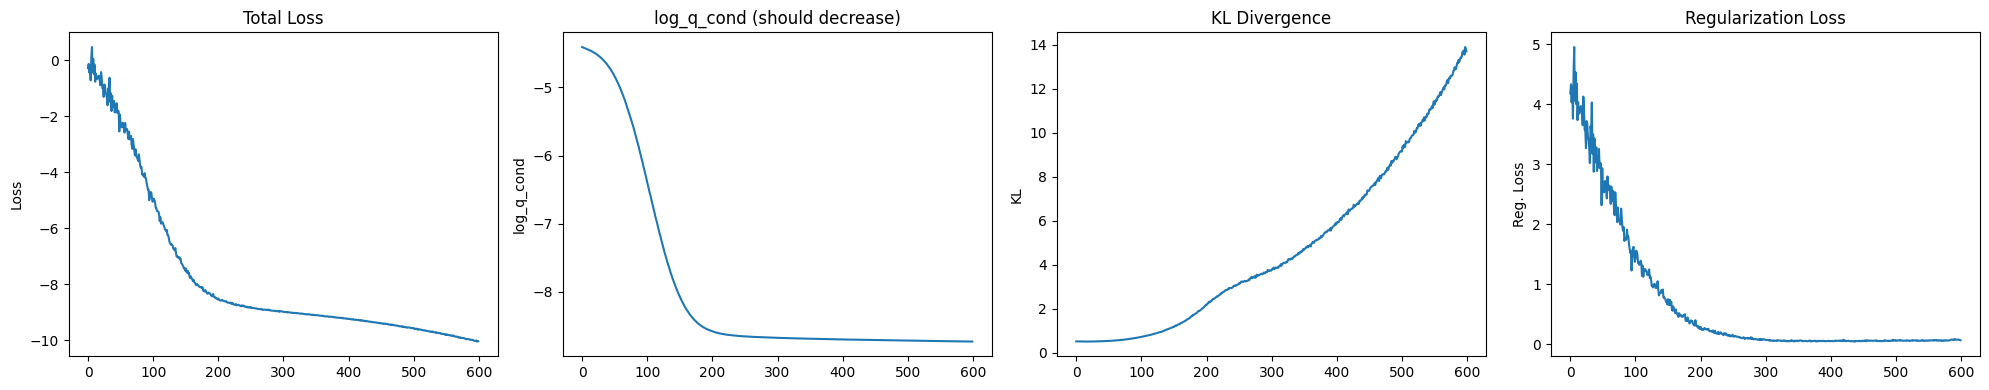

Training new model iteration 92...
Epoch 1: Loss=-0.7111, log_q=-4.7602,, reg. loss=4.1011, beta * KL=0.0520
Epoch 10: Loss=-8.3260, log_q=-8.5225,, reg. loss=0.3496, beta * KL=0.1532
Epoch 20: Loss=-9.2247, log_q=-8.7033,, reg. loss=0.0375, beta * KL=0.5590
Epoch 30: Loss=-10.0531, log_q=-8.7388,, reg. loss=0.0587, beta * KL=1.3730


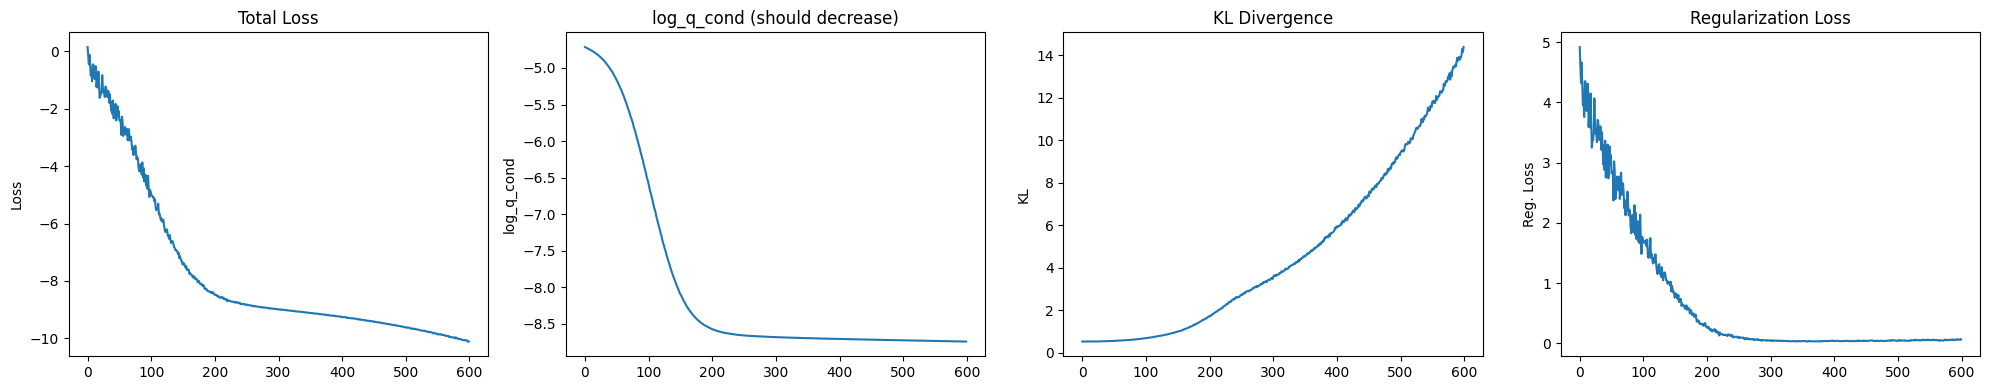

Training new model iteration 93...
Epoch 1: Loss=-1.8204, log_q=-4.7045,, reg. loss=2.9407, beta * KL=0.0566
Epoch 10: Loss=-8.5194, log_q=-8.5962,, reg. loss=0.4571, beta * KL=0.3802
Epoch 20: Loss=-9.2501, log_q=-8.6952,, reg. loss=0.0728, beta * KL=0.6277
Epoch 30: Loss=-10.1474, log_q=-8.7239,, reg. loss=0.0837, beta * KL=1.5072


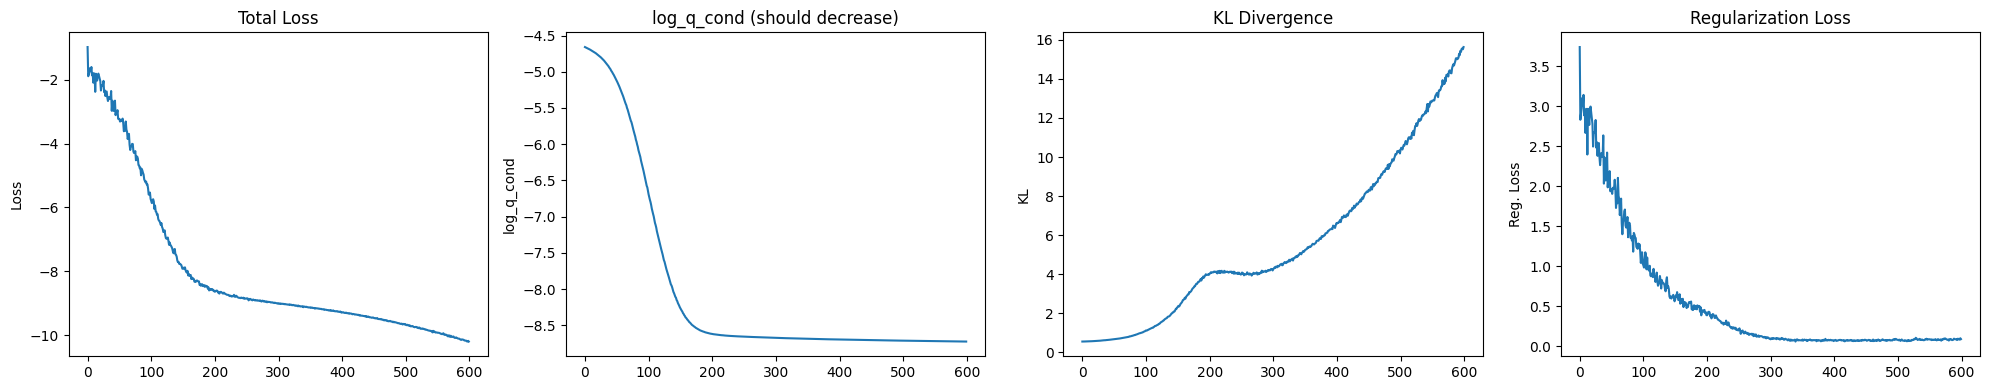

Training new model iteration 94...
Epoch 1: Loss=-1.1331, log_q=-4.7829,, reg. loss=3.7010, beta * KL=0.0512
Epoch 10: Loss=-8.3629, log_q=-8.5443,, reg. loss=0.3619, beta * KL=0.1806
Epoch 20: Loss=-9.1820, log_q=-8.7007,, reg. loss=0.0515, beta * KL=0.5329
Epoch 30: Loss=-9.9102, log_q=-8.7371,, reg. loss=0.0911, beta * KL=1.2642


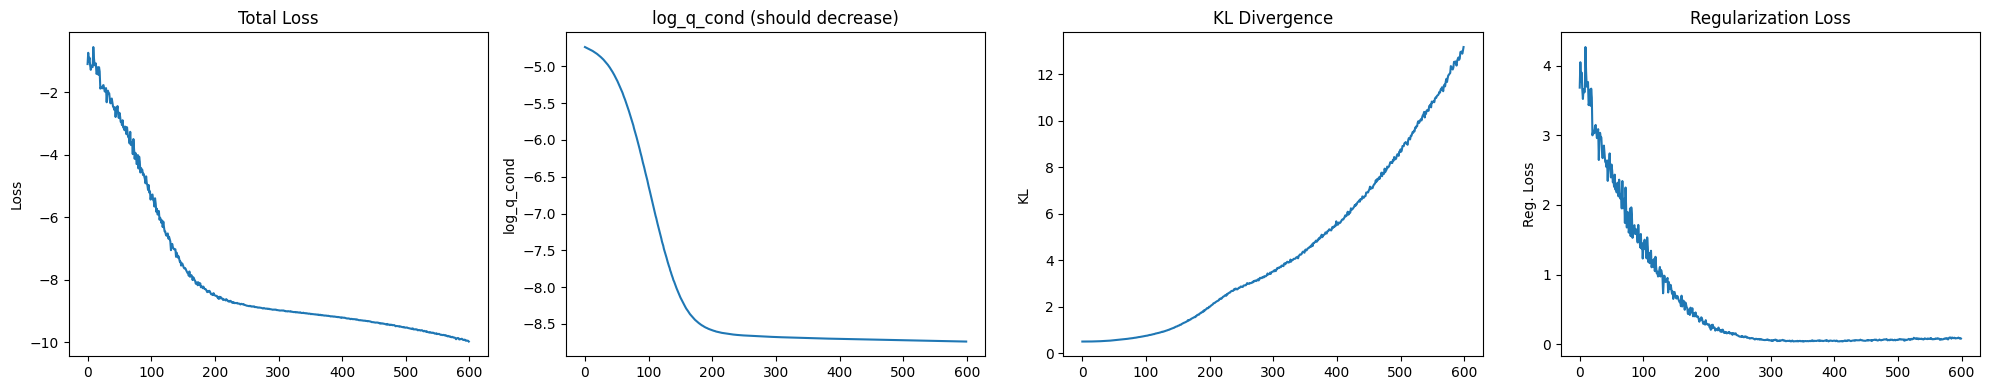

Training new model iteration 95...
Epoch 1: Loss=-1.1262, log_q=-4.6961,, reg. loss=3.6216, beta * KL=0.0517
Epoch 10: Loss=-8.1927, log_q=-8.4833,, reg. loss=0.4186, beta * KL=0.1280
Epoch 20: Loss=-9.1564, log_q=-8.7032,, reg. loss=0.0236, beta * KL=0.4769
Epoch 30: Loss=-9.8710, log_q=-8.7410,, reg. loss=0.0400, beta * KL=1.1701


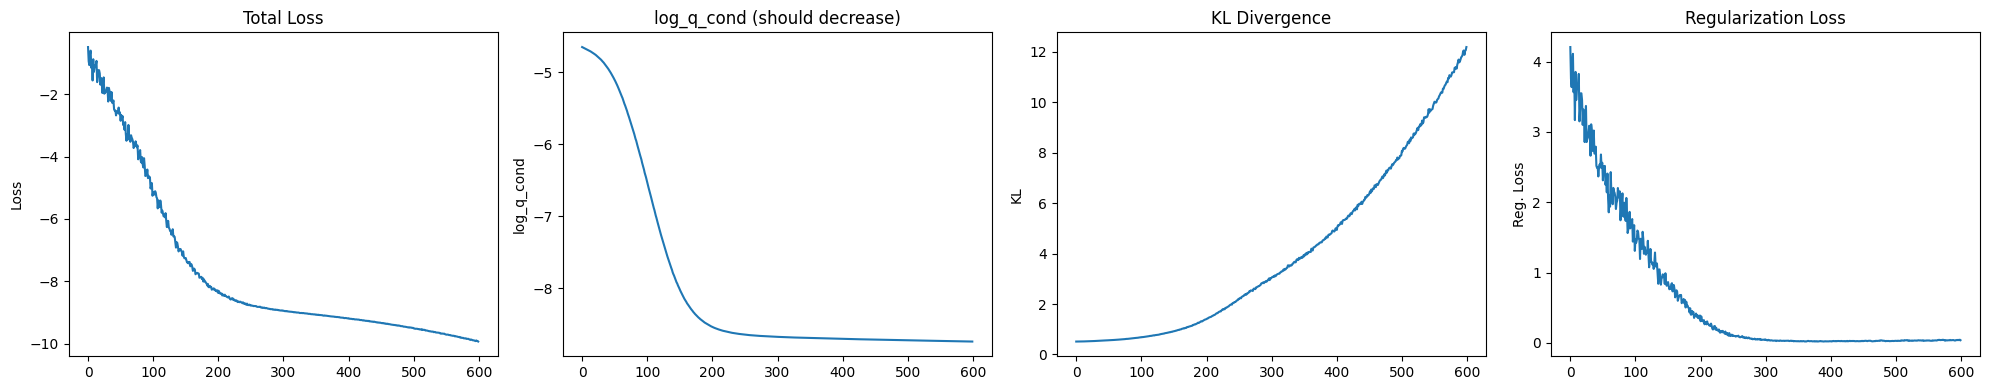

Training new model iteration 96...
Epoch 1: Loss=-1.4382, log_q=-4.7389,, reg. loss=3.3522, beta * KL=0.0516
Epoch 10: Loss=-8.1639, log_q=-8.4848,, reg. loss=0.4505, beta * KL=0.1296
Epoch 20: Loss=-9.1110, log_q=-8.6999,, reg. loss=0.0444, beta * KL=0.4555
Epoch 30: Loss=-9.7691, log_q=-8.7360,, reg. loss=0.0831, beta * KL=1.1162


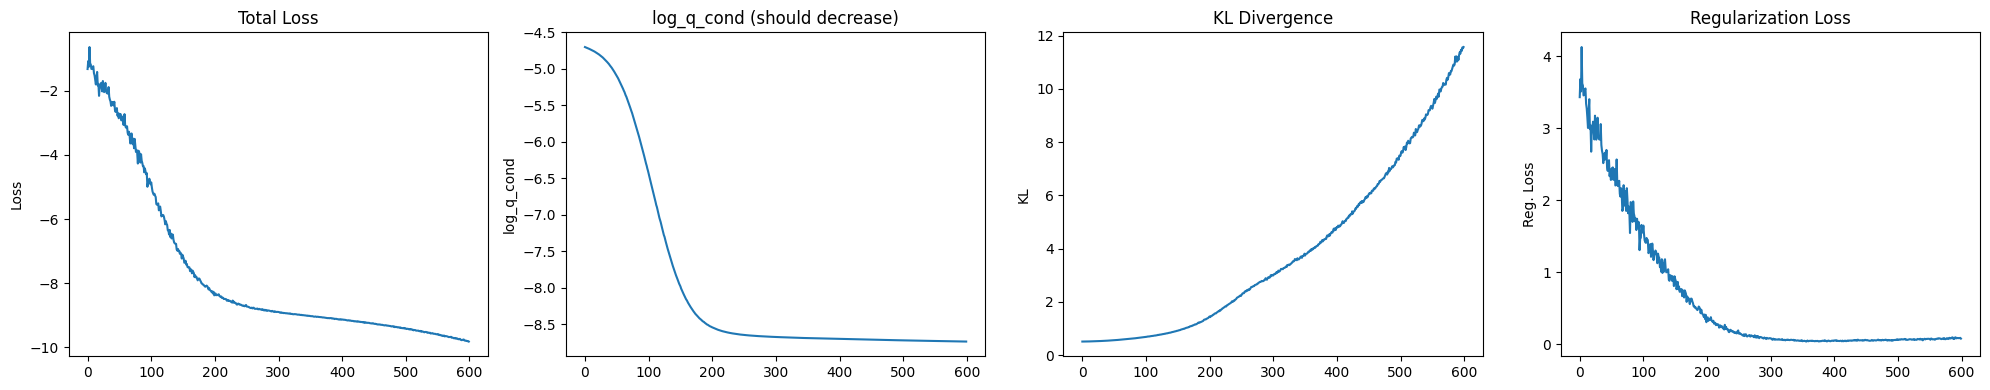

Training new model iteration 97...
Epoch 1: Loss=-1.9552, log_q=-4.8131,, reg. loss=2.9114, beta * KL=0.0535
Epoch 10: Loss=-8.0481, log_q=-8.4532,, reg. loss=0.5277, beta * KL=0.1226
Epoch 20: Loss=-9.1150, log_q=-8.6943,, reg. loss=0.0155, beta * KL=0.4362
Epoch 30: Loss=-9.7651, log_q=-8.7273,, reg. loss=0.0205, beta * KL=1.0583


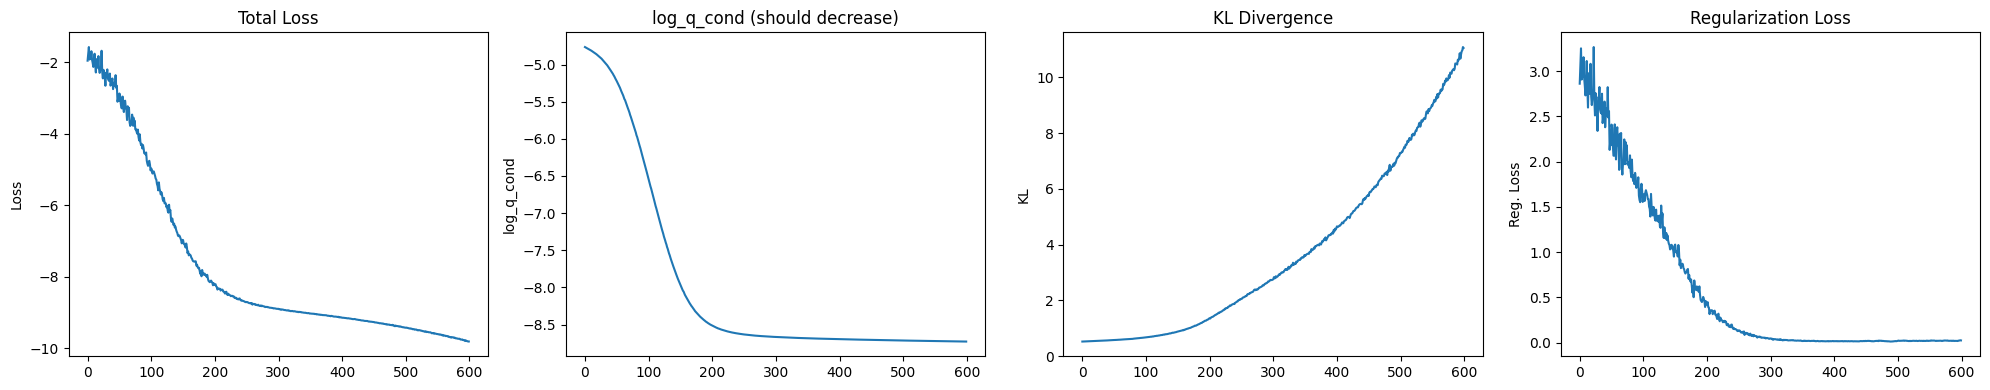

Training new model iteration 98...
Epoch 1: Loss=-1.2309, log_q=-4.3749,, reg. loss=3.1977, beta * KL=0.0537
Epoch 10: Loss=-8.5577, log_q=-8.6005,, reg. loss=0.3900, beta * KL=0.3473
Epoch 20: Loss=-9.2597, log_q=-8.6986,, reg. loss=0.0753, beta * KL=0.6364
Epoch 30: Loss=-10.1431, log_q=-8.7298,, reg. loss=0.0816, beta * KL=1.4950


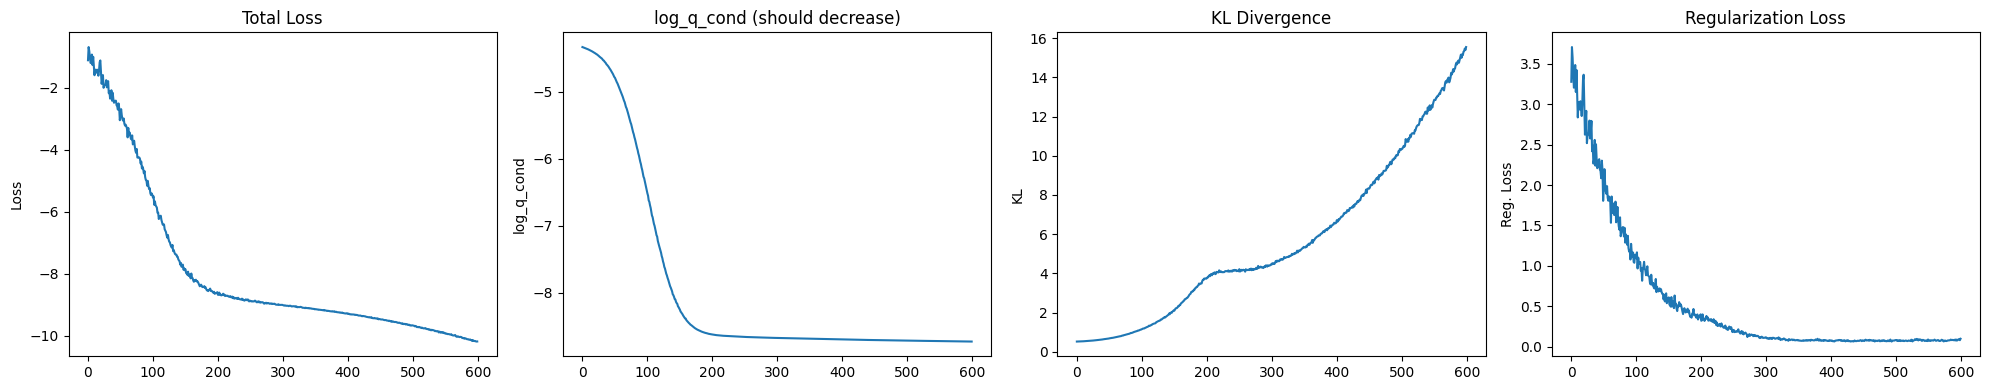

Training new model iteration 99...
Epoch 1: Loss=-1.1736, log_q=-4.5703,, reg. loss=3.4513, beta * KL=0.0546
Epoch 10: Loss=-8.3525, log_q=-8.5545,, reg. loss=0.4457, beta * KL=0.2436
Epoch 20: Loss=-9.1685, log_q=-8.7020,, reg. loss=0.0635, beta * KL=0.5300
Epoch 30: Loss=-9.8794, log_q=-8.7380,, reg. loss=0.0696, beta * KL=1.2110


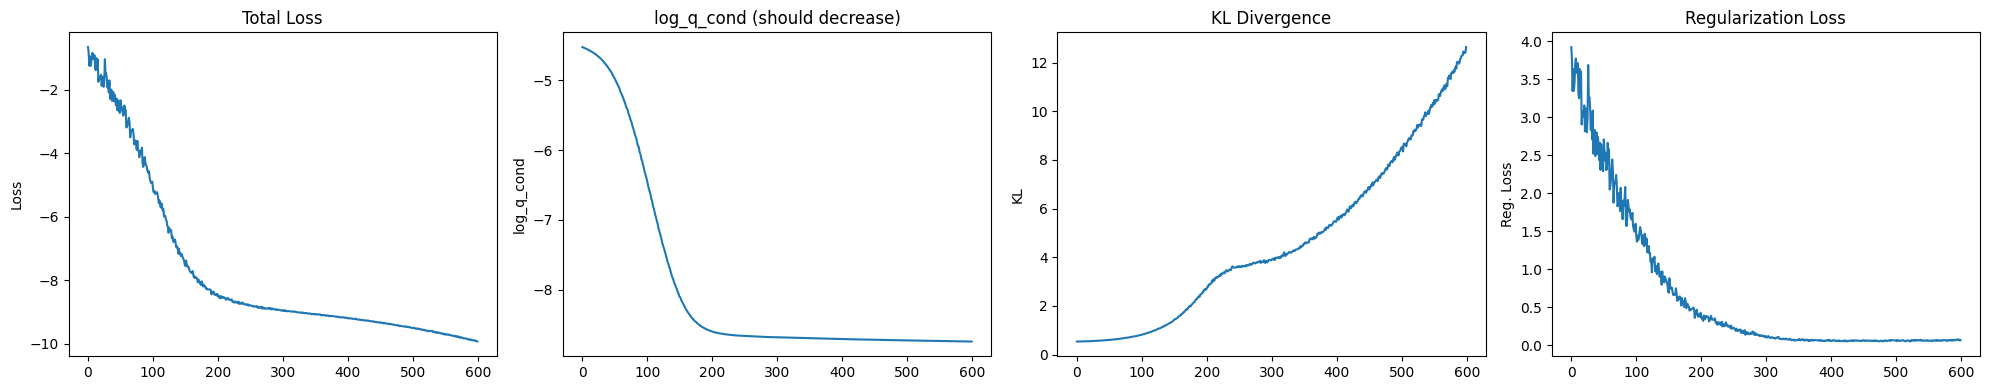

Training new model iteration 100...
Epoch 1: Loss=0.0460, log_q=-4.7200,, reg. loss=4.8179, beta * KL=0.0518
Epoch 10: Loss=-8.3188, log_q=-8.5506,, reg. loss=0.3845, beta * KL=0.1527
Epoch 20: Loss=-9.1844, log_q=-8.7049,, reg. loss=0.0315, beta * KL=0.5110
Epoch 30: Loss=-9.9255, log_q=-8.7394,, reg. loss=0.0462, beta * KL=1.2323


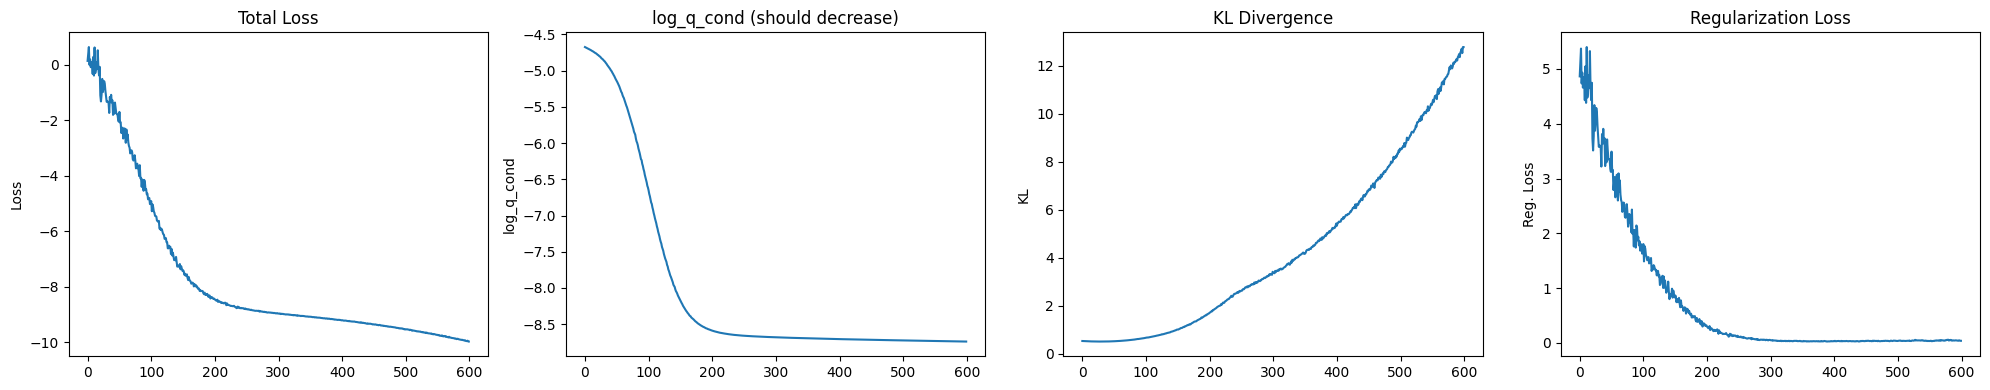

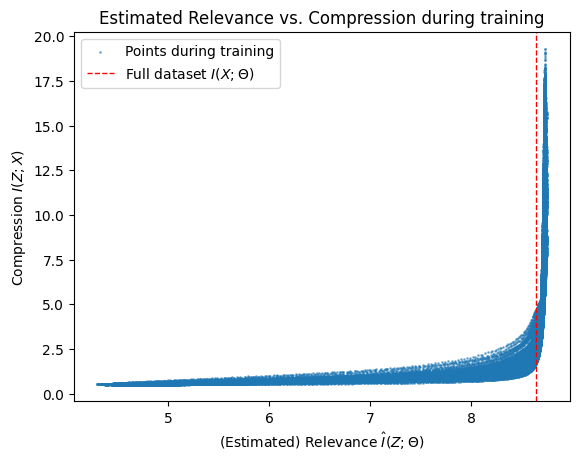

In [155]:
ba_bounds = []
i_z_x = []
for i in range(100):
    print(f"Training new model iteration {i+1}...")
    model_encoder=Compressor()
    model = IB(
        encoder=IBCompressor(encoder=model_encoder, x_dim=DATAPOINT_SIZE, z_dim=LATENT_SIZE),
        # cond_prob_model=ConditionalKDE(1, 10),
        cond_prob_model=ConditionalNormalizingFlow(),
        beta = 1e-1,
        reg_weight=4e0,
        reg_type=0,
        optim_func=torch.optim.Adam,
        lr=1e-4
    ).to(device)

    model.train(
        x_train=train_sims_data[:, :DATAPOINT_SIZE],
        y_train=train_sims_data[:, -1],
        nepochs=30,
        batch_size=512,
        print_losses=True
        )
    assert not np.isnan(model.full_losses[-1]), "Total loss is NaN. Check the model and training process."

    ba_bounds = ba_bounds + model.log_prob_losses
    i_z_x = i_z_x + model.kl_losses

plt.scatter(-1*np.array(ba_bounds), i_z_x, alpha=0.5, s=1e0,
            label='Points during training')
plt.axvline(
    x = 8.64,
    color='red',
    linestyle='--',
    linewidth=1,
    label=r'Full dataset $I(X; \Theta)$'
)
plt.xlabel(r"(Estimated) Relevance $\hat{I}(Z;\Theta)$")
plt.ylabel(r"Compression $I(Z;X)$")
plt.legend()
plt.title('Estimated Relevance vs. Compression during training')
plt.show()

In [156]:
# plt.scatter(-1*np.array(ba_bounds), i_z_x, alpha=0.1, s=1e-2,
#             label='Points during training')
# plt.axvline(
#     x = 8.64,
#     color='red',
#     linestyle='--',
#     linewidth=1,
#     label=r'Full dataset $I(X; \Theta)$'
# )
# plt.xlabel(r"(Estimated) Relevance $\hat{I}(Z;\Theta)$")
# plt.ylabel(r"Compression $I(Z;X)$")
# plt.legend()
# plt.title('Estimated Relevance vs. Compression during training')
# plt.show()

In [159]:
# np.save("ba_bounds.npy", -1*np.array(ba_bounds), allow_pickle=True)
# np.save("i_z_x.npy", i_z_x, allow_pickle=True)

## Plotting the results to compare estimator std dev

-0.76960397 -1.5492964


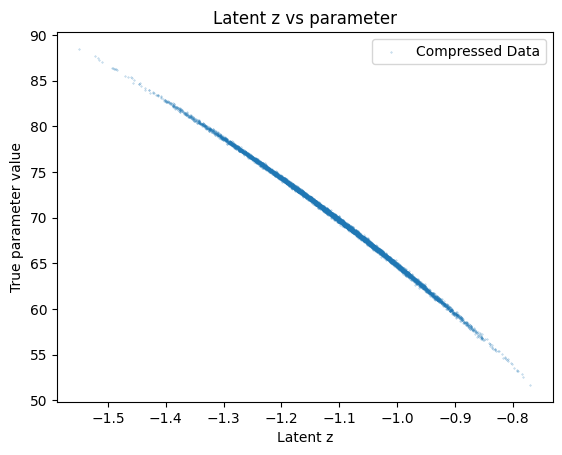

In [158]:
m, l, z = model.encoder(train_sims_data[:, :DATAPOINT_SIZE])
z = z.detach().cpu().numpy()

print(z.max(), z.min())

plt.scatter(z, train_sims_data[:, -1].cpu().numpy(), alpha=0.5, s=1e-1, label='Compressed Data')
plt.xlabel('Latent z')
plt.ylabel('True parameter value')
plt.legend()
# plt.xlim([110, 120])
plt.title('Latent z vs parameter')
plt.show()

In [160]:
# To check if the model collapsed: the standard deviations in m must match the priors
m.std(), l.std()

(tensor(0.1053, device='cuda:0', grad_fn=<StdBackward0>),
 tensor(3.3899, device='cuda:0', grad_fn=<StdBackward0>))

Dataset size: 10000, Number of bins: 11, Bin width: 0.01
Bin centers: [-1.5288454  -1.4576     -1.3863546  -1.3151091  -1.2438637  -1.1726183
 -1.1013728  -1.0301274  -0.958882   -0.88763654 -0.8163911 ]
Bin means: [87.5783462524414, 84.97489929199219, 82.23078155517578, 79.27565002441406, 76.2614517211914, 73.09493255615234, 69.80718994140625, 66.31219482421875, 62.64923858642578, 58.831974029541016, 54.70712661743164]
Bin stds: [0.0, 0.025592803955078125, 0.13361772894859314, 0.14764317870140076, 0.1438499093055725, 0.1526455581188202, 0.15797024965286255, 0.17826604843139648, 0.1588730812072754, 0.17934170365333557, 0.21512442827224731]
Bin stds errors: [nan, np.float64(0.018096845226213635), np.float64(0.028487395529649844), np.float64(0.016304461538536964), np.float64(0.009247022394821834), np.float64(0.007195780617588201), np.float64(0.006344237895636623), np.float64(0.007956403122272875), np.float64(0.010129377691037946), np.float64(0.022776419140404146), np.float64(0.0878241800

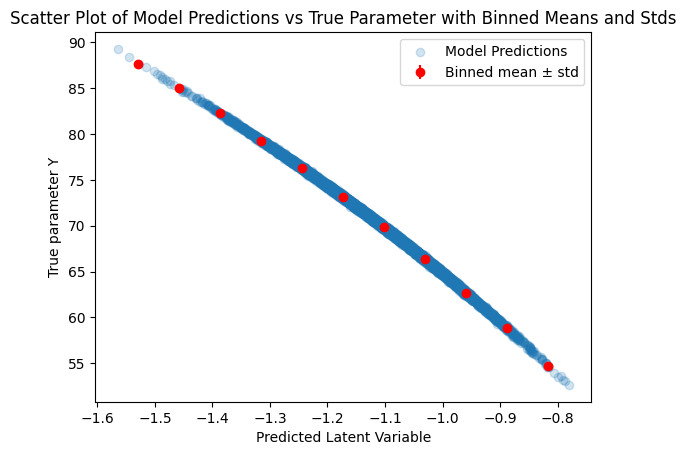

(np.float64(0.15400278608765572),
 array([0.0255928 , 0.13361773, 0.14764318, 0.14384991, 0.15264556,
        0.15797025, 0.17826605, 0.15887308, 0.1793417 , 0.21512443]),
 array([0.01809685, 0.0284874 , 0.01630446, 0.00924702, 0.00719578,
        0.00634424, 0.0079564 , 0.01012938, 0.02277642, 0.08782418]))

In [161]:
sigma_beta, _, std, std_err = evaluate_posterior_covariance(model, test_sims_data[:, :DATAPOINT_SIZE], test_sims_data[:, -1:])
sigma_beta, std, std_err

## Posterior comparison

In [162]:
SELECT_PERCENT = 5e-3

Creating sample: 1 of 1
Compressed obs: -1.1071115732192993
Selected 433 samples from test set with compressed value close to observed compressed value.


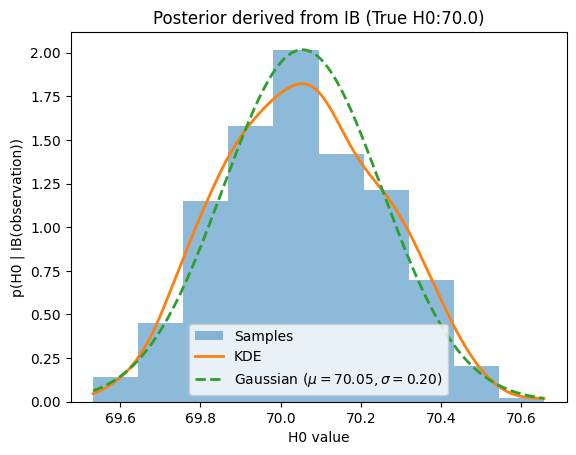

In [163]:
true_h0 = 70.0
# true_h0 = test_sims_data[0, -1].item()
_, data_obs, _, _ = create_synthetic_supernovae_dataset(n_samples=1, h0s=[true_h0])
data_obs = torch.tensor(data_obs, dtype=torch.float32).to(device)

# data_obs = test_sims_data[0:1, :DATAPOINT_SIZE]
compressed_test = model(test_sims_data[:, :DATAPOINT_SIZE]).detach().cpu().numpy()

compressed_obs = model(data_obs).detach().cpu().numpy()

print("Compressed obs:", compressed_obs.item())

mask = abs(compressed_test[:, 0] - compressed_obs.item())/(abs(compressed_obs.item()) + 1e-8) < SELECT_PERCENT
selected_h0 = test_sims_data[mask, -1].cpu().numpy()
print(f"Selected {len(selected_h0)} samples from test set with compressed value close to observed compressed value.")

mu, sigma = norm.fit(selected_h0)

x = np.linspace(selected_h0.min(), selected_h0.max(), 1000)

kde = gaussian_kde(selected_h0)

plt.hist(selected_h0, density=True, alpha=0.5, label='Samples')
plt.plot(x, kde(x), lw=2, label='KDE')
plt.plot(x, norm.pdf(x, mu, sigma), '--', lw=2,
         label=fr'Gaussian ($\mu={mu:.2f}, \sigma={sigma:.2f}$)')
plt.xlabel('H0 value')
plt.ylabel('p(H0 | IB(observation))')
plt.title(f'Posterior derived from IB (True H0:{true_h0})')
plt.legend()
plt.show()

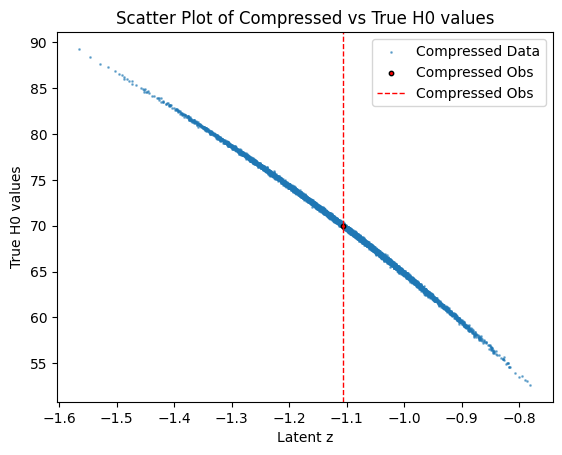

In [164]:
plt.scatter(compressed_test[:, 0], test_sims_data[:, -1].cpu().numpy(), alpha=0.5, s=1, label='Compressed Data')
plt.scatter(compressed_obs[0, 0], true_h0, color='red', label='Compressed Obs', s=10, edgecolor='black')
plt.axvline(compressed_obs[0, 0], color='red', linestyle='dashed', linewidth=1, label='Compressed Obs')
plt.xlabel('Latent z')
plt.ylabel('True H0 values')
plt.title('Scatter Plot of Compressed vs True H0 values')
plt.legend()
plt.show()

### MOPED Compression

In [165]:
cov = np.eye(DATAPOINT_SIZE) * DATA_VARIANCE_SCALE**2

def estimator_given_theta(theta):
    _, data, _, _ = create_synthetic_supernovae_dataset(1, theta, data_var=0.)
    # print(data.shape)
    # return 10**(-0.4*data[0, :])
    return data[0, :]

fid_vals = np.array([75.0])

Creating sample: 1 of 1
Creating sample: 1 of 1
Creating sample: 1 of 1
(1, 100)
MOPED Fisher information: [[1.6e-07]]


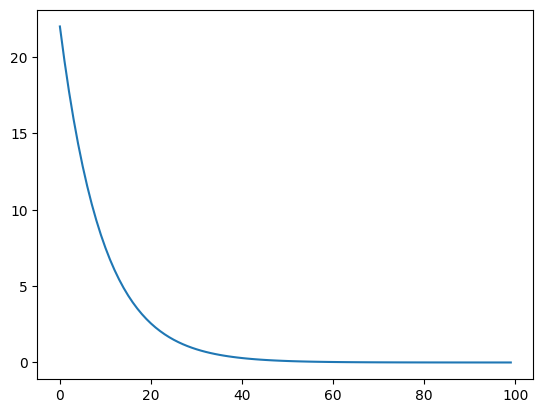

In [166]:
b, F, d = moped(fid_vals, cov, estimator_given_theta)
# print("MOPED compressed value:", b)
print("MOPED Fisher information:", 1/F)
plt.plot(b.T)
plt.show()

In [167]:
moped_d_obs = data_obs.detach().cpu().numpy()[0, :DATAPOINT_SIZE]
# moped_d_obs = 10**(-0.4*moped_d_obs)
moped_compressed = moped_d_obs @ b.T
moped_compressed

array([615.90322537])

In [168]:
# moped_test = 10**(-0.4*test_sims_data[:, :DATAPOINT_SIZE].detach().cpu().numpy()) @ b.T
moped_test = test_sims_data[:, :DATAPOINT_SIZE].detach().cpu().numpy() @ b.T
mask_moped = abs(moped_test[:, 0] - moped_compressed[0])/(abs(moped_compressed[0]) + 1e-8) < SELECT_PERCENT

selected_h0_moped = test_sims_data[mask_moped, -1].cpu().numpy()
print(f"Selected {len(selected_h0_moped)} samples from test set with MOPED compressed value close to observed MOPED compressed value.")

Selected 269 samples from test set with MOPED compressed value close to observed MOPED compressed value.


In [169]:
mask_moped

array([False, False, False, ..., False, False, False], shape=(10000,))

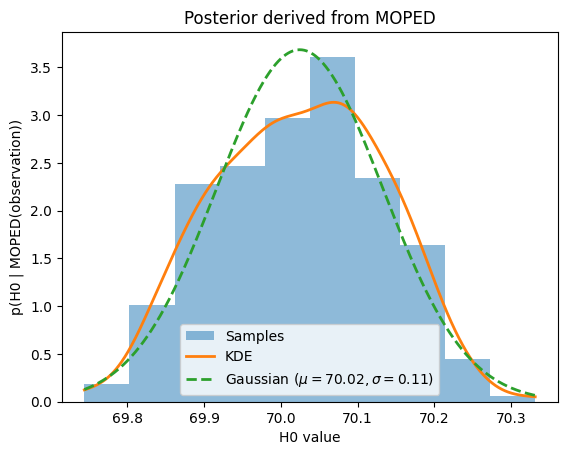

In [170]:
mu, sigma = norm.fit(selected_h0_moped)

x = np.linspace(selected_h0_moped.min(), selected_h0_moped.max(), 1000)

kde = gaussian_kde(selected_h0_moped)

plt.hist(selected_h0_moped, density=True, alpha=0.5, label='Samples')
plt.plot(x, kde(x), lw=2, label='KDE')
plt.plot(x, norm.pdf(x, mu, sigma), '--', lw=2,
         label=fr'Gaussian ($\mu={mu:.2f}, \sigma={sigma:.2f}$)')
plt.xlabel('H0 value')
plt.ylabel('p(H0 | MOPED(observation))')
plt.title('Posterior derived from MOPED')
plt.legend()
plt.show()

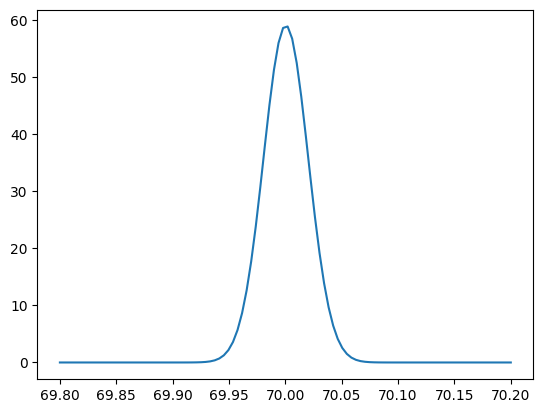

In [171]:
h0s = np.linspace(69.8, 70.2, 100)
p_theta = norm.pdf(h0s, loc=70, scale=DATA_VARIANCE_SCALE)
likelihood = kde(h0s) * p_theta

plt.plot(h0s, likelihood, label='Posterior from IB')

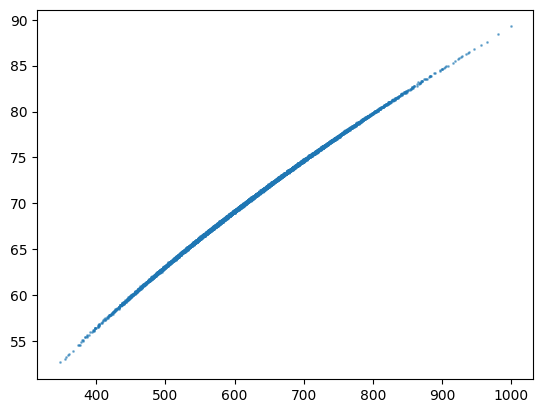

In [172]:
plt.scatter(moped_test[:, 0], test_sims_data[:, -1].cpu().numpy(), alpha=0.5, s=1, label='MOPED Compressed Data')
plt.show()